![NY Taxi](https://w0.peakpx.com/wallpaper/653/798/HD-wallpaper-cabs-new-york-traffic-transport-yellow-abstract-graphy-bw-taxi-road-street.jpg)

# BUS2003 A3 — NYC Mobility Pipeline and Insights

**Student Name**: Thuy Linh Dang (21878037)

**Main decision question**

Which NYC taxi zones should be prioritised for targeted mobility interventions, based on taxi demand volume, time-of-day reliance, trip distance patterns, and comparison with subway, bus, and Citi Bike activity in April 2026?

**Audience:** NYC city authority   
**Decision supported:** shortlist zones for further service-planning review, not final infrastructure decisions  
**Geographic scope:** NYC taxi zones and boroughs  
**Time scope:** April 2026  
**Anchor dataset:** NYC TLC Yellow + Green taxi trip records  
**Supporting datasets:** taxi zone lookup, MTA subway hourly ridership, MTA bus hourly ridership, Citi Bike trip data  


# 0. Notebook Setup
The original datasets are sourced from official public transport data providers, including NYC TLC, MTA, and Citi Bike. The official source URLs and API view IDs are documented below.

Because several raw datasets are large, this notebook uses a **download-if-missing** approach. If a raw file is not already stored in the project Google Drive folder, the notebook downloads it from the official online source. If the file already exists, the notebook reuses the stored copy to avoid repeated large downloads after restarting the Colab runtime.

This approach keeps the pipeline reproducible while also making it efficient to rerun in Google Colab.

In [1]:
!pip -q install duckdb pyarrow pandas matplotlib plotly geopandas requests

In [2]:
# ============================================================
# 0.1 IMPORT REQUIRED LIBRARIES
# ============================================================

from pathlib import Path
import os
import time
import zipfile
import requests
import pandas as pd
import duckdb
import textwrap
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 80)


print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# 0.2 MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ============================================================
# 0.3 PROJECT CONFIGURATION
# ============================================================

DATA_MONTH = "2026-04"

PROJECT_DIR = Path("/content/drive/MyDrive/nyc_mobility_pipeline")

RAW_DIR = PROJECT_DIR / "raw_data"
TAXI_DIR = RAW_DIR / "taxi"
LOOKUP_DIR = RAW_DIR / "lookup"
SUBWAY_DIR = RAW_DIR / "subway"
BUS_DIR = RAW_DIR / "bus"
BIKE_DIR = RAW_DIR / "bike"

OUTPUT_DIR = PROJECT_DIR / "outputs"

for folder in [RAW_DIR, TAXI_DIR, LOOKUP_DIR, SUBWAY_DIR, BUS_DIR, BIKE_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: /content/drive/MyDrive/nyc_mobility_pipeline
Raw data directory: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data
Output directory: /content/drive/MyDrive/nyc_mobility_pipeline/outputs


In [7]:
# ============================================================
# 0.4 DATASET URLS, API VIEW IDS, AND FILE PATHS
# ============================================================

# ------------------------------------------------------------
# Direct file download datasets
# ------------------------------------------------------------

YELLOW_TAXI_URL = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{DATA_MONTH}.parquet"
GREEN_TAXI_URL = f"https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_{DATA_MONTH}.parquet"
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

# Citi Bike direct file link for April 2026.
# This dataset is used as supporting context for bike-share activity.
BIKE_URL = "https://s3.amazonaws.com/tripdata/202604-citibike-tripdata.zip"

# ------------------------------------------------------------
# Socrata / Data.NY.GOV API datasets
# ------------------------------------------------------------

SUBWAY_VIEW_ID = "5wq4-mkjj"
BUS_VIEW_ID = "gxb3-akrn"

# ------------------------------------------------------------
# Local file paths
# ------------------------------------------------------------

YELLOW_TAXI_PATH = TAXI_DIR / f"yellow_tripdata_{DATA_MONTH}.parquet"
GREEN_TAXI_PATH = TAXI_DIR / f"green_tripdata_{DATA_MONTH}.parquet"
ZONE_PATH = LOOKUP_DIR / "taxi_zone_lookup.csv"

BIKE_ZIP_PATH = BIKE_DIR / f"{DATA_MONTH}-citibike-tripdata.zip"
BIKE_EXTRACTED_CSV_PATH = BIKE_DIR / f"citibike_tripdata_{DATA_MONTH}.csv"

SUBWAY_OUTPUT_PATH = SUBWAY_DIR / f"subway_hourly_ridership_{DATA_MONTH}_full.csv"
BUS_OUTPUT_PATH = BUS_DIR / f"bus_hourly_ridership_{DATA_MONTH}_full.csv"

# SQL-readable taxi paths for DuckDB
YELLOW_TRIPS_SQL = f"read_parquet('{YELLOW_TAXI_PATH.as_posix()}')"
GREEN_TRIPS_SQL = f"read_parquet('{GREEN_TAXI_PATH.as_posix()}')"

print("Yellow taxi path:", YELLOW_TAXI_PATH)
print("Green taxi path:", GREEN_TAXI_PATH)
print("Zone lookup path:", ZONE_PATH)
print("Subway output path:", SUBWAY_OUTPUT_PATH)
print("Bus output path:", BUS_OUTPUT_PATH)
print("Bike path:", BIKE_ZIP_PATH)

Yellow taxi path: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/taxi/yellow_tripdata_2026-04.parquet
Green taxi path: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/taxi/green_tripdata_2026-04.parquet
Zone lookup path: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/lookup/taxi_zone_lookup.csv
Subway output path: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/subway/subway_hourly_ridership_2026-04_full.csv
Bus output path: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/bus/bus_hourly_ridership_2026-04_full.csv
Bike path: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/bike/2026-04-citibike-tripdata.zip


In [14]:
# ============================================================
# 0.5 DATA SOURCE DOCUMENTATION
# ============================================================

dataset_sources = pd.DataFrame({
    "Dataset": [
        "NYC TLC Yellow Taxi Trip Records",
        "NYC TLC Green Taxi Trip Records",
        "NYC Taxi Zone Lookup Table",
        "MTA Subway Hourly Ridership",
        "MTA Bus Hourly Ridership",
        "Citi Bike Trip Data"
    ],
    "Source type": [
        "Direct file download",
        "Direct file download",
        "Direct file download",
        "Socrata API",
        "Socrata API",
        "Direct file download"
    ],
    "Official URL or view ID": [
        YELLOW_TAXI_URL,
        GREEN_TAXI_URL,
        ZONE_URL,
        f"https://data.ny.gov/api/views/{SUBWAY_VIEW_ID}",
        f"https://data.ny.gov/api/views/{BUS_VIEW_ID}",
        BIKE_URL
    ],
    "Local file path": [
        str(YELLOW_TAXI_PATH),
        str(GREEN_TAXI_PATH),
        str(ZONE_PATH),
        str(SUBWAY_OUTPUT_PATH),
        str(BUS_OUTPUT_PATH),
        str(BIKE_ZIP_PATH)
    ],
    "Purpose in project": [
        "Anchor dataset for taxi demand analysis",
        "Additional taxi dataset, especially for borough taxi patterns",
        "Maps taxi location IDs to borough and zone names",
        "Supports comparison between taxi demand and subway activity",
        "Supports comparison between taxi demand and bus activity",
        "Provides supporting context for bike-share and short-trip alternatives"
    ]
})

dataset_sources

,Dataset,Source type,Official URL or view ID,Local file path,Purpose in project
0,NYC TLC Yellow Taxi Trip Records,Direct file download,https://d37ci6vzurychx.cloudfront.net/trip-dat...,/content/drive/MyDrive/nyc_mobility_pipeline/r...,Anchor dataset for taxi demand analysis
1,NYC TLC Green Taxi Trip Records,Direct file download,https://d37ci6vzurychx.cloudfront.net/trip-dat...,/content/drive/MyDrive/nyc_mobility_pipeline/r...,"Additional taxi dataset, especially for boroug..."
2,NYC Taxi Zone Lookup Table,Direct file download,https://d37ci6vzurychx.cloudfront.net/misc/tax...,/content/drive/MyDrive/nyc_mobility_pipeline/r...,Maps taxi location IDs to borough and zone names
3,MTA Subway Hourly Ridership,Socrata API,https://data.ny.gov/api/views/5wq4-mkjj,/content/drive/MyDrive/nyc_mobility_pipeline/r...,Supports comparison between taxi demand and su...
4,MTA Bus Hourly Ridership,Socrata API,https://data.ny.gov/api/views/gxb3-akrn,/content/drive/MyDrive/nyc_mobility_pipeline/r...,Supports comparison between taxi demand and bu...
5,Citi Bike Trip Data,Direct file download,https://s3.amazonaws.com/tripdata/202604-citib...,/content/drive/MyDrive/nyc_mobility_pipeline/r...,Provides supporting context for bike-share and...


In [15]:
# ============================================================
# 0.6 FUNCTION: DIRECT FILE DOWNLOAD
# ============================================================

def download_file_if_missing(url, destination_path):
    """
    Download a direct file link only if it does not already exist.
    This is used for taxi parquet files, taxi zone lookup, and direct bike files.
    """
    destination_path = Path(destination_path)
    destination_path.parent.mkdir(parents=True, exist_ok=True)

    if url is None or "PASTE_" in str(url):
        print(f"Skipped placeholder URL for: {destination_path.name}")
        return None

    if destination_path.exists():
        print(f"Already exists, skipping download: {destination_path.name}")
        return destination_path

    print(f"Downloading: {destination_path.name}")
    print(f"Source: {url}")

    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    with open(destination_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)

    print(f"Saved to: {destination_path}")
    return destination_path

In [16]:
# ============================================================
# 0.7 FUNCTION: SOCRATA API PAGINATED DOWNLOAD
# ============================================================

def download_socrata_query_to_csv(
    view_id,
    select_columns,
    where_clause,
    output_path,
    order_by=None,
    page_size=50000,
    sleep_seconds=0.2,
    overwrite=False
):
    """
    Download a full Socrata API dataset using LIMIT + OFFSET pagination.
    The file is first saved to a temporary file to avoid overwriting a complete
    existing file if the download is interrupted.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    temp_path = output_path.with_suffix(output_path.suffix + ".tmp")

    if output_path.exists() and not overwrite:
        print(f"Already exists, skipping API download: {output_path.name}")
        return output_path

    if temp_path.exists():
        temp_path.unlink()
        print("Deleted old temporary file.")

    base_url = f"https://data.ny.gov/resource/{view_id}.json"

    offset = 0
    total_rows = 0
    first_chunk = True

    columns_sql = ", ".join([f"`{col}`" for col in select_columns])

    if order_by is None:
        order_by = f"`{select_columns[0]}`"

    print(f"Downloading full API dataset: {view_id}")
    print(f"Saving temporary file to: {temp_path}")

    while True:
        query = f"""
        SELECT {columns_sql}
        WHERE {where_clause}
        ORDER BY {order_by}
        LIMIT {page_size}
        OFFSET {offset}
        """

        response = requests.get(base_url, params={"$query": query}, timeout=120)
        response.raise_for_status()

        data = response.json()

        if len(data) == 0:
            print("No more rows to download.")
            break

        chunk = pd.DataFrame(data)

        # Make sure column names are correct
        if len(chunk.columns) == len(select_columns):
            chunk.columns = select_columns

        chunk.to_csv(
            temp_path,
            mode="w" if first_chunk else "a",
            index=False,
            header=False
        )

        rows_downloaded = len(chunk)
        total_rows += rows_downloaded

        print(f"Downloaded {rows_downloaded:,} rows | Total: {total_rows:,}")

        if rows_downloaded < page_size:
            print("Final chunk downloaded.")
            break

        offset += page_size
        first_chunk = False
        time.sleep(sleep_seconds)

    # Replace old output only after full download is complete
    temp_path.replace(output_path)

    print(f"Completed. Total rows saved: {total_rows:,}")
    print(f"Final file saved to: {output_path}")

    return output_path

In [18]:
# ============================================================
# 0.8 DOWNLOAD DIRECT FILE DATASETS IF MISSING
# ============================================================

download_file_if_missing(YELLOW_TAXI_URL, YELLOW_TAXI_PATH)
download_file_if_missing(GREEN_TAXI_URL, GREEN_TAXI_PATH)
download_file_if_missing(ZONE_URL, ZONE_PATH)
download_file_if_missing(BIKE_URL, BIKE_ZIP_PATH)

print("\nDirect file downloads checked.")

Already exists, skipping download: yellow_tripdata_2026-04.parquet
Already exists, skipping download: green_tripdata_2026-04.parquet
Already exists, skipping download: taxi_zone_lookup.csv
Downloading: 2026-04-citibike-tripdata.zip
Source: https://s3.amazonaws.com/tripdata/202604-citibike-tripdata.zip
Saved to: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/bike/2026-04-citibike-tripdata.zip

Direct file downloads checked.


In [20]:
# ============================================================
# 0.9 DOWNLOAD FULL SUBWAY HOURLY RIDERSHIP DATA IF MISSING
# ============================================================

SUBWAY_COLUMNS = [
    "transit_timestamp",
    "transit_mode",
    "station_complex_id",
    "station_complex",
    "borough",
    "payment_method",
    "fare_class_category",
    "ridership",
    "transfers",
    "latitude",
    "longitude",
    "georeference"
]

SUBWAY_WHERE = f"""
`transit_timestamp`
BETWEEN "{DATA_MONTH}-01T00:00:00" :: floating_timestamp
AND "{DATA_MONTH}-30T23:59:59" :: floating_timestamp
"""

download_socrata_query_to_csv(
    view_id=SUBWAY_VIEW_ID,
    select_columns=SUBWAY_COLUMNS,
    where_clause=SUBWAY_WHERE,
    output_path=SUBWAY_OUTPUT_PATH,
    order_by="`transit_timestamp`, `station_complex_id`",
    page_size=50000
)

Already exists, skipping API download: subway_hourly_ridership_2026-04_full.csv


PosixPath('/content/drive/MyDrive/nyc_mobility_pipeline/raw_data/subway/subway_hourly_ridership_2026-04_full.csv')

In [21]:
# ============================================================
# 0.10 DOWNLOAD FULL BUS HOURLY RIDERSHIP DATA IF MISSING
# ============================================================

BUS_COLUMNS = [
    "transit_timestamp",
    "bus_route",
    "payment_method",
    "fare_class_category",
    "ridership",
    "transfers"
]

BUS_WHERE = f"""
`transit_timestamp`
BETWEEN "{DATA_MONTH}-01T00:00:00" :: floating_timestamp
AND "{DATA_MONTH}-30T23:59:59" :: floating_timestamp
"""

download_socrata_query_to_csv(
    view_id=BUS_VIEW_ID,
    select_columns=BUS_COLUMNS,
    where_clause=BUS_WHERE,
    output_path=BUS_OUTPUT_PATH,
    order_by="`transit_timestamp`, `bus_route`",
    page_size=50000
)

Already exists, skipping API download: bus_hourly_ridership_2026-04_full.csv


PosixPath('/content/drive/MyDrive/nyc_mobility_pipeline/raw_data/bus/bus_hourly_ridership_2026-04_full.csv')

In [25]:
# ============================================================
# 0.11 CHECK RAW FILES AFTER DOWNLOAD
# ============================================================

required_files = {
    "Yellow taxi": YELLOW_TAXI_PATH,
    "Green taxi": GREEN_TAXI_PATH,
    "Taxi zone lookup": ZONE_PATH,
    "Subway ridership": SUBWAY_OUTPUT_PATH,
    "Bus ridership": BUS_OUTPUT_PATH,
    "Citi Bike": BIKE_ZIP_PATH
}

file_check = []

for dataset_name, file_path in required_files.items():
    file_path = Path(file_path)
    file_check.append({
        "Dataset": dataset_name,
        "File path": str(file_path),
        "Exists": file_path.exists(),
        "File size MB": round(file_path.stat().st_size / (1024 * 1024), 2) if file_path.exists() else None
    })

file_check_df = pd.DataFrame(file_check)
file_check_df

,Dataset,File path,Exists,File size MB
0,Yellow taxi,/content/drive/MyDrive/nyc_mobility_pipeline/r...,True,62.31
1,Green taxi,/content/drive/MyDrive/nyc_mobility_pipeline/r...,True,1.03
2,Taxi zone lookup,/content/drive/MyDrive/nyc_mobility_pipeline/r...,True,0.01
3,Subway ridership,/content/drive/MyDrive/nyc_mobility_pipeline/r...,True,288.59
4,Bus ridership,/content/drive/MyDrive/nyc_mobility_pipeline/r...,True,436.28
5,Citi Bike,/content/drive/MyDrive/nyc_mobility_pipeline/r...,True,156.97


In [27]:
# ============================================================
# 0.12 START DUCKDB CONNECTION AND HELPER FUNCTIONS
# ============================================================

con = duckdb.connect()

def run_sql(query):
    """
    Run a SQL query using the DuckDB connection and return a pandas DataFrame.
    """
    return con.execute(query).df()


def show_basic_info(df, table_name):
    """
    Display row count, column count, sample records, data types,
    and missing values for an input DataFrame.
    """
    print(f"Table name: {table_name}")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")

    display(df.head())

    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_values": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values
    })

    display(summary)

print("DuckDB connection and helper functions are ready.")

DuckDB connection and helper functions are ready.


# 1. Data Sourcing and Loading

This section loads the raw datasets downloaded in the notebook setup stage. At this stage, the data is not cleaned or transformed yet. The purpose is to confirm that each dataset can be successfully read into Python or queried through DuckDB, and to document the initial row counts, column counts, data types, and sample records.

The taxi trip records are treated as the anchor dataset because the business question focuses on taxi demand and mobility intervention priorities. The taxi zone lookup is used to enrich taxi location IDs with borough and zone names. Subway, bus, and Citi Bike datasets are loaded as supporting datasets for comparison with other transport modes.

### 1.1 Load taxi data using DuckDB

In [28]:
# ============================================================
# LOAD TAXI DATA USING DUCKDB
# ============================================================

yellow_taxi_preview = run_sql(f"""
SELECT *
FROM {YELLOW_TRIPS_SQL}
LIMIT 5
""")

green_taxi_preview = run_sql(f"""
SELECT *
FROM {GREEN_TRIPS_SQL}
LIMIT 5
""")

print("Yellow taxi sample:")
display(yellow_taxi_preview)

print("Green taxi sample:")
display(green_taxi_preview)

Yellow taxi sample:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2026-04-01 00:40:05,2026-04-01 00:52:44,1,2.80,1,N,237,68,1,15.6,4.25,0.5,4.25,0.00,1.0,25.60,2.5,0.0,0.75
1,2,2026-04-01 00:09:19,2026-04-01 00:21:29,1,7.37,1,N,138,75,1,28.2,6.00,0.5,9.03,7.46,1.0,54.19,0.0,2.0,0.00
2,2,2026-04-01 00:15:29,2026-04-01 00:34:14,1,7.66,1,N,138,112,1,31.7,6.00,0.5,5.00,0.00,1.0,46.20,0.0,2.0,0.00
3,1,2026-04-01 00:14:20,2026-04-01 00:27:49,0,7.90,1,N,138,262,1,31.0,10.50,0.5,10.09,7.46,1.0,60.55,2.5,2.0,0.00
4,2,2026-04-01 00:04:53,2026-04-01 00:11:54,1,1.34,1,N,230,234,1,8.6,1.00,0.5,2.87,0.00,1.0,17.22,2.5,0.0,0.75


Green taxi sample:


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2026-04-01 00:29:09,2026-04-01 00:54:48,N,1,66,48,1,6.56,31.0,1.0,0.5,11.10,0.0,NaN,1.0,48.10,1,1,2.75,0.75
1,2,2026-04-01 00:19:13,2026-04-01 00:19:20,N,5,129,129,1,0.00,26.0,0.0,0.0,0.00,0.0,NaN,1.0,27.00,1,2,0.00,0.00
2,2,2026-04-01 00:40:24,2026-04-01 00:47:31,N,1,74,141,1,2.56,12.1,1.0,0.5,3.47,0.0,NaN,1.0,20.82,1,1,2.75,0.00
3,2,2026-04-01 00:27:31,2026-04-01 00:35:33,N,1,244,116,1,1.48,10.0,1.0,0.5,0.00,0.0,NaN,1.0,12.50,2,1,0.00,0.00
4,2,2026-04-01 00:51:45,2026-04-01 00:58:33,N,1,243,235,1,0.93,8.6,1.0,0.5,0.01,0.0,NaN,1.0,11.11,1,1,0.00,0.00


In [29]:
# ============================================================
# TAXI RAW ROW COUNTS
# ============================================================

taxi_raw_counts = run_sql(f"""
SELECT 'yellow_taxi' AS dataset, COUNT(*) AS raw_rows
FROM {YELLOW_TRIPS_SQL}

UNION ALL

SELECT 'green_taxi' AS dataset, COUNT(*) AS raw_rows
FROM {GREEN_TRIPS_SQL}
""")

taxi_raw_counts

,dataset,raw_rows
0,yellow_taxi,3800664
1,green_taxi,44238


In [30]:
# ============================================================
# TAXI RAW SCHEMA
# ============================================================

yellow_schema = run_sql(f"""
DESCRIBE SELECT *
FROM {YELLOW_TRIPS_SQL}
""")

green_schema = run_sql(f"""
DESCRIBE SELECT *
FROM {GREEN_TRIPS_SQL}
""")

print("Yellow taxi schema:")
display(yellow_schema)

print("Green taxi schema:")
display(green_schema)

Yellow taxi schema:


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


Green taxi schema:


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,lpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,lpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,store_and_fwd_flag,VARCHAR,YES,None,None,None
4,RatecodeID,BIGINT,YES,None,None,None
5,PULocationID,INTEGER,YES,None,None,None
6,DOLocationID,INTEGER,YES,None,None,None
7,passenger_count,BIGINT,YES,None,None,None
8,trip_distance,DOUBLE,YES,None,None,None
9,fare_amount,DOUBLE,YES,None,None,None


### 1.2 Load taxi zone lookup

In [31]:
# ============================================================
# LOAD TAXI ZONE LOOKUP
# ============================================================

taxi_zone_lookup = pd.read_csv(ZONE_PATH)

show_basic_info(taxi_zone_lookup, "taxi_zone_lookup")

Table name: taxi_zone_lookup
Rows: 265
Columns: 4


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


,column,dtype,missing_values,missing_pct
0,LocationID,int64,0,0.00
1,Borough,object,1,0.38
2,Zone,object,1,0.38
3,service_zone,object,2,0.75


### 1.3 Load subway data

In [32]:
# ============================================================
# LOAD SUBWAY RIDERSHIP DATA
# ============================================================

subway_raw = pd.read_csv(SUBWAY_OUTPUT_PATH,header=None, names=SUBWAY_COLUMNS)

show_basic_info(subway_raw, "subway_raw")

Table name: subway_raw
Rows: 1,724,852
Columns: 12


,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference
0,2026-04-01T00:00:00.000,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,metrocard,Metrocard - Unlimited 30-Day,1.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4..."
1,2026-04-01T00:00:00.000,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Other,8.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4..."
2,2026-04-01T00:00:00.000,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Fair Fare,2.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4..."
3,2026-04-01T00:00:00.000,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,metrocard,Metrocard - Other,2.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4..."
4,2026-04-01T00:00:00.000,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Full Fare,33.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4..."


,column,dtype,missing_values,missing_pct
0,transit_timestamp,object,0,0.0
1,transit_mode,object,0,0.0
2,station_complex_id,object,0,0.0
3,station_complex,object,0,0.0
4,borough,object,0,0.0
5,payment_method,object,0,0.0
6,fare_class_category,object,0,0.0
7,ridership,float64,0,0.0
8,transfers,float64,0,0.0
9,latitude,float64,0,0.0


In [33]:
subway_raw["transit_timestamp"] = pd.to_datetime(subway_raw["transit_timestamp"], errors="coerce")

subway_date_check = pd.DataFrame({
    "metric": [
        "min_transit_timestamp",
        "max_transit_timestamp",
        "missing_transit_timestamp"
    ],
    "value": [
        subway_raw["transit_timestamp"].min(),
        subway_raw["transit_timestamp"].max(),
        subway_raw["transit_timestamp"].isna().sum()
    ]
})

subway_date_check

,metric,value
0,min_transit_timestamp,2026-04-01 00:00:00
1,max_transit_timestamp,2026-04-30 23:00:00
2,missing_transit_timestamp,0


### 1.4 Load bus data

In [34]:
# ============================================================
# LOAD BUS RIDERSHIP DATA
# ============================================================

bus_raw = pd.read_csv(
    BUS_OUTPUT_PATH,
    header=None,
    names=BUS_COLUMNS
)

show_basic_info(bus_raw, "bus_raw")

/tmp/ipykernel_6198/3055645438.py:5: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  bus_raw = pd.read_csv(


Table name: bus_raw
Rows: 7,378,561
Columns: 6


,transit_timestamp,bus_route,payment_method,fare_class_category,ridership,transfers
0,transit_timestamp,bus_route,payment_method,fare_class_category,ridership,transfers
1,2026-04-01T00:00:00.000,B1,omny,Metrocard - Fair Fare,0,0
2,2026-04-01T00:00:00.000,B1,omny,Metrocard - Students,0,0
3,2026-04-01T00:00:00.000,B1,omny,OMNY - Students,1,0
4,2026-04-01T00:00:00.000,B1,omny,Metrocard - Other,0,0


,column,dtype,missing_values,missing_pct
0,transit_timestamp,object,0,0.0
1,bus_route,object,0,0.0
2,payment_method,object,0,0.0
3,fare_class_category,object,0,0.0
4,ridership,object,0,0.0
5,transfers,object,0,0.0


In [35]:
bus_raw["transit_timestamp"] = pd.to_datetime(bus_raw["transit_timestamp"], errors="coerce")

bus_date_check = pd.DataFrame({
    "metric": [
        "min_transit_timestamp",
        "max_transit_timestamp",
        "missing_transit_timestamp"
    ],
    "value": [
        bus_raw["transit_timestamp"].min(),
        bus_raw["transit_timestamp"].max(),
        bus_raw["transit_timestamp"].isna().sum()
    ]
})

bus_date_check

/tmp/ipykernel_6198/3402394601.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bus_raw["transit_timestamp"] = pd.to_datetime(bus_raw["transit_timestamp"], errors="coerce")


,metric,value
0,min_transit_timestamp,2026-04-01 00:00:00
1,max_transit_timestamp,2026-04-30 23:00:00
2,missing_transit_timestamp,1


### 1.5 Load Citi Bike data

In [36]:
# ============================================================
# LOAD CITI BIKE DATA FROM ZIP WITH MULTIPLE CSV PARTS
# ============================================================

bike_frames = []

with zipfile.ZipFile(BIKE_ZIP_PATH, "r") as zip_ref:
    csv_files = [file for file in zip_ref.namelist() if file.endswith(".csv")]

    for csv_file in csv_files:
        with zip_ref.open(csv_file) as file:
            bike_frames.append(pd.read_csv(file))

bike_raw = pd.concat(bike_frames, ignore_index=True)

bike_raw.to_csv(BIKE_EXTRACTED_CSV_PATH, index=False)

print("Combined Citi Bike CSV saved to:", BIKE_EXTRACTED_CSV_PATH)
print("Rows:", len(bike_raw))

bike_raw.head()

/tmp/ipykernel_6198/4167500409.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  bike_frames.append(pd.read_csv(file))
/tmp/ipykernel_6198/4167500409.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  bike_frames.append(pd.read_csv(file))
/tmp/ipykernel_6198/4167500409.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  bike_frames.append(pd.read_csv(file))
/tmp/ipykernel_6198/4167500409.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  bike_frames.append(pd.read_csv(file))


Combined Citi Bike CSV saved to: /content/drive/MyDrive/nyc_mobility_pipeline/raw_data/bike/citibike_tripdata_2026-04.csv
Rows: 3860371


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,C88217D5C42993C6,classic_bike,2026-04-06 18:55:38.804,2026-04-06 19:04:03.989,E 88 St & Park Ave,7293.10,E 106 St & 1 Ave,7456.03,40.781411,-73.955959,40.789253,-73.939562,member
1,44E5BC08D0125145,classic_bike,2026-04-09 01:48:51.203,2026-04-09 01:58:40.980,Broadway & W 61 St,7014.12,West End Ave & W 60 St,7059.08,40.770030,-73.981968,40.772370,-73.990050,member
2,D4EA18EA685E8D59,electric_bike,2026-04-04 03:21:33.088,2026-04-04 03:33:35.930,Delancey St & Eldridge St,5414.07,Lexington Ave & E 24 St,6089.07,40.719383,-73.991479,40.740259,-73.984092,member
3,5BA741D2CAC6AD6A,electric_bike,2026-04-11 11:58:36.715,2026-04-11 14:07:16.782,Cherry St,5181.04,E 13 St & 2 Ave,5820.08,40.712199,-73.979481,40.731539,-73.985302,member
4,0804FB9898A542A3,classic_bike,2026-04-07 09:37:46.372,2026-04-07 09:45:39.175,Delancey St & Eldridge St,5414.07,E 13 St & 2 Ave,5820.08,40.719383,-73.991479,40.731539,-73.985302,casual


### 1.6 Final raw dataset summary table

In [37]:
# ============================================================
# RAW DATASET LOADING SUMMARY
# ============================================================

raw_dataset_summary = pd.DataFrame({
    "Dataset": [
        "Yellow taxi",
        "Green taxi",
        "Taxi zone lookup",
        "Subway ridership",
        "Bus ridership",
        "Citi Bike"
    ],
    "Rows loaded": [
        int(taxi_raw_counts.loc[taxi_raw_counts["dataset"] == "yellow_taxi", "raw_rows"].iloc[0]),
        int(taxi_raw_counts.loc[taxi_raw_counts["dataset"] == "green_taxi", "raw_rows"].iloc[0]),
        len(taxi_zone_lookup),
        len(subway_raw),
        len(bus_raw),
        len(bike_raw)
    ],
    "Columns loaded": [
        len(yellow_schema),
        len(green_schema),
        taxi_zone_lookup.shape[1],
        subway_raw.shape[1],
        bus_raw.shape[1],
        bike_raw.shape[1]
    ],
    "Role in project": [
        "Anchor taxi demand dataset",
        "Additional taxi demand dataset",
        "Location ID to borough/zone lookup",
        "Public transport comparison dataset",
        "Public transport comparison dataset",
        "Bike-share supporting context"
    ]
})

raw_dataset_summary

,Dataset,Rows loaded,Columns loaded,Role in project
0,Yellow taxi,3800664,20,Anchor taxi demand dataset
1,Green taxi,44238,21,Additional taxi demand dataset
2,Taxi zone lookup,265,4,Location ID to borough/zone lookup
3,Subway ridership,1724852,12,Public transport comparison dataset
4,Bus ridership,7378561,6,Public transport comparison dataset
5,Citi Bike,3860371,13,Bike-share supporting context


### 1.7. Register dataset to DuckDB

In [58]:
# ============================================================
# REGISTER RAW DATASETS IN DUCKDB
# ============================================================

con.execute(f"""
CREATE OR REPLACE VIEW yellow_taxi_raw AS
SELECT *
FROM read_parquet('{YELLOW_TAXI_PATH.as_posix()}')
""")

con.execute(f"""
CREATE OR REPLACE VIEW green_taxi_raw AS
SELECT *
FROM read_parquet('{GREEN_TAXI_PATH.as_posix()}')
""")

con.execute(f"""
CREATE OR REPLACE VIEW taxi_zone_raw AS
SELECT *
FROM read_csv_auto('{ZONE_PATH.as_posix()}')
""")

con.execute(f"""
CREATE OR REPLACE VIEW subway_raw AS
SELECT *
FROM read_csv(
    '{SUBWAY_OUTPUT_PATH.as_posix()}',
    header = true,
    columns = {{
        'transit_timestamp': 'VARCHAR',
        'transit_mode': 'VARCHAR',
        'station_complex_id': 'VARCHAR',
        'station_complex': 'VARCHAR',
        'borough': 'VARCHAR',
        'payment_method': 'VARCHAR',
        'fare_class_category': 'VARCHAR',
        'ridership': 'DOUBLE',
        'transfers': 'DOUBLE',
        'latitude': 'DOUBLE',
        'longitude': 'DOUBLE',
        'georeference': 'VARCHAR'
    }}
)
""")

con.execute(f"""
CREATE OR REPLACE VIEW bus_raw AS
SELECT *
FROM read_csv(
    '{BUS_OUTPUT_PATH.as_posix()}',
    header = true,
    columns = {{
        'transit_timestamp': 'VARCHAR',
        'bus_route': 'VARCHAR',
        'payment_method': 'VARCHAR',
        'fare_class_category': 'VARCHAR',
        'ridership': 'DOUBLE',
        'transfers': 'DOUBLE'
    }}
)
""")

con.execute(f"""
CREATE OR REPLACE VIEW bike_raw AS
SELECT *
FROM read_csv(
    '{BIKE_EXTRACTED_CSV_PATH.as_posix()}',
    header = TRUE,
    all_varchar = TRUE
)
""")

print("All raw datasets have been registered in DuckDB.")

All raw datasets have been registered in DuckDB.


In [59]:
duckdb_raw_summary = run_sql("""
SELECT 'yellow_taxi_raw' AS table_name, COUNT(*) AS rows_loaded FROM yellow_taxi_raw
UNION ALL
SELECT 'green_taxi_raw', COUNT(*) FROM green_taxi_raw
UNION ALL
SELECT 'taxi_zone_raw', COUNT(*) FROM taxi_zone_raw
UNION ALL
SELECT 'subway_raw', COUNT(*) FROM subway_raw
UNION ALL
SELECT 'bus_raw', COUNT(*) FROM bus_raw
UNION ALL
SELECT 'bike_raw', COUNT(*) FROM bike_raw
""")

duckdb_raw_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table_name,rows_loaded
0,yellow_taxi_raw,3800664
1,green_taxi_raw,44238
2,taxi_zone_raw,265
3,subway_raw,1724851
4,bus_raw,7378560
5,bike_raw,3860371


## 1.8 Set up for Map - Visualization

In [40]:
# ============================================================
# DOWNLOAD AND LOAD NYC TAXI ZONE SHAPEFILE
# ============================================================

# Official taxi zone shapefile source
TAXI_ZONE_SHAPEFILE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

# Store shapefile inside project raw data folder
SHAPEFILE_DIR = RAW_DIR / "taxi_zone_shapefile"
SHAPEFILE_ZIP_PATH = SHAPEFILE_DIR / "taxi_zones.zip"
SHAPEFILE_EXTRACT_DIR = SHAPEFILE_DIR / "taxi_zones"

SHAPEFILE_DIR.mkdir(parents=True, exist_ok=True)
SHAPEFILE_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Download zip only if missing
if not SHAPEFILE_ZIP_PATH.exists():
    response = requests.get(TAXI_ZONE_SHAPEFILE_URL)
    response.raise_for_status()

    with open(SHAPEFILE_ZIP_PATH, "wb") as file:
        file.write(response.content)

    print("Downloaded taxi zone shapefile zip.")
else:
    print("Taxi zone shapefile zip already exists.")

# Extract only if shapefile has not already been extracted
existing_shp_files = list(SHAPEFILE_EXTRACT_DIR.rglob("*.shp"))

if len(existing_shp_files) == 0:
    with zipfile.ZipFile(SHAPEFILE_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(SHAPEFILE_EXTRACT_DIR)

    print("Extracted taxi zone shapefile.")
else:
    print("Taxi zone shapefile already extracted.")

# Find shapefile
shp_files = list(SHAPEFILE_EXTRACT_DIR.rglob("*.shp"))

print("Shapefile found:")
for shp in shp_files:
    print(shp)

# Read shapefile
taxi_zones_gdf = gpd.read_file(shp_files[0])

print(taxi_zones_gdf.columns)
display(taxi_zones_gdf.head())

Taxi zone shapefile zip already exists.
Taxi zone shapefile already extracted.
Shapefile found:
/content/drive/MyDrive/nyc_mobility_pipeline/raw_data/taxi_zone_shapefile/taxi_zones/taxi_zones/taxi_zones.shp
Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


# 2. Initial Data Audit

This section audits the raw datasets before cleaning and transformation. The purpose is to identify data quality issues that may affect the reliability of the analysis, including missing values, invalid timestamps, negative or unusual fare values, impossible trip distances, missing location IDs, and inconsistent categories.

The audit results are used to justify the cleaning rules in the next section. This helps ensure that the final engineered tables are suitable for answering the business question and that any data limitations are transparently documented.

### 2.1 Taxi raw data audit

In [41]:
# ============================================================
# 2.1.1 TAXI RAW SCHEMA CHECK
# ============================================================

print("Yellow taxi schema:")
display(run_sql("DESCRIBE yellow_taxi_raw"))

print("Green taxi schema:")
display(run_sql("DESCRIBE green_taxi_raw"))

Yellow taxi schema:


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


Green taxi schema:


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,lpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,lpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,store_and_fwd_flag,VARCHAR,YES,None,None,None
4,RatecodeID,BIGINT,YES,None,None,None
5,PULocationID,INTEGER,YES,None,None,None
6,DOLocationID,INTEGER,YES,None,None,None
7,passenger_count,BIGINT,YES,None,None,None
8,trip_distance,DOUBLE,YES,None,None,None
9,fare_amount,DOUBLE,YES,None,None,None


In [42]:
# ============================================================
# 2.1.2 TAXI RAW DATE RANGE AND ROW COUNT
# ============================================================

taxi_date_audit = run_sql("""
SELECT
    taxi_type,
    COUNT(*) AS total_rows,
    MIN(pickup_datetime) AS min_pickup_datetime,
    MAX(pickup_datetime) AS max_pickup_datetime,
    MIN(dropoff_datetime) AS min_dropoff_datetime,
    MAX(dropoff_datetime) AS max_dropoff_datetime
FROM (
    SELECT
        'yellow' AS taxi_type,
        tpep_pickup_datetime AS pickup_datetime,
        tpep_dropoff_datetime AS dropoff_datetime
    FROM yellow_taxi_raw

    UNION ALL

    SELECT
        'green' AS taxi_type,
        lpep_pickup_datetime AS pickup_datetime,
        lpep_dropoff_datetime AS dropoff_datetime
    FROM green_taxi_raw
)
GROUP BY taxi_type
ORDER BY taxi_type
""")

taxi_date_audit

,taxi_type,total_rows,min_pickup_datetime,max_pickup_datetime,min_dropoff_datetime,max_dropoff_datetime
0,green,44238,2026-03-31 23:28:50,2026-05-01 07:53:18,2026-04-01 00:15:53,2026-05-02 07:07:21
1,yellow,3800664,2001-01-01 09:23:58,2026-05-01 00:01:28,2001-01-01 16:09:38,2026-05-02 12:06:09


In [43]:
# ============================================================
# 2.1.3 TAXI RAW DATA QUALITY AUDIT
# ============================================================

taxi_quality_audit = run_sql("""
SELECT
    taxi_type,
    COUNT(*) AS total_rows,

    COUNT(*) FILTER (WHERE pickup_datetime IS NULL) AS missing_pickup_datetime,
    COUNT(*) FILTER (WHERE dropoff_datetime IS NULL) AS missing_dropoff_datetime,
    COUNT(*) FILTER (WHERE dropoff_datetime <= pickup_datetime) AS invalid_time_order,

    COUNT(*) FILTER (WHERE trip_distance IS NULL) AS missing_trip_distance,
    COUNT(*) FILTER (WHERE trip_distance <= 0) AS non_positive_trip_distance,
    COUNT(*) FILTER (WHERE trip_distance > 100) AS extreme_trip_distance,

    COUNT(*) FILTER (WHERE total_amount IS NULL) AS missing_total_amount,
    COUNT(*) FILTER (WHERE total_amount < 0) AS negative_total_amount,
    COUNT(*) FILTER (WHERE total_amount > 500) AS extreme_total_amount,

    COUNT(*) FILTER (WHERE fare_amount IS NULL) AS missing_fare_amount,
    COUNT(*) FILTER (WHERE fare_amount < 0) AS negative_fare_amount,

    COUNT(*) FILTER (WHERE passenger_count IS NULL) AS missing_passenger_count,
    COUNT(*) FILTER (WHERE passenger_count <= 0) AS non_positive_passenger_count,
    COUNT(*) FILTER (WHERE passenger_count > 6) AS unusual_passenger_count,

    COUNT(*) FILTER (WHERE PULocationID IS NULL) AS missing_pickup_location,
    COUNT(*) FILTER (WHERE DOLocationID IS NULL) AS missing_dropoff_location,

    COUNT(*) FILTER (WHERE PULocationID NOT BETWEEN 1 AND 263) AS invalid_pickup_location_id,
    COUNT(*) FILTER (WHERE DOLocationID NOT BETWEEN 1 AND 263) AS invalid_dropoff_location_id

FROM (
    SELECT
        'yellow' AS taxi_type,
        tpep_pickup_datetime AS pickup_datetime,
        tpep_dropoff_datetime AS dropoff_datetime,
        trip_distance,
        total_amount,
        fare_amount,
        passenger_count,
        PULocationID,
        DOLocationID
    FROM yellow_taxi_raw

    UNION ALL

    SELECT
        'green' AS taxi_type,
        lpep_pickup_datetime AS pickup_datetime,
        lpep_dropoff_datetime AS dropoff_datetime,
        trip_distance,
        total_amount,
        fare_amount,
        passenger_count,
        PULocationID,
        DOLocationID
    FROM green_taxi_raw
)
GROUP BY taxi_type
ORDER BY taxi_type
""")

taxi_quality_audit

,taxi_type,total_rows,missing_pickup_datetime,missing_dropoff_datetime,invalid_time_order,missing_trip_distance,non_positive_trip_distance,extreme_trip_distance,missing_total_amount,negative_total_amount,extreme_total_amount,missing_fare_amount,negative_fare_amount,missing_passenger_count,non_positive_passenger_count,unusual_passenger_count,missing_pickup_location,missing_dropoff_location,invalid_pickup_location_id,invalid_dropoff_location_id
0,green,44238,0,0,38,0,1604,9,0,155,5,0,153,6290,543,9,0,0,139,733
1,yellow,3800664,0,0,18935,0,93150,136,0,14874,82,0,14328,799786,11692,4,0,0,6013,20383


In [44]:
# ============================================================
# 2.1.4 TAXI POTENTIAL DUPLICATE RECORD CHECK
# ============================================================

taxi_duplicate_audit = run_sql("""
WITH combined_taxi AS (
    SELECT
        'yellow' AS taxi_type,
        tpep_pickup_datetime AS pickup_datetime,
        tpep_dropoff_datetime AS dropoff_datetime,
        PULocationID,
        DOLocationID,
        trip_distance,
        total_amount,
        passenger_count
    FROM yellow_taxi_raw

    UNION ALL

    SELECT
        'green' AS taxi_type,
        lpep_pickup_datetime AS pickup_datetime,
        lpep_dropoff_datetime AS dropoff_datetime,
        PULocationID,
        DOLocationID,
        trip_distance,
        total_amount,
        passenger_count
    FROM green_taxi_raw
),

duplicate_groups AS (
    SELECT
        taxi_type,
        pickup_datetime,
        dropoff_datetime,
        PULocationID,
        DOLocationID,
        trip_distance,
        total_amount,
        passenger_count,
        COUNT(*) AS duplicate_count
    FROM combined_taxi
    GROUP BY
        taxi_type,
        pickup_datetime,
        dropoff_datetime,
        PULocationID,
        DOLocationID,
        trip_distance,
        total_amount,
        passenger_count
    HAVING COUNT(*) > 1
)

SELECT
    taxi_type,
    COUNT(*) AS duplicate_groups,
    SUM(duplicate_count) AS rows_in_duplicate_groups,
    SUM(duplicate_count - 1) AS potential_duplicate_rows
FROM duplicate_groups
GROUP BY taxi_type
ORDER BY taxi_type
""")

taxi_duplicate_audit

,taxi_type,duplicate_groups,rows_in_duplicate_groups,potential_duplicate_rows


In [45]:
# ============================================================
# 2.1.5 TAXI AUDIT ISSUE SUMMARY
# Convert existing taxi audit outputs into a concise issue summary
# ============================================================

import numpy as np
import pandas as pd

summary_rows = []

# Helper function to assign severity based on affected percentage
def assign_severity(affected_rows, affected_pct):
    if pd.isna(affected_rows) or affected_rows == 0:
        return "None"
    elif affected_pct >= 10:
        return "High"
    elif affected_pct >= 2:
        return "Medium"
    else:
        return "Low"

# Make duplicate audit easier to look up
if taxi_duplicate_audit.empty:
    duplicate_lookup = {}
else:
    duplicate_lookup = dict(
        zip(
            taxi_duplicate_audit["taxi_type"],
            taxi_duplicate_audit["potential_duplicate_rows"]
        )
    )

# Create issue rows from existing audit tables
for _, row in taxi_quality_audit.iterrows():
    taxi_type = row["taxi_type"]
    total_rows = row["total_rows"]

    # 1. Passenger count issue
    passenger_issue_rows = (
        row["missing_passenger_count"]
        + row["non_positive_passenger_count"]
        + row["unusual_passenger_count"]
    )
    passenger_issue_pct = 100 * passenger_issue_rows / total_rows

    summary_rows.append({
        "taxi_type": taxi_type,
        "issue": "Missing or unusual passenger count",
        "affected_rows": passenger_issue_rows,
        "affected_pct": passenger_issue_pct,
        "severity": assign_severity(passenger_issue_rows, passenger_issue_pct),
        "recommended_action": "Keep for trip-demand analysis, but exclude from passenger-based metrics"
    })

    # 2. Invalid time or distance issue
    time_distance_issue_rows = (
        row["missing_pickup_datetime"]
        + row["missing_dropoff_datetime"]
        + row["invalid_time_order"]
        + row["missing_trip_distance"]
        + row["non_positive_trip_distance"]
        + row["extreme_trip_distance"]
    )
    time_distance_issue_pct = 100 * time_distance_issue_rows / total_rows

    summary_rows.append({
        "taxi_type": taxi_type,
        "issue": "Invalid trip time or distance values",
        "affected_rows": time_distance_issue_rows,
        "affected_pct": time_distance_issue_pct,
        "severity": assign_severity(time_distance_issue_rows, time_distance_issue_pct),
        "recommended_action": "Remove invalid time-order rows and non-positive or extreme distance trips"
    })

    # 3. Invalid location issue
    location_issue_rows = (
        row["missing_pickup_location"]
        + row["missing_dropoff_location"]
        + row["invalid_pickup_location_id"]
        + row["invalid_dropoff_location_id"]
    )
    location_issue_pct = 100 * location_issue_rows / total_rows

    summary_rows.append({
        "taxi_type": taxi_type,
        "issue": "Invalid pickup or dropoff location IDs",
        "affected_rows": location_issue_rows,
        "affected_pct": location_issue_pct,
        "severity": assign_severity(location_issue_rows, location_issue_pct),
        "recommended_action": "Exclude invalid location IDs from borough and zone-level analysis"
    })

    # 4. Fare issue
    fare_issue_rows = (
        row["missing_total_amount"]
        + row["negative_total_amount"]
        + row["extreme_total_amount"]
        + row["missing_fare_amount"]
        + row["negative_fare_amount"]
    )
    fare_issue_pct = 100 * fare_issue_rows / total_rows

    summary_rows.append({
        "taxi_type": taxi_type,
        "issue": "Invalid or extreme fare values",
        "affected_rows": fare_issue_rows,
        "affected_pct": fare_issue_pct,
        "severity": assign_severity(fare_issue_rows, fare_issue_pct),
        "recommended_action": "Remove negative fare/payment rows and review extreme fare outliers"
    })

    # 5. Duplicate issue
    duplicate_rows = duplicate_lookup.get(taxi_type, 0)
    duplicate_pct = 100 * duplicate_rows / total_rows

    summary_rows.append({
        "taxi_type": taxi_type,
        "issue": "Potential duplicate trip records",
        "affected_rows": duplicate_rows,
        "affected_pct": duplicate_pct,
        "severity": assign_severity(duplicate_rows, duplicate_pct),
        "recommended_action": (
            "Review potential duplicate trip records"
            if duplicate_rows > 0
            else "No duplicate issue identified"
        )
    })

# 6. Date coverage issue from taxi_date_audit
for _, row in taxi_date_audit.iterrows():
    taxi_type = row["taxi_type"]

    expected_start = pd.Timestamp("2026-04-01 00:00:00")
    expected_end = pd.Timestamp("2026-05-01 00:00:00")

    min_pickup = pd.to_datetime(row["min_pickup_datetime"])
    max_pickup = pd.to_datetime(row["max_pickup_datetime"])

    outside_expected_period = (
        min_pickup < expected_start
        or max_pickup >= expected_end
    )

    summary_rows.append({
        "taxi_type": taxi_type,
        "issue": "Date coverage outside expected April 2026 period",
        "affected_rows": np.nan,
        "affected_pct": np.nan,
        "severity": "Medium" if outside_expected_period else "None",
        "recommended_action": (
            "Filter records to April 2026 before analysis"
            if outside_expected_period
            else "Dataset pickup dates are within the expected April 2026 period"
        )
    })

taxi_audit_issue_summary = pd.DataFrame(summary_rows)

taxi_audit_issue_summary

,taxi_type,issue,affected_rows,affected_pct,severity,recommended_action
0,green,Missing or unusual passenger count,6842.0,15.466341,High,"Keep for trip-demand analysis, but exclude fro..."
1,green,Invalid trip time or distance values,1651.0,3.732086,Medium,Remove invalid time-order rows and non-positiv...
2,green,Invalid pickup or dropoff location IDs,872.0,1.971156,Low,Exclude invalid location IDs from borough and ...
3,green,Invalid or extreme fare values,313.0,0.707537,Low,Remove negative fare/payment rows and review e...
4,green,Potential duplicate trip records,0.0,0.000000,None,No duplicate issue identified
5,yellow,Missing or unusual passenger count,811482.0,21.351059,High,"Keep for trip-demand analysis, but exclude fro..."
6,yellow,Invalid trip time or distance values,112221.0,2.952668,Medium,Remove invalid time-order rows and non-positiv...
7,yellow,Invalid pickup or dropoff location IDs,26396.0,0.694510,Low,Exclude invalid location IDs from borough and ...
8,yellow,Invalid or extreme fare values,29284.0,0.770497,Low,Remove negative fare/payment rows and review e...
9,yellow,Potential duplicate trip records,0.0,0.000000,None,No duplicate issue identified


In [46]:
# ============================================================
# TAXI VALIDATION ISSUE SUMMARY DISPLAY
# ============================================================

severity_order = {
    "High": 1,
    "Medium": 2,
    "Low": 3,
    "None": 4
}

taxi_audit_issue_summary_display = taxi_audit_issue_summary.copy()

taxi_audit_issue_summary_display["severity_order"] = (
    taxi_audit_issue_summary_display["severity"].map(severity_order)
)

taxi_audit_issue_summary_display = (
    taxi_audit_issue_summary_display
    .sort_values(
        by=["taxi_type", "severity_order"],
        ascending=[True, True]
    )
    .drop(columns="severity_order")
    .reset_index(drop=True)
)

taxi_audit_issue_summary_display["affected_rows"] = (
    taxi_audit_issue_summary_display["affected_rows"]
    .apply(lambda x: "N/A" if pd.isna(x) else f"{int(x):,}")
)

taxi_audit_issue_summary_display["affected_pct"] = (
    taxi_audit_issue_summary_display["affected_pct"]
    .apply(lambda x: "N/A" if pd.isna(x) else f"{float(x):.2f}%")
)

taxi_audit_issue_summary_display

,taxi_type,issue,affected_rows,affected_pct,severity,recommended_action
0,green,Missing or unusual passenger count,"6,842",15.47%,High,"Keep for trip-demand analysis, but exclude fro..."
1,green,Invalid trip time or distance values,"1,651",3.73%,Medium,Remove invalid time-order rows and non-positiv...
2,green,Date coverage outside expected April 2026 period,N/A,N/A,Medium,Filter records to April 2026 before analysis
3,green,Invalid pickup or dropoff location IDs,872,1.97%,Low,Exclude invalid location IDs from borough and ...
4,green,Invalid or extreme fare values,313,0.71%,Low,Remove negative fare/payment rows and review e...
5,green,Potential duplicate trip records,0,0.00%,None,No duplicate issue identified
6,yellow,Missing or unusual passenger count,"811,482",21.35%,High,"Keep for trip-demand analysis, but exclude fro..."
7,yellow,Invalid trip time or distance values,"112,221",2.95%,Medium,Remove invalid time-order rows and non-positiv...
8,yellow,Date coverage outside expected April 2026 period,N/A,N/A,Medium,Filter records to April 2026 before analysis
9,yellow,Invalid pickup or dropoff location IDs,"26,396",0.69%,Low,Exclude invalid location IDs from borough and ...


### 2.2 Taxi zone lookup audit

In [47]:
# ============================================================
# 2.2.1 TAXI ZONE SCHEMA CHECK
# ============================================================

run_sql("DESCRIBE taxi_zone_raw")

,column_name,column_type,null,key,default,extra
0,LocationID,BIGINT,YES,None,None,None
1,Borough,VARCHAR,YES,None,None,None
2,Zone,VARCHAR,YES,None,None,None
3,service_zone,VARCHAR,YES,None,None,None


In [48]:
# ============================================================
# 2.2.2 TAXI ZONE LOOKUP AUDIT
# ============================================================

zone_audit = run_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT LocationID) AS unique_location_ids,
    COUNT(*) - COUNT(DISTINCT LocationID) AS duplicate_location_ids,
    SUM(CASE WHEN LocationID IS NULL THEN 1 ELSE 0 END) AS missing_location_id,
    SUM(CASE WHEN Borough IS NULL THEN 1 ELSE 0 END) AS missing_borough,
    SUM(CASE WHEN Zone IS NULL THEN 1 ELSE 0 END) AS missing_zone,
    SUM(CASE WHEN service_zone IS NULL THEN 1 ELSE 0 END) AS missing_service_zone
FROM taxi_zone_raw
""")

zone_audit

,total_rows,unique_location_ids,duplicate_location_ids,missing_location_id,missing_borough,missing_zone,missing_service_zone
0,265,265,0,0.0,0.0,0.0,0.0


In [49]:
# ============================================================
# 2.2.3 TAXI ZONE BOROUGH CATEGORIES
# ============================================================

zone_borough_counts = run_sql("""
SELECT
    Borough,
    COUNT(*) AS zone_count
FROM taxi_zone_raw
GROUP BY Borough
ORDER BY zone_count DESC
""")

zone_borough_counts

,Borough,zone_count
0,Queens,69
1,Manhattan,69
2,Brooklyn,61
3,Bronx,43
4,Staten Island,20
5,N/A,1
6,EWR,1
7,Unknown,1


In [50]:
# ============================================================
# TAXI ZONE LOOKUP AUDIT ISSUE SUMMARY
# ============================================================

zone_total_rows = zone_audit.loc[0, "total_rows"]

zone_audit_issue_summary = pd.DataFrame([
    {
        "dataset": "taxi_zone_lookup",
        "issue": "Duplicate or missing key zone fields",
        "affected_rows": int(
            zone_audit.loc[0, [
                "duplicate_location_ids",
                "missing_location_id",
                "missing_borough",
                "missing_zone",
                "missing_service_zone"
            ]].sum()
        ),
        "recommended_action": "No cleaning required if affected rows are zero; otherwise review before joining with taxi trip data"
    },
    {
        "dataset": "taxi_zone_lookup",
        "issue": "Special borough categories: N/A, EWR, Unknown",
        "affected_rows": int(
            zone_borough_counts.loc[
                zone_borough_counts["Borough"].isin(["N/A", "EWR", "Unknown"]),
                "zone_count"
            ].sum()
        ),
        "recommended_action": "Keep if valid in the TLC lookup, but treat carefully in borough-level analysis"
    }
])

zone_audit_issue_summary["affected_pct"] = (
    zone_audit_issue_summary["affected_rows"] / zone_total_rows * 100
).round(2)

zone_audit_issue_summary["severity"] = zone_audit_issue_summary["affected_pct"].apply(
    lambda x: "None" if x == 0 else "Low" if x < 1 else "Medium" if x < 10 else "High"
)

zone_audit_issue_summary = zone_audit_issue_summary[
    ["dataset", "issue", "affected_rows", "affected_pct", "severity", "recommended_action"]
]

zone_audit_issue_summary.style.format({
    "affected_rows": "{:,.0f}",
    "affected_pct": "{:.2f}%"
})

,dataset,issue,affected_rows,affected_pct,severity,recommended_action
0,taxi_zone_lookup,Duplicate or missing key zone fields,0,0.00%,None,No cleaning required if affected rows are zero; otherwise review before joining with taxi trip data
1,taxi_zone_lookup,"Special borough categories: N/A, EWR, Unknown",3,1.13%,Medium,"Keep if valid in the TLC lookup, but treat carefully in borough-level analysis"


### 2.3 Subway raw data audit

In [51]:
# ============================================================
# 2.3.1 SUBWAY RAW SCHEMA CHECK
# ============================================================

run_sql("DESCRIBE subway_raw")

,column_name,column_type,null,key,default,extra
0,transit_timestamp,VARCHAR,YES,None,None,None
1,transit_mode,VARCHAR,YES,None,None,None
2,station_complex_id,VARCHAR,YES,None,None,None
3,station_complex,VARCHAR,YES,None,None,None
4,borough,VARCHAR,YES,None,None,None
5,payment_method,VARCHAR,YES,None,None,None
6,fare_class_category,VARCHAR,YES,None,None,None
7,ridership,DOUBLE,YES,None,None,None
8,transfers,DOUBLE,YES,None,None,None
9,latitude,DOUBLE,YES,None,None,None


In [52]:
# ============================================================
# 2.3.2 SUBWAY RAW DATA AUDIT
# ============================================================

subway_audit = run_sql("""
SELECT
    COUNT(*) AS total_rows,

    MIN(CAST(transit_timestamp AS TIMESTAMP)) AS min_transit_timestamp,
    MAX(CAST(transit_timestamp AS TIMESTAMP)) AS max_transit_timestamp,

    COUNT(*) FILTER (WHERE transit_timestamp IS NULL OR transit_timestamp = '') AS missing_transit_timestamp,
    COUNT(*) FILTER (WHERE station_complex_id IS NULL OR station_complex_id = '') AS missing_station_complex_id,
    COUNT(*) FILTER (WHERE station_complex IS NULL OR station_complex = '') AS missing_station_complex,
    COUNT(*) FILTER (WHERE borough IS NULL OR borough = '') AS missing_borough,

    COUNT(*) FILTER (WHERE ridership IS NULL) AS missing_ridership,
    COUNT(*) FILTER (WHERE ridership < 0) AS negative_ridership,

    COUNT(*) FILTER (WHERE transfers IS NULL) AS missing_transfers,
    COUNT(*) FILTER (WHERE transfers < 0) AS negative_transfers,

    COUNT(DISTINCT station_complex_id) AS unique_station_complexes,
    COUNT(DISTINCT borough) AS unique_boroughs
FROM subway_raw
""")

subway_audit

,total_rows,min_transit_timestamp,max_transit_timestamp,missing_transit_timestamp,missing_station_complex_id,missing_station_complex,missing_borough,missing_ridership,negative_ridership,missing_transfers,negative_transfers,unique_station_complexes,unique_boroughs
0,1724852,2026-04-01,2026-04-30 23:00:00,0,0,0,0,0,0,0,0,428,5


In [53]:
# ============================================================
# 2.3.3 SUBWAY BOROUGH CATEGORY CHECK
# ============================================================

subway_borough_counts = run_sql("""
SELECT
    borough,
    COUNT(*) AS row_count,
    SUM(ridership) AS total_ridership
FROM subway_raw
GROUP BY borough
ORDER BY total_ridership DESC
""")

subway_borough_counts

,borough,row_count,total_ridership
0,Manhattan,531237,64145902.0
1,Brooklyn,606558,25406445.0
2,Queens,304554,16544899.0
3,Bronx,275749,7753567.0
4,Staten Island,6754,193152.0


In [62]:
# ============================================================
# SUBWAY AUDIT ISSUE SUMMARY
# ============================================================

subway_total_rows = subway_audit.loc[0, "total_rows"]

subway_audit_issue_summary = pd.DataFrame([
    {
        "dataset": "subway",
        "issue": "Missing values in key fields",
        "affected_rows": int(
            subway_audit.loc[0, [
                "missing_transit_timestamp",
                "missing_station_complex_id",
                "missing_station_complex",
                "missing_borough",
                "missing_ridership",
                "missing_transfers"
            ]].sum()
        ),
        "severity": "None",
        "recommended_action": "No missing-value cleaning required for key subway fields"
    },
    {
        "dataset": "subway",
        "issue": "Negative ridership or transfer values",
        "affected_rows": int(
            subway_audit.loc[0, [
                "negative_ridership",
                "negative_transfers"
            ]].sum()
        ),
        "severity": "None",
        "recommended_action": "No negative-value cleaning required"
    },
    {
        "dataset": "subway",
        "issue": "Date coverage",
        "affected_rows": 0,
        "severity": "None",
        "recommended_action": "Dataset covers April 2026 and can be used for time-based analysis"
    },
    {
        "dataset": "subway",
        "issue": "Borough coverage",
        "affected_rows": "N/A",
        "severity": "None",
        "recommended_action": f"Dataset covers {int(subway_audit.loc[0, 'unique_boroughs'])} boroughs and {int(subway_audit.loc[0, 'unique_station_complexes'])} station complexes"
    }
])

subway_audit_issue_summary["affected_pct"] = subway_audit_issue_summary["affected_rows"].apply(
    lambda x: "N/A" if x == "N/A" else f"{(x / subway_total_rows) * 100:.2f}%"
)

subway_audit_issue_summary["affected_rows"] = subway_audit_issue_summary["affected_rows"].apply(
    lambda x: "N/A" if x == "N/A" else f"{int(x):,}"
)

subway_audit_issue_summary = subway_audit_issue_summary[
    ["dataset", "issue", "affected_rows", "affected_pct", "severity", "recommended_action"]
]

subway_audit_issue_summary

,dataset,issue,affected_rows,affected_pct,severity,recommended_action
0,subway,Missing values in key fields,0,0.00%,None,No missing-value cleaning required for key sub...
1,subway,Negative ridership or transfer values,0,0.00%,None,No negative-value cleaning required
2,subway,Date coverage,0,0.00%,None,Dataset covers April 2026 and can be used for ...
3,subway,Borough coverage,N/A,N/A,None,Dataset covers 5 boroughs and 428 station comp...


### 2.4 Bus raw data audit

In [60]:
# ============================================================
# 2.4.1 BUS RAW SCHEMA CHECK
# ============================================================

run_sql("DESCRIBE bus_raw")

,column_name,column_type,null,key,default,extra
0,transit_timestamp,VARCHAR,YES,None,None,None
1,bus_route,VARCHAR,YES,None,None,None
2,payment_method,VARCHAR,YES,None,None,None
3,fare_class_category,VARCHAR,YES,None,None,None
4,ridership,DOUBLE,YES,None,None,None
5,transfers,DOUBLE,YES,None,None,None


In [61]:
# ============================================================
# 2.4.2 BUS RAW DATA AUDIT
# ============================================================

bus_audit = run_sql("""
SELECT
    COUNT(*) AS total_rows,

    MIN(transit_timestamp) AS min_transit_timestamp,
    MAX(transit_timestamp) AS max_transit_timestamp,

    COUNT(*) FILTER (
        WHERE transit_timestamp IS NULL
    ) AS missing_transit_timestamp,

    COUNT(*) FILTER (
        WHERE bus_route IS NULL OR bus_route = ''
    ) AS missing_bus_route,

    COUNT(*) FILTER (
        WHERE payment_method IS NULL OR payment_method = ''
    ) AS missing_payment_method,

    COUNT(*) FILTER (
        WHERE fare_class_category IS NULL OR fare_class_category = ''
    ) AS missing_fare_class_category,

    COUNT(*) FILTER (WHERE ridership IS NULL) AS missing_ridership,
    COUNT(*) FILTER (WHERE ridership < 0) AS negative_ridership,

    COUNT(*) FILTER (WHERE transfers IS NULL) AS missing_transfers,
    COUNT(*) FILTER (WHERE transfers < 0) AS negative_transfers,

    COUNT(DISTINCT bus_route) AS unique_bus_routes
FROM bus_raw;
""")

bus_audit

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,min_transit_timestamp,max_transit_timestamp,missing_transit_timestamp,missing_bus_route,missing_payment_method,missing_fare_class_category,missing_ridership,negative_ridership,missing_transfers,negative_transfers,unique_bus_routes
0,7378560,2026-04-01T00:00:00.000,2026-04-30T23:00:00.000,0,0,0,0,0,0,0,0,427


In [64]:
# ============================================================
# 2.4.2 BUS ROUTE PREFIX CHECK
# ============================================================

bus_route_prefix_audit = run_sql("""
SELECT
    REGEXP_EXTRACT(bus_route, '^[A-Za-z]+') AS route_prefix,
    COUNT(*) AS row_count,
    COUNT(DISTINCT bus_route) AS unique_routes,
    SUM(ridership) AS total_ridership
FROM bus_raw
GROUP BY route_prefix
ORDER BY total_ridership DESC
""")

bus_route_prefix_audit

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,route_prefix,row_count,unique_routes,total_ridership
0,Q,1866240,108,11281060.0
1,B,1226880,71,7528222.0
2,M,794880,46,7099307.0
3,BX,881280,51,4345798.0
4,S,535680,31,1112653.0
5,SIM,535680,31,692286.0
6,BXM,190080,11,349451.0
7,QM,535680,31,286232.0
8,X,535680,31,124477.0
9,BM,86400,5,90678.0


In [65]:
# ============================================================
# BUS AUDIT ISSUE SUMMARY
# ============================================================

bus_total_rows = bus_audit.loc[0, "total_rows"]

summary_rows = [
    {
        "dataset": "bus",
        "issue": "Missing values in key fields",
        "affected_rows": int(
            bus_audit.loc[0, [
                "missing_transit_timestamp",
                "missing_bus_route",
                "missing_payment_method",
                "missing_fare_class_category",
                "missing_ridership",
                "missing_transfers"
            ]].sum()
        ),
        "recommended_action": "No missing-value cleaning required for key bus fields"
    },
    {
        "dataset": "bus",
        "issue": "Negative ridership or transfer values",
        "affected_rows": int(
            bus_audit.loc[0, [
                "negative_ridership",
                "negative_transfers"
            ]].sum()
        ),
        "recommended_action": "No negative-value cleaning required"
    },
    {
        "dataset": "bus",
        "issue": "Very low or zero ridership route prefixes",
        "affected_rows": int(
            bus_route_prefix_audit.loc[
                bus_route_prefix_audit["total_ridership"] <= 100,
                "row_count"
            ].sum()
        ),
        "recommended_action": "Review very low-ridership prefixes before using them in demand comparison"
    }
]

bus_audit_issue_summary = pd.DataFrame(summary_rows)

bus_audit_issue_summary["affected_pct"] = (
    bus_audit_issue_summary["affected_rows"] / bus_total_rows * 100
).round(2)

bus_audit_issue_summary["severity"] = bus_audit_issue_summary["affected_pct"].apply(
    lambda x: "None" if x == 0 else "Low" if x < 1 else "Medium" if x < 10 else "High"
)

bus_audit_issue_summary = bus_audit_issue_summary[
    ["dataset", "issue", "affected_rows", "affected_pct", "severity", "recommended_action"]
]

bus_audit_issue_summary.style.format({
    "affected_rows": "{:,.0f}",
    "affected_pct": "{:.2f}%"
})

,dataset,issue,affected_rows,affected_pct,severity,recommended_action
0,bus,Missing values in key fields,0,0.00%,None,No missing-value cleaning required for key bus fields
1,bus,Negative ridership or transfer values,0,0.00%,None,No negative-value cleaning required
2,bus,Very low or zero ridership route prefixes,"155,520",2.11%,Medium,Review very low-ridership prefixes before using them in demand comparison


### 2.5 Citi Bike raw data audit

In [66]:
# ============================================================
# 2.5.1 CITI BIKE RAW SCHEMA CHECK
# ============================================================

display(run_sql("DESCRIBE bike_raw"))

,column_name,column_type,null,key,default,extra
0,ride_id,VARCHAR,YES,None,None,None
1,rideable_type,VARCHAR,YES,None,None,None
2,started_at,VARCHAR,YES,None,None,None
3,ended_at,VARCHAR,YES,None,None,None
4,start_station_name,VARCHAR,YES,None,None,None
5,start_station_id,VARCHAR,YES,None,None,None
6,end_station_name,VARCHAR,YES,None,None,None
7,end_station_id,VARCHAR,YES,None,None,None
8,start_lat,VARCHAR,YES,None,None,None
9,start_lng,VARCHAR,YES,None,None,None


In [67]:
# ============================================================
# 2.5.2 CITI BIKE RAW DATA AUDIT
# ============================================================

bike_audit = run_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT ride_id) AS unique_ride_ids,
    COUNT(*) - COUNT(DISTINCT ride_id) AS duplicate_ride_ids,

    MIN(started_at) AS min_started_at,
    MAX(started_at) AS max_started_at,

    COUNT(*) FILTER (WHERE started_at IS NULL) AS missing_started_at,
    COUNT(*) FILTER (WHERE ended_at IS NULL) AS missing_ended_at,

    COUNT(*) FILTER (
        WHERE ended_at <= started_at
    ) AS invalid_time_order,

    COUNT(*) FILTER (
        WHERE start_station_name IS NULL
           OR start_station_name = ''
    ) AS missing_start_station,

    COUNT(*) FILTER (
        WHERE end_station_name IS NULL
           OR end_station_name = ''
    ) AS missing_end_station,

    COUNT(*) FILTER (
        WHERE start_lat IS NULL
           OR start_lng IS NULL
    ) AS missing_start_coordinates,

    COUNT(*) FILTER (
        WHERE end_lat IS NULL
           OR end_lng IS NULL
    ) AS missing_end_coordinates,

    COUNT(DISTINCT rideable_type) AS unique_bike_types,
    COUNT(DISTINCT member_casual) AS unique_user_types
FROM bike_raw;
""")

bike_audit

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_ride_ids,duplicate_ride_ids,min_started_at,max_started_at,missing_started_at,missing_ended_at,invalid_time_order,missing_start_station,missing_end_station,missing_start_coordinates,missing_end_coordinates,unique_bike_types,unique_user_types
0,3860371,3860371,0,2026-04-01 00:00:02.969,2026-04-30 23:59:58.765,0,0,0,1939,9886,1939,10473,2,2


In [68]:
# ============================================================
# 2.5.3 CITI BIKE CATEGORY CHECKS
# ============================================================

bike_category_audit = run_sql("""
SELECT
    'rideable_type' AS category_field,
    rideable_type AS category_value,
    COUNT(*) AS row_count
FROM bike_raw
GROUP BY rideable_type

UNION ALL

SELECT
    'member_casual' AS category_field,
    member_casual AS category_value,
    COUNT(*) AS row_count
FROM bike_raw
GROUP BY member_casual

ORDER BY category_field, row_count DESC
""")

bike_category_audit

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category_field,category_value,row_count
0,member_casual,member,3245467
1,member_casual,casual,614904
2,rideable_type,electric_bike,2790600
3,rideable_type,classic_bike,1069771


In [127]:
# ============================================================
# BIKE AUDIT ISSUE SUMMARY
# ============================================================

bike_total_rows = bike_audit.loc[0, "total_rows"]

bike_audit_issue_summary = pd.DataFrame([
    {
        "dataset": "bike",
        "issue": "Duplicate ride IDs",
        "affected_rows": int(bike_audit.loc[0, "duplicate_ride_ids"]),
        "severity": "None" if bike_audit.loc[0, "duplicate_ride_ids"] == 0 else "High",
        "recommended_action": "No duplicate cleaning required" if bike_audit.loc[0, "duplicate_ride_ids"] == 0 else "Remove duplicate ride IDs before analysis"
    },
    {
        "dataset": "bike",
        "issue": "Missing or invalid trip timestamps",
        "affected_rows": int(
            bike_audit.loc[0, [
                "missing_started_at",
                "missing_ended_at",
                "invalid_time_order"
            ]].sum()
        ),
        "severity": "None",
        "recommended_action": "No timestamp cleaning required for trip duration analysis"
    },
    {
        "dataset": "bike",
        "issue": "Missing station information",
        "affected_rows": int(
            bike_audit.loc[0, [
                "missing_start_station",
                "missing_end_station"
            ]].sum()
        ),
        "severity": "Low",
        "recommended_action": "Keep for overall bike demand analysis, but exclude missing station rows from station-level analysis"
    },
    {
        "dataset": "bike",
        "issue": "Missing coordinate information",
        "affected_rows": int(
            bike_audit.loc[0, [
                "missing_start_coordinates",
                "missing_end_coordinates"
            ]].sum()
        ),
        "severity": "Low",
        "recommended_action": "Keep for general demand analysis, but exclude missing coordinate rows from map-based analysis"
    },
    {
        "dataset": "bike",
        "issue": "Date coverage",
        "affected_rows": 0,
        "severity": "None",
        "recommended_action": "Dataset covers April 2026 and can be used for time-based analysis"
    },
    {
        "dataset": "bike",
        "issue": "Category coverage",
        "affected_rows": "N/A",
        "severity": "None",
        "recommended_action": f"Dataset covers {int(bike_audit.loc[0, 'unique_bike_types'])} bike types and {int(bike_audit.loc[0, 'unique_user_types'])} user types"
    }
])

bike_audit_issue_summary["affected_pct"] = bike_audit_issue_summary["affected_rows"].apply(
    lambda x: "N/A" if x == "N/A" else f"{(x / bike_total_rows) * 100:.2f}%"
)

bike_audit_issue_summary["affected_rows"] = bike_audit_issue_summary["affected_rows"].apply(
    lambda x: "N/A" if x == "N/A" else f"{int(x):,}"
)

bike_audit_issue_summary = bike_audit_issue_summary[
    ["dataset", "issue", "affected_rows", "affected_pct", "severity", "recommended_action"]
]

bike_audit_issue_summary

,dataset,issue,affected_rows,affected_pct,severity,recommended_action
0,bike,Duplicate ride IDs,0,0.00%,None,No duplicate cleaning required
1,bike,Missing or invalid trip timestamps,0,0.00%,None,No timestamp cleaning required for trip durati...
2,bike,Missing station information,"11,825",0.31%,Low,"Keep for overall bike demand analysis, but exc..."
3,bike,Missing coordinate information,"12,412",0.32%,Low,"Keep for general demand analysis, but exclude ..."
4,bike,Date coverage,0,0.00%,None,Dataset covers April 2026 and can be used for ...
5,bike,Category coverage,N/A,N/A,None,Dataset covers 2 bike types and 2 user types


### 2.6 Audit summary and cleaning implications

In [128]:
# ============================================================
# AUDIT SUMMARY AND CLEANING IMPLICATIONS
# ============================================================

audit_summary = pd.DataFrame({
    "Dataset": [
        "Taxi",
        "Taxi zone lookup",
        "Subway",
        "Bus",
        "Citi Bike"
    ],

    "Key audit findings": [
        (
            "Main issues were missing or unusual passenger counts "
            "(21.35% of yellow trips; 15.47% of green trips), invalid time or distance values "
            "(2.95% of yellow trips; 3.73% of green trips), invalid pickup/drop-off location IDs "
            "(0.69% of yellow trips; 1.97% of green trips), and a small number of invalid or extreme fare values. "
            "No potential duplicate trip records were identified."
        ),

        (
            "No duplicate or missing key zone fields were identified. "
            "However, 3 records (1.13%) belong to special borough categories such as N/A, EWR, or Unknown."
        ),

        (
            "No missing values were found in key fields. No negative ridership or transfer values were identified. "
            "The dataset covers April 2026, 5 boroughs, and 428 station complexes."
        ),

        (
            "No missing key fields or negative ridership/transfer values were identified. "
            "However, 155,520 records (2.11%) relate to very low or zero ridership route prefixes, "
            "which should be treated carefully in comparison analysis."
        ),

        (
            "No duplicate ride IDs or invalid trip timestamps were identified. "
            "The dataset has complete April 2026 date coverage. "
            "However, 11,825 records (0.31%) have missing station information and 12,412 records (0.32%) "
            "have missing coordinate information."
        )
    ],

    "Severity": [
        "Medium to High",
        "Low to Medium",
        "Low",
        "Low to Medium",
        "Low"
    ],

    "Cleaning implication": [
        (
            "Filter taxi records to valid April 2026 trips, remove invalid time-order rows, "
            "remove non-positive or extreme trip distances, remove negative or extreme fare/payment values, "
            "and keep only valid pickup/drop-off location IDs for borough and zone-level analysis. "
            "Do not remove trips only because passenger count is missing or unusual, because the main analysis focuses "
            "on trip demand rather than passenger occupancy."
        ),

        (
            "Use the lookup table for taxi location enrichment. Keep valid TLC special categories in the raw lookup, "
            "but exclude or report N/A, EWR, and Unknown separately in NYC borough-level analysis."
        ),

        (
            "Apply light cleaning only: cast timestamps, ridership, and transfer fields to appropriate data types; "
            "create time-period features; aggregate to borough, station, and time-period levels for comparison with taxi demand."
        ),

        (
            "Apply light cleaning only: cast timestamps, ridership, and transfer fields to appropriate data types; "
            "create time-period and route-prefix features. Treat route-prefix borough mapping as an approximate proxy, "
            "not an exact spatial match."
        ),

        (
            "Cast trip timestamps, calculate ride duration, and create time-period features. "
            "Keep records with missing station or coordinate values for overall bike demand analysis, but exclude them "
            "from station-level or coordinate-based analysis."
        )
    ]
})

audit_summary

,Dataset,Key audit findings,Severity,Cleaning implication
0,Taxi,Main issues were missing or unusual passenger ...,Medium to High,"Filter taxi records to valid April 2026 trips,..."
1,Taxi zone lookup,No duplicate or missing key zone fields were i...,Low to Medium,Use the lookup table for taxi location enrichm...
2,Subway,No missing values were found in key fields. No...,Low,"Apply light cleaning only: cast timestamps, ri..."
3,Bus,No missing key fields or negative ridership/tr...,Low to Medium,"Apply light cleaning only: cast timestamps, ri..."
4,Citi Bike,No duplicate ride IDs or invalid trip timestam...,Low,"Cast trip timestamps, calculate ride duration,..."


❗ The audit summary shows that the taxi datasets require the most cleaning because they contain invalid trip, fare, location, and date coverage issues. However, missing or unusual passenger count values should not be used as a reason to remove taxi records, because the project focuses on trip demand, timing, location, and intervention priorities rather than passenger occupancy.

The subway, bus, and Citi Bike datasets require lighter cleaning. For these supporting datasets, the main transformation requirement is to cast fields into suitable data types, create comparable time-period features, and document limitations such as route-prefix approximations for bus data and missing station or coordinate values in Citi Bike data.

# 3. Cleaning and Transformation

This section applies the cleaning rules identified from the initial data audit and creates analysis-ready DuckDB tables. The taxi datasets require the most cleaning because they contain invalid trip times, non-positive distances, invalid fare values, invalid location IDs, and records outside the April 2026 study period.

Passenger count issues are not used as a reason to remove taxi records because the main business question focuses on trip demand, timing, location, and intervention priorities rather than passenger occupancy. The subway, bus, and Citi Bike datasets require lighter cleaning, mainly data type conversion, timestamp validation, and feature engineering.

The transformation stage creates consistent time-period features across datasets so taxi demand can later be compared with subway, bus, and Citi Bike activity.

## 3.1 Cleaning rules table

In [71]:
# ============================================================
# 3.1 CLEANING RULES BASED ON AUDIT FINDINGS
# ============================================================

cleaning_rules = pd.DataFrame({
    "Dataset": [
        "Taxi",
        "Taxi",
        "Taxi",
        "Taxi",
        "Taxi zone lookup",
        "Subway",
        "Bus",
        "Citi Bike"
    ],
    "Audit finding": [
        "Some records fall outside April 2026 or have invalid pickup/drop-off timestamps",
        "Some records have invalid time order, non-positive distance, or extreme distance values",
        "Some records have negative or extreme fare/payment values",
        "Some records have invalid pickup or drop-off location IDs",
        "Lookup is mostly clean but contains special borough categories such as N/A, EWR, and Unknown",
        "No major missing or negative-value issues identified",
        "No major missing or negative-value issues identified, but route-prefix comparison is approximate",
        "Mostly clean, but some records have missing station or coordinate information"
    ],
    "Cleaning / transformation decision": [
        "Keep only trips with pickup dates in April 2026 and drop-off after pickup",
        "Keep trips with positive distance and remove extreme distance outliers above 100 miles",
        "Keep records with non-negative fare and total amount values; remove extreme total amounts above $500",
        "Keep records with pickup and drop-off location IDs between 1 and 263",
        "Use lookup for enrichment; keep special categories but flag whether pickup borough is one of the five NYC boroughs",
        "Cast fields to correct data types and create time-period features",
        "Cast fields to correct data types, create time-period and route-prefix features, and treat borough proxy cautiously",
        "Cast timestamps, calculate ride duration, keep valid trip times, and retain missing station/coordinate rows for overall demand analysis"
    ]
})

cleaning_rules

,Dataset,Audit finding,Cleaning / transformation decision
0,Taxi,Some records fall outside April 2026 or have i...,Keep only trips with pickup dates in April 202...
1,Taxi,"Some records have invalid time order, non-posi...",Keep trips with positive distance and remove e...
2,Taxi,Some records have negative or extreme fare/pay...,Keep records with non-negative fare and total ...
3,Taxi,Some records have invalid pickup or drop-off l...,Keep records with pickup and drop-off location...
4,Taxi zone lookup,Lookup is mostly clean but contains special bo...,Use lookup for enrichment; keep special catego...
5,Subway,No major missing or negative-value issues iden...,Cast fields to correct data types and create t...
6,Bus,No major missing or negative-value issues iden...,"Cast fields to correct data types, create time..."
7,Citi Bike,"Mostly clean, but some records have missing st...","Cast timestamps, calculate ride duration, keep..."


## 3.2 Clean and standardise taxi data

In [72]:
# ============================================================
# 3.2 CLEAN AND STANDARDISE TAXI DATA
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_clean AS
WITH combined_taxi AS (
    SELECT
        'yellow' AS taxi_type,
        TRY_CAST(VendorID AS INTEGER) AS vendor_id,
        TRY_CAST(tpep_pickup_datetime AS TIMESTAMP) AS pickup_datetime,
        TRY_CAST(tpep_dropoff_datetime AS TIMESTAMP) AS dropoff_datetime,
        TRY_CAST(passenger_count AS DOUBLE) AS passenger_count,
        TRY_CAST(trip_distance AS DOUBLE) AS trip_distance,
        TRY_CAST(RatecodeID AS DOUBLE) AS ratecode_id,
        store_and_fwd_flag,
        TRY_CAST(PULocationID AS INTEGER) AS pickup_location_id,
        TRY_CAST(DOLocationID AS INTEGER) AS dropoff_location_id,
        TRY_CAST(payment_type AS DOUBLE) AS payment_type,
        TRY_CAST(fare_amount AS DOUBLE) AS fare_amount,
        TRY_CAST(extra AS DOUBLE) AS extra,
        TRY_CAST(mta_tax AS DOUBLE) AS mta_tax,
        TRY_CAST(tip_amount AS DOUBLE) AS tip_amount,
        TRY_CAST(tolls_amount AS DOUBLE) AS tolls_amount,
        TRY_CAST(improvement_surcharge AS DOUBLE) AS improvement_surcharge,
        TRY_CAST(total_amount AS DOUBLE) AS total_amount,
        TRY_CAST(congestion_surcharge AS DOUBLE) AS congestion_surcharge
    FROM yellow_taxi_raw

    UNION ALL

    SELECT
        'green' AS taxi_type,
        TRY_CAST(VendorID AS INTEGER) AS vendor_id,
        TRY_CAST(lpep_pickup_datetime AS TIMESTAMP) AS pickup_datetime,
        TRY_CAST(lpep_dropoff_datetime AS TIMESTAMP) AS dropoff_datetime,
        TRY_CAST(passenger_count AS DOUBLE) AS passenger_count,
        TRY_CAST(trip_distance AS DOUBLE) AS trip_distance,
        TRY_CAST(RatecodeID AS DOUBLE) AS ratecode_id,
        store_and_fwd_flag,
        TRY_CAST(PULocationID AS INTEGER) AS pickup_location_id,
        TRY_CAST(DOLocationID AS INTEGER) AS dropoff_location_id,
        TRY_CAST(payment_type AS DOUBLE) AS payment_type,
        TRY_CAST(fare_amount AS DOUBLE) AS fare_amount,
        TRY_CAST(extra AS DOUBLE) AS extra,
        TRY_CAST(mta_tax AS DOUBLE) AS mta_tax,
        TRY_CAST(tip_amount AS DOUBLE) AS tip_amount,
        TRY_CAST(tolls_amount AS DOUBLE) AS tolls_amount,
        TRY_CAST(improvement_surcharge AS DOUBLE) AS improvement_surcharge,
        TRY_CAST(total_amount AS DOUBLE) AS total_amount,
        TRY_CAST(congestion_surcharge AS DOUBLE) AS congestion_surcharge
    FROM green_taxi_raw
),

filtered_taxi AS (
    SELECT
        *,
        DATE_DIFF('minute', pickup_datetime, dropoff_datetime) AS trip_duration_minutes
    FROM combined_taxi
    WHERE
        pickup_datetime >= TIMESTAMP '2026-04-01 00:00:00'
        AND pickup_datetime < TIMESTAMP '2026-05-01 00:00:00'
        AND dropoff_datetime > pickup_datetime

        -- Distance cleaning based on audit findings
        AND trip_distance > 0
        AND trip_distance <= 100

        -- Fare/payment cleaning based on audit findings
        AND fare_amount >= 0
        AND total_amount >= 0
        AND total_amount <= 500

        -- Location cleaning for borough and zone-level analysis
        AND pickup_location_id BETWEEN 1 AND 263
        AND dropoff_location_id BETWEEN 1 AND 263
)

SELECT *
FROM filtered_taxi
""")

print("Created table: taxi_clean")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Created table: taxi_clean


In [73]:
# ============================================================
# 3.2.1 CHECK TAXI CLEAN TABLE
# ============================================================

taxi_clean_check = run_sql("""
SELECT
    taxi_type,
    COUNT(*) AS cleaned_rows,
    MIN(pickup_datetime) AS min_pickup_datetime,
    MAX(pickup_datetime) AS max_pickup_datetime,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
    ROUND(AVG(total_amount), 2) AS avg_total_amount
FROM taxi_clean
GROUP BY taxi_type
ORDER BY taxi_type
""")

taxi_clean_check

,taxi_type,cleaned_rows,min_pickup_datetime,max_pickup_datetime,avg_trip_distance,avg_total_amount
0,green,42090,2026-04-01 00:05:24,2026-04-30 23:54:33,3.33,25.09
1,yellow,3653911,2026-04-01 00:00:00,2026-04-30 23:59:59,3.46,29.73


## 3.3 Enrich taxi data with zone lookup

In [74]:
# ============================================================
# 3.3 ENRICH TAXI DATA WITH TAXI ZONE LOOKUP
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_enriched AS
SELECT
    t.*,

    pu.Borough AS pickup_borough,
    pu.Zone AS pickup_zone,
    pu.service_zone AS pickup_service_zone,

    dz.Borough AS dropoff_borough,
    dz.Zone AS dropoff_zone,
    dz.service_zone AS dropoff_service_zone,

    CASE
        WHEN pu.Borough IN ('Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island')
        THEN 1 ELSE 0
    END AS is_nyc_pickup_borough,

    CASE
        WHEN dz.Borough IN ('Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island')
        THEN 1 ELSE 0
    END AS is_nyc_dropoff_borough

FROM taxi_clean t
LEFT JOIN taxi_zone_raw pu
    ON t.pickup_location_id = pu.LocationID
LEFT JOIN taxi_zone_raw dz
    ON t.dropoff_location_id = dz.LocationID
""")

print("Created table: taxi_enriched")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Created table: taxi_enriched


In [75]:
# ============================================================
# 3.3.1 CHECK TAXI ZONE ENRICHMENT
# ============================================================

taxi_enrichment_check = run_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE pickup_borough IS NULL) AS missing_pickup_borough,
    COUNT(*) FILTER (WHERE dropoff_borough IS NULL) AS missing_dropoff_borough,
    COUNT(DISTINCT pickup_borough) AS unique_pickup_boroughs,
    COUNT(DISTINCT pickup_zone) AS unique_pickup_zones,
    COUNT(*) FILTER (WHERE is_nyc_pickup_borough = 1) AS nyc_pickup_rows
FROM taxi_enriched
""")

taxi_enrichment_check

,total_rows,missing_pickup_borough,missing_dropoff_borough,unique_pickup_boroughs,unique_pickup_zones,nyc_pickup_rows
0,3696001,0,0,6,258,3695902


In [76]:
taxi_enrichment_preview = run_sql("""
SELECT *
FROM taxi_enriched
LIMIT 10
""")

display(taxi_enrichment_preview)

,taxi_type,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,ratecode_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration_minutes,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,is_nyc_pickup_borough,is_nyc_dropoff_borough
0,yellow,2,2026-04-02 12:48:20,2026-04-02 13:02:13,1.0,0.84,1.0,N,186,48,1.0,12.8,0.00,0.5,4.39,0.0,1.0,21.94,2.5,14,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,Clinton East,Yellow Zone,1,1
1,yellow,1,2026-04-02 12:14:52,2026-04-02 12:46:25,1.0,3.30,99.0,N,139,215,1.0,26.5,0.00,0.5,0.00,0.0,0.0,27.00,0.0,32,Queens,Laurelton,Boro Zone,Queens,South Jamaica,Boro Zone,1,1
2,yellow,1,2026-04-02 12:13:31,2026-04-02 12:43:02,1.0,8.00,99.0,N,75,185,1.0,33.5,0.00,0.5,0.00,0.0,0.0,34.00,0.0,30,Manhattan,East Harlem South,Boro Zone,Bronx,Pelham Parkway,Boro Zone,1,1
3,yellow,1,2026-04-02 12:44:27,2026-04-02 13:16:18,1.0,4.90,99.0,N,259,174,1.0,30.5,0.00,0.5,0.00,0.0,0.0,31.00,0.0,32,Bronx,Woodlawn/Wakefield,Boro Zone,Bronx,Norwood,Boro Zone,1,1
4,yellow,1,2026-04-02 12:37:37,2026-04-02 12:41:25,1.0,0.50,1.0,N,164,186,1.0,5.1,3.25,0.5,4.00,0.0,1.0,13.85,2.5,4,Manhattan,Midtown South,Yellow Zone,Manhattan,Penn Station/Madison Sq West,Yellow Zone,1,1
5,yellow,2,2026-04-02 12:17:34,2026-04-02 12:34:01,1.0,2.29,1.0,N,161,113,1.0,16.3,0.00,0.5,4.21,0.0,1.0,25.26,2.5,17,Manhattan,Midtown Center,Yellow Zone,Manhattan,Greenwich Village North,Yellow Zone,1,1
6,yellow,2,2026-04-02 12:46:43,2026-04-02 12:49:59,1.0,0.47,1.0,N,113,79,2.0,5.1,0.00,0.5,0.00,0.0,1.0,9.85,2.5,3,Manhattan,Greenwich Village North,Yellow Zone,Manhattan,East Village,Yellow Zone,1,1
7,yellow,2,2026-04-02 12:51:08,2026-04-02 13:02:40,1.0,1.61,1.0,N,79,164,1.0,12.1,0.00,0.5,3.37,0.0,1.0,20.22,2.5,11,Manhattan,East Village,Yellow Zone,Manhattan,Midtown South,Yellow Zone,1,1
8,yellow,2,2026-04-02 12:33:39,2026-04-02 12:55:52,2.0,5.51,1.0,N,79,261,1.0,28.2,0.00,0.5,6.59,0.0,1.0,39.54,2.5,22,Manhattan,East Village,Yellow Zone,Manhattan,World Trade Center,Yellow Zone,1,1
9,yellow,2,2026-04-02 12:45:24,2026-04-02 13:00:31,1.0,1.95,1.0,N,141,142,1.0,15.6,0.00,0.5,4.90,0.0,1.0,24.50,2.5,15,Manhattan,Lenox Hill West,Yellow Zone,Manhattan,Lincoln Square East,Yellow Zone,1,1


## 3.4 Create taxi features

In [77]:
# ============================================================
# 3.4 CREATE TAXI TIME AND DISTANCE FEATURES
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_features AS
SELECT
    *,

    EXTRACT(hour FROM pickup_datetime) AS pickup_hour,
    EXTRACT(dayofweek FROM pickup_datetime) AS pickup_day_of_week,
    STRFTIME(pickup_datetime, '%A') AS pickup_day_name,

    CASE
        WHEN EXTRACT(dayofweek FROM pickup_datetime) IN (0, 6)
        THEN 1 ELSE 0
    END AS is_weekend,

    CASE
        WHEN EXTRACT(hour FROM pickup_datetime) BETWEEN 7 AND 9
        THEN 'Morning peak'
        WHEN EXTRACT(hour FROM pickup_datetime) BETWEEN 16 AND 19
        THEN 'Evening peak'
        WHEN EXTRACT(hour FROM pickup_datetime) BETWEEN 22 AND 23
             OR EXTRACT(hour FROM pickup_datetime) BETWEEN 0 AND 5
        THEN 'Late night'
        ELSE 'Off peak'
    END AS time_period,

    CASE
        WHEN EXTRACT(hour FROM pickup_datetime) BETWEEN 22 AND 23
             OR EXTRACT(hour FROM pickup_datetime) BETWEEN 0 AND 5
        THEN 1 ELSE 0
    END AS is_late_night,

    CASE
        WHEN trip_distance < 2 THEN 'Short trip'
        WHEN trip_distance >= 2 AND trip_distance <= 6 THEN 'Medium trip'
        WHEN trip_distance > 6 THEN 'Long trip'
        ELSE 'Unknown'
    END AS trip_distance_category

FROM taxi_enriched
""")

print("Created table: taxi_features")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Created table: taxi_features


In [78]:
# ============================================================
# 3.4.1 CHECK TAXI FEATURE DISTRIBUTION
# ============================================================

taxi_feature_check = run_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE time_period = 'Morning peak') AS morning_peak_trips,
    COUNT(*) FILTER (WHERE time_period = 'Evening peak') AS evening_peak_trips,
    COUNT(*) FILTER (WHERE time_period = 'Late night') AS late_night_trips,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Short trip') AS short_trips,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Medium trip') AS medium_trips,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Long trip') AS long_trips
FROM taxi_features
""")

taxi_feature_check

,total_rows,morning_peak_trips,evening_peak_trips,late_night_trips,short_trips,medium_trips,long_trips
0,3696001,437826,903164,679038,1919436,1191314,585251


In [79]:
taxi_feature_preview = run_sql("""
SELECT *
FROM taxi_features
LIMIT 10
""")

display(taxi_feature_preview)

,taxi_type,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,ratecode_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration_minutes,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,is_nyc_pickup_borough,is_nyc_dropoff_borough,pickup_hour,pickup_day_of_week,pickup_day_name,is_weekend,time_period,is_late_night,trip_distance_category
0,yellow,2,2026-04-02 12:48:20,2026-04-02 13:02:13,1.0,0.84,1.0,N,186,48,1.0,12.8,0.00,0.5,4.39,0.0,1.0,21.94,2.5,14,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,Clinton East,Yellow Zone,1,1,12,4,Thursday,0,Off peak,0,Short trip
1,yellow,1,2026-04-02 12:14:52,2026-04-02 12:46:25,1.0,3.30,99.0,N,139,215,1.0,26.5,0.00,0.5,0.00,0.0,0.0,27.00,0.0,32,Queens,Laurelton,Boro Zone,Queens,South Jamaica,Boro Zone,1,1,12,4,Thursday,0,Off peak,0,Medium trip
2,yellow,1,2026-04-02 12:13:31,2026-04-02 12:43:02,1.0,8.00,99.0,N,75,185,1.0,33.5,0.00,0.5,0.00,0.0,0.0,34.00,0.0,30,Manhattan,East Harlem South,Boro Zone,Bronx,Pelham Parkway,Boro Zone,1,1,12,4,Thursday,0,Off peak,0,Long trip
3,yellow,1,2026-04-02 12:44:27,2026-04-02 13:16:18,1.0,4.90,99.0,N,259,174,1.0,30.5,0.00,0.5,0.00,0.0,0.0,31.00,0.0,32,Bronx,Woodlawn/Wakefield,Boro Zone,Bronx,Norwood,Boro Zone,1,1,12,4,Thursday,0,Off peak,0,Medium trip
4,yellow,1,2026-04-02 12:37:37,2026-04-02 12:41:25,1.0,0.50,1.0,N,164,186,1.0,5.1,3.25,0.5,4.00,0.0,1.0,13.85,2.5,4,Manhattan,Midtown South,Yellow Zone,Manhattan,Penn Station/Madison Sq West,Yellow Zone,1,1,12,4,Thursday,0,Off peak,0,Short trip
5,yellow,2,2026-04-02 12:17:34,2026-04-02 12:34:01,1.0,2.29,1.0,N,161,113,1.0,16.3,0.00,0.5,4.21,0.0,1.0,25.26,2.5,17,Manhattan,Midtown Center,Yellow Zone,Manhattan,Greenwich Village North,Yellow Zone,1,1,12,4,Thursday,0,Off peak,0,Medium trip
6,yellow,2,2026-04-02 12:46:43,2026-04-02 12:49:59,1.0,0.47,1.0,N,113,79,2.0,5.1,0.00,0.5,0.00,0.0,1.0,9.85,2.5,3,Manhattan,Greenwich Village North,Yellow Zone,Manhattan,East Village,Yellow Zone,1,1,12,4,Thursday,0,Off peak,0,Short trip
7,yellow,2,2026-04-02 12:51:08,2026-04-02 13:02:40,1.0,1.61,1.0,N,79,164,1.0,12.1,0.00,0.5,3.37,0.0,1.0,20.22,2.5,11,Manhattan,East Village,Yellow Zone,Manhattan,Midtown South,Yellow Zone,1,1,12,4,Thursday,0,Off peak,0,Short trip
8,yellow,2,2026-04-02 12:33:39,2026-04-02 12:55:52,2.0,5.51,1.0,N,79,261,1.0,28.2,0.00,0.5,6.59,0.0,1.0,39.54,2.5,22,Manhattan,East Village,Yellow Zone,Manhattan,World Trade Center,Yellow Zone,1,1,12,4,Thursday,0,Off peak,0,Medium trip
9,yellow,2,2026-04-02 12:45:24,2026-04-02 13:00:31,1.0,1.95,1.0,N,141,142,1.0,15.6,0.00,0.5,4.90,0.0,1.0,24.50,2.5,15,Manhattan,Lenox Hill West,Yellow Zone,Manhattan,Lincoln Square East,Yellow Zone,1,1,12,4,Thursday,0,Off peak,0,Short trip


## 3.5 Clean and transform subway data

In [80]:
# ============================================================
# 3.5 CLEAN AND TRANSFORM SUBWAY DATA
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE subway_clean AS
WITH typed_subway AS (
    SELECT
        TRY_CAST(transit_timestamp AS TIMESTAMP) AS transit_timestamp,
        transit_mode,
        station_complex_id,
        station_complex,
        borough,
        payment_method,
        fare_class_category,
        TRY_CAST(ridership AS DOUBLE) AS ridership,
        TRY_CAST(transfers AS DOUBLE) AS transfers,
        TRY_CAST(latitude AS DOUBLE) AS latitude,
        TRY_CAST(longitude AS DOUBLE) AS longitude,
        georeference
    FROM subway_raw
)

SELECT
    *,

    EXTRACT(hour FROM transit_timestamp) AS transit_hour,
    EXTRACT(dayofweek FROM transit_timestamp) AS transit_day_of_week,
    STRFTIME(transit_timestamp, '%A') AS transit_day_name,

    CASE
        WHEN EXTRACT(dayofweek FROM transit_timestamp) IN (0, 6)
        THEN 1 ELSE 0
    END AS is_weekend,

    CASE
        WHEN EXTRACT(hour FROM transit_timestamp) BETWEEN 7 AND 9
        THEN 'Morning peak'
        WHEN EXTRACT(hour FROM transit_timestamp) BETWEEN 16 AND 19
        THEN 'Evening peak'
        WHEN EXTRACT(hour FROM transit_timestamp) BETWEEN 22 AND 23
             OR EXTRACT(hour FROM transit_timestamp) BETWEEN 0 AND 5
        THEN 'Late night'
        ELSE 'Off peak'
    END AS time_period

FROM typed_subway
WHERE
    transit_timestamp >= TIMESTAMP '2026-04-01 00:00:00'
    AND transit_timestamp < TIMESTAMP '2026-05-01 00:00:00'
    AND ridership >= 0
    AND transfers >= 0
    AND borough IS NOT NULL
    AND borough <> ''
""")

print("Created table: subway_clean")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Created table: subway_clean


In [81]:
# ============================================================
# 3.5.1 CHECK SUBWAY CLEAN TABLE
# ============================================================

subway_clean_check = run_sql("""
SELECT
    COUNT(*) AS cleaned_rows,
    MIN(transit_timestamp) AS min_transit_timestamp,
    MAX(transit_timestamp) AS max_transit_timestamp,
    COUNT(DISTINCT station_complex_id) AS unique_station_complexes,
    COUNT(DISTINCT borough) AS unique_boroughs,
    ROUND(SUM(ridership), 0) AS total_ridership,
    ROUND(SUM(transfers), 0) AS total_transfers
FROM subway_clean
""")

subway_clean_check

,cleaned_rows,min_transit_timestamp,max_transit_timestamp,unique_station_complexes,unique_boroughs,total_ridership,total_transfers
0,1724851,2026-04-01,2026-04-30 23:00:00,428,5,114043964.0,6181908.0


In [82]:
subway_clean_preview = run_sql("""
SELECT *
FROM subway_clean
LIMIT 10
""")

display(subway_clean_preview)

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference,transit_hour,transit_day_of_week,transit_day_name,is_weekend,time_period
0,2026-04-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Other,8.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4...",0,3,Wednesday,0,Late night
1,2026-04-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Fair Fare,2.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4...",0,3,Wednesday,0,Late night
2,2026-04-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,metrocard,Metrocard - Other,2.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4...",0,3,Wednesday,0,Late night
3,2026-04-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Full Fare,33.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4...",0,3,Wednesday,0,Late night
4,2026-04-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Students,1.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4...",0,3,Wednesday,0,Late night
5,2026-04-01,subway,1,"Astoria-Ditmars Blvd (N,W)",Queens,omny,OMNY - Seniors & Disability,2.0,0.0,40.775036,-73.91203,"{'type': 'Point', 'coordinates': [-73.91203, 4...",0,3,Wednesday,0,Late night
6,2026-04-01,subway,10,"49 St (N,R,W)",Manhattan,omny,OMNY - Seniors & Disability,11.0,0.0,40.759900,-73.98414,"{'type': 'Point', 'coordinates': [-73.98414, 4...",0,3,Wednesday,0,Late night
7,2026-04-01,subway,10,"49 St (N,R,W)",Manhattan,omny,OMNY - Other,4.0,0.0,40.759900,-73.98414,"{'type': 'Point', 'coordinates': [-73.98414, 4...",0,3,Wednesday,0,Late night
8,2026-04-01,subway,10,"49 St (N,R,W)",Manhattan,omny,OMNY - Full Fare,175.0,1.0,40.759900,-73.98414,"{'type': 'Point', 'coordinates': [-73.98414, 4...",0,3,Wednesday,0,Late night
9,2026-04-01,subway,10,"49 St (N,R,W)",Manhattan,omny,OMNY - Students,5.0,0.0,40.759900,-73.98414,"{'type': 'Point', 'coordinates': [-73.98414, 4...",0,3,Wednesday,0,Late night


## 3.6 Clean and transform bus data

In [83]:
# ============================================================
# 3.6 CLEAN AND TRANSFORM BUS DATA
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE bus_clean AS
WITH typed_bus AS (
    SELECT
        TRY_CAST(transit_timestamp AS TIMESTAMP) AS transit_timestamp,
        bus_route,
        payment_method,
        fare_class_category,
        TRY_CAST(ridership AS DOUBLE) AS ridership,
        TRY_CAST(transfers AS DOUBLE) AS transfers
    FROM bus_raw
),

featured_bus AS (
    SELECT
        *,
        REGEXP_EXTRACT(bus_route, '^[A-Za-z]+') AS route_prefix
    FROM typed_bus
)

SELECT
    *,

    EXTRACT(hour FROM transit_timestamp) AS transit_hour,
    EXTRACT(dayofweek FROM transit_timestamp) AS transit_day_of_week,
    STRFTIME(transit_timestamp, '%A') AS transit_day_name,

    CASE
        WHEN EXTRACT(dayofweek FROM transit_timestamp) IN (0, 6)
        THEN 1 ELSE 0
    END AS is_weekend,

    CASE
        WHEN EXTRACT(hour FROM transit_timestamp) BETWEEN 7 AND 9
        THEN 'Morning peak'
        WHEN EXTRACT(hour FROM transit_timestamp) BETWEEN 16 AND 19
        THEN 'Evening peak'
        WHEN EXTRACT(hour FROM transit_timestamp) BETWEEN 22 AND 23
             OR EXTRACT(hour FROM transit_timestamp) BETWEEN 0 AND 5
        THEN 'Late night'
        ELSE 'Off peak'
    END AS time_period,

    CASE
        WHEN route_prefix = 'M' THEN 'Manhattan'
        WHEN route_prefix = 'Bx' THEN 'Bronx'
        WHEN route_prefix = 'B' THEN 'Brooklyn'
        WHEN route_prefix = 'Q' THEN 'Queens'
        WHEN route_prefix IN ('S', 'SIM') THEN 'Staten Island'
        WHEN route_prefix IN ('BM', 'BxM', 'QM') THEN 'Express/Interborough'
        ELSE 'Other/Unknown'
    END AS route_borough_proxy

FROM featured_bus
WHERE
    transit_timestamp >= TIMESTAMP '2026-04-01 00:00:00'
    AND transit_timestamp < TIMESTAMP '2026-05-01 00:00:00'
    AND bus_route IS NOT NULL
    AND bus_route <> ''
    AND ridership >= 0
    AND transfers >= 0
""")

print("Created table: bus_clean")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Created table: bus_clean


❗**Create bus borough proxy**

The bus dataset does not include a direct borough field, so a borough-level comparison cannot be created in the same way as the taxi and subway datasets. To still use bus ridership as supporting mobility context, this pipeline creates an approximate **bus borough proxy** based on the bus route prefix.

For example, route prefixes such as **M** are treated as Manhattan routes, **Bx** as Bronx routes, **B** as Brooklyn routes, **Q** as Queens routes, and **S** as Staten Island routes. This allows bus activity to be summarised at a broad borough level and compared with taxi demand patterns.

This proxy is used only as a contextual indicator. It should not be interpreted as an exact geographic measure because some bus routes may cross borough boundaries or serve corridors that do not fit neatly into one borough.

In [84]:
# ============================================================
# 3.6.1 CHECK BUS CLEAN TABLE
# ============================================================

bus_clean_check = run_sql("""
SELECT
    COUNT(*) AS cleaned_rows,
    MIN(transit_timestamp) AS min_transit_timestamp,
    MAX(transit_timestamp) AS max_transit_timestamp,
    COUNT(DISTINCT bus_route) AS unique_bus_routes,
    COUNT(DISTINCT route_prefix) AS unique_route_prefixes,
    COUNT(DISTINCT route_borough_proxy) AS unique_route_borough_proxies,
    ROUND(SUM(ridership), 0) AS total_ridership,
    ROUND(SUM(transfers), 0) AS total_transfers
FROM bus_clean
""")

bus_clean_check

,cleaned_rows,min_transit_timestamp,max_transit_timestamp,unique_bus_routes,unique_route_prefixes,unique_route_borough_proxies,total_ridership,total_transfers
0,7378560,2026-04-01,2026-04-30 23:00:00,427,15,6,32910694.0,8840500.0


In [85]:
# ============================================================
# 3.6.2 CHECK BUS ROUTE BOROUGH PROXY
# ============================================================

bus_route_proxy_check = run_sql("""
SELECT
    route_borough_proxy,
    COUNT(*) AS rows,
    COUNT(DISTINCT bus_route) AS unique_routes,
    ROUND(SUM(ridership), 0) AS total_ridership
FROM bus_clean
GROUP BY route_borough_proxy
ORDER BY total_ridership DESC
""")

bus_route_proxy_check

,route_borough_proxy,rows,unique_routes,total_ridership
0,Queens,1866240,108,11281060.0
1,Brooklyn,1226880,71,7528222.0
2,Manhattan,794880,46,7099307.0
3,Other/Unknown,1797120,104,4820256.0
4,Staten Island,1071360,62,1804939.0
5,Express/Interborough,622080,36,376910.0


In [86]:
bus_clean_preview = run_sql("""
SELECT *
FROM bus_clean
LIMIT 10
""")

display(bus_clean_preview)

,transit_timestamp,bus_route,payment_method,fare_class_category,ridership,transfers,route_prefix,transit_hour,transit_day_of_week,transit_day_name,is_weekend,time_period,route_borough_proxy
0,2026-04-01,B1,omny,Metrocard - Fair Fare,0.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn
1,2026-04-01,B1,omny,Metrocard - Students,0.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn
2,2026-04-01,B1,omny,OMNY - Students,1.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn
3,2026-04-01,B1,omny,Metrocard - Other,0.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn
4,2026-04-01,B1,omny,OMNY - Seniors & Disability,3.0,1.0,B,0,3,Wednesday,0,Late night,Brooklyn
5,2026-04-01,B1,metrocard,Metrocard - Full Fare,0.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn
6,2026-04-01,B1,omny,OMNY - Full Fare,12.0,5.0,B,0,3,Wednesday,0,Late night,Brooklyn
7,2026-04-01,B1,metrocard,Metrocard - Seniors & Disability,0.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn
8,2026-04-01,B1,metrocard,OMNY - Students,0.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn
9,2026-04-01,B1,omny,Metrocard - Unlimited 7-Day,0.0,0.0,B,0,3,Wednesday,0,Late night,Brooklyn


## 3.7 Clean and transform Citi Bike data

In [87]:
# ============================================================
# 3.7 CLEAN AND TRANSFORM CITI BIKE DATA
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE bike_clean AS
WITH typed_bike AS (
    SELECT
        CAST(ride_id AS VARCHAR) AS ride_id,
        CAST(rideable_type AS VARCHAR) AS rideable_type,

        TRY_CAST(CAST(started_at AS VARCHAR) AS TIMESTAMP) AS started_at,
        TRY_CAST(CAST(ended_at AS VARCHAR) AS TIMESTAMP) AS ended_at,

        NULLIF(TRIM(CAST(start_station_name AS VARCHAR)), '') AS start_station_name,
        NULLIF(TRIM(CAST(start_station_id AS VARCHAR)), '') AS start_station_id,
        NULLIF(TRIM(CAST(end_station_name AS VARCHAR)), '') AS end_station_name,
        NULLIF(TRIM(CAST(end_station_id AS VARCHAR)), '') AS end_station_id,

        TRY_CAST(start_lat AS DOUBLE) AS start_lat,
        TRY_CAST(start_lng AS DOUBLE) AS start_lng,
        TRY_CAST(end_lat AS DOUBLE) AS end_lat,
        TRY_CAST(end_lng AS DOUBLE) AS end_lng,

        CAST(member_casual AS VARCHAR) AS member_casual

    FROM bike_raw
),

filtered_bike AS (
    SELECT
        *,
        EXTRACT(EPOCH FROM (ended_at - started_at)) / 60.0 AS ride_duration_minutes
    FROM typed_bike
    WHERE
        ride_id IS NOT NULL
        AND started_at IS NOT NULL
        AND ended_at IS NOT NULL
        AND started_at >= TIMESTAMP '2026-04-01 00:00:00'
        AND started_at < TIMESTAMP '2026-05-01 00:00:00'
        AND ended_at > started_at
)

SELECT
    *,

    EXTRACT(hour FROM started_at) AS start_hour,
    EXTRACT(dayofweek FROM started_at) AS start_day_of_week,
    STRFTIME(started_at, '%A') AS start_day_name,

    CASE
        WHEN EXTRACT(dayofweek FROM started_at) IN (0, 6)
        THEN 1 ELSE 0
    END AS is_weekend,

    CASE
        WHEN EXTRACT(hour FROM started_at) BETWEEN 7 AND 9
        THEN 'Morning peak'
        WHEN EXTRACT(hour FROM started_at) BETWEEN 16 AND 19
        THEN 'Evening peak'
        WHEN EXTRACT(hour FROM started_at) BETWEEN 22 AND 23
             OR EXTRACT(hour FROM started_at) BETWEEN 0 AND 5
        THEN 'Late night'
        ELSE 'Off peak'
    END AS time_period,

    CASE
        WHEN start_station_name IS NULL
             OR end_station_name IS NULL
        THEN 1 ELSE 0
    END AS has_missing_station_info,

    CASE
        WHEN start_lat IS NULL OR start_lng IS NULL
             OR end_lat IS NULL OR end_lng IS NULL
        THEN 1 ELSE 0
    END AS has_missing_coordinate_info,

    CASE
        WHEN start_station_name IS NOT NULL
             AND start_lat IS NOT NULL
             AND start_lng IS NOT NULL
        THEN 1 ELSE 0
    END AS usable_for_start_station_analysis,

    CASE
        WHEN end_station_name IS NOT NULL
             AND end_lat IS NOT NULL
             AND end_lng IS NOT NULL
        THEN 1 ELSE 0
    END AS usable_for_end_station_analysis

FROM filtered_bike
WHERE
    ride_duration_minutes > 0
    AND ride_duration_minutes <= 1440
""")

print("Created table: bike_clean")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Created table: bike_clean


In [88]:
# ============================================================
# 3.7.1 CHECK CITI BIKE CLEAN TABLE
# ============================================================

bike_clean_check = run_sql("""
SELECT
    COUNT(*) AS cleaned_rows,
    COUNT(DISTINCT ride_id) AS unique_ride_ids,
    MIN(started_at) AS min_started_at,
    MAX(started_at) AS max_started_at,
    ROUND(AVG(ride_duration_minutes), 2) AS avg_ride_duration_minutes,
    COUNT(*) FILTER (WHERE has_missing_station_info = 1) AS rows_with_missing_station_info,
    COUNT(*) FILTER (WHERE has_missing_coordinate_info = 1) AS rows_with_missing_coordinate_info,
    COUNT(DISTINCT rideable_type) AS unique_bike_types,
    COUNT(DISTINCT member_casual) AS unique_user_types
FROM bike_clean
""")

bike_clean_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cleaned_rows,unique_ride_ids,min_started_at,max_started_at,avg_ride_duration_minutes,rows_with_missing_station_info,rows_with_missing_coordinate_info,unique_bike_types,unique_user_types
0,3859605,3859605,2026-04-01 00:00:02.969,2026-04-30 23:59:58.765,12.74,10856,11466,2,2


## 3.8 Final cleaned table counts

In [89]:
# ============================================================
# 3.8 FINAL CLEANED TABLE ROW COUNTS
# ============================================================

cleaned_table_counts = run_sql("""
SELECT 'taxi_clean' AS table_name, COUNT(*) AS rows_after_cleaning FROM taxi_clean
UNION ALL
SELECT 'taxi_enriched', COUNT(*) FROM taxi_enriched
UNION ALL
SELECT 'taxi_features', COUNT(*) FROM taxi_features
UNION ALL
SELECT 'subway_clean', COUNT(*) FROM subway_clean
UNION ALL
SELECT 'bus_clean', COUNT(*) FROM bus_clean
UNION ALL
SELECT 'bike_clean', COUNT(*) FROM bike_clean
ORDER BY table_name
""")

cleaned_table_counts

,table_name,rows_after_cleaning
0,bike_clean,3859605
1,bus_clean,7378560
2,subway_clean,1724851
3,taxi_clean,3696001
4,taxi_enriched,3696001
5,taxi_features,3696001


## 3.9 Before-and-after row count comparison

In [90]:
# ============================================================
# 3.9 BEFORE AND AFTER ROW COUNT COMPARISON
# ============================================================

before_after_counts = run_sql("""
WITH raw_counts AS (
    SELECT
        'Taxi combined' AS dataset,
        (SELECT COUNT(*) FROM yellow_taxi_raw) + (SELECT COUNT(*) FROM green_taxi_raw) AS rows_before_cleaning

    UNION ALL
    SELECT 'Subway', COUNT(*) FROM subway_raw

    UNION ALL
    SELECT 'Bus', COUNT(*) FROM bus_raw

    UNION ALL
    SELECT 'Citi Bike', COUNT(*) FROM bike_raw
),

clean_counts AS (
    SELECT 'Taxi combined' AS dataset, COUNT(*) AS rows_after_cleaning FROM taxi_features

    UNION ALL
    SELECT 'Subway', COUNT(*) FROM subway_clean

    UNION ALL
    SELECT 'Bus', COUNT(*) FROM bus_clean

    UNION ALL
    SELECT 'Citi Bike', COUNT(*) FROM bike_clean
)

SELECT
    r.dataset,
    r.rows_before_cleaning,
    c.rows_after_cleaning,
    r.rows_before_cleaning - c.rows_after_cleaning AS rows_removed,
    ROUND(
        100.0 * (r.rows_before_cleaning - c.rows_after_cleaning) / r.rows_before_cleaning,
        2
    ) AS pct_removed
FROM raw_counts r
LEFT JOIN clean_counts c
    ON r.dataset = c.dataset
ORDER BY r.dataset
""")

before_after_counts.style.format({
    "rows_removed": "{:,.0f}",
    "pct_removed": "{:.2f}%"
})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,dataset,rows_before_cleaning,rows_after_cleaning,rows_removed,pct_removed
0,Bus,7378560,7378560,0,0.00%
1,Citi Bike,3860371,3859605,766,0.02%
2,Subway,1724851,1724851,0,0.00%
3,Taxi combined,3844902,3696001,"148,901",3.87%


# 4. SQL Analysis and Engineered Summary Tables

This section uses the cleaned and transformed DuckDB tables to create summary tables that directly support the business question. The analysis focuses on identifying where and when taxi demand is highest, which boroughs and zones show stronger short-trip, long-trip, or late-night taxi patterns, and how taxi demand compares with subway and bus activity.

The outputs in this section are stored as DuckDB tables so they can be reused consistently in the visualisation and recommendation sections.

## 4.1 Taxi demand pattern analysis

### 4.1.1 Taxi demand by borough

In [91]:
# ============================================================
# TAXI DEMAND BY PICKUP BOROUGH
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_borough_summary AS
SELECT
    pickup_borough,
    COUNT(*) AS total_taxi_trips,
    COUNT(*) FILTER (WHERE taxi_type = 'yellow') AS yellow_taxi_trips,
    COUNT(*) FILTER (WHERE taxi_type = 'green') AS green_taxi_trips,

    ROUND(AVG(trip_distance), 2) AS avg_trip_distance_miles,
    ROUND(AVG(total_amount), 2) AS avg_total_amount_usd,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_trip_duration_minutes,

    ROUND(
        100.0 * COUNT(*) FILTER (WHERE is_late_night = 1) / COUNT(*),
        2
    ) AS late_night_trip_share_pct,

    ROUND(
        100.0 * COUNT(*) FILTER (WHERE trip_distance_category = 'Short trip') / COUNT(*),
        2
    ) AS short_trip_share_pct,

    ROUND(
        100.0 * COUNT(*) FILTER (WHERE trip_distance_category = 'Long trip') / COUNT(*),
        2
    ) AS long_trip_share_pct

FROM taxi_features
WHERE is_nyc_pickup_borough = 1
GROUP BY pickup_borough
ORDER BY total_taxi_trips DESC
""")

taxi_borough_summary = run_sql("""
SELECT *
FROM taxi_borough_summary
ORDER BY total_taxi_trips DESC
""")

display(
    taxi_borough_summary
    .round(2)
    .style.format({
        "late_night_trip_share_pct": "{:.2f}%",
        "short_trip_share_pct": "{:.2f}%",
        "long_trip_share_pct": "{:.2f}%",
        "avg_trip_distance_miles": "{:.2f}",
        "avg_total_amount_usd": "{:.2f}",
        "avg_trip_duration_minutes": "{:.2f}",
    })
)

,pickup_borough,total_taxi_trips,yellow_taxi_trips,green_taxi_trips,avg_trip_distance_miles,avg_total_amount_usd,avg_trip_duration_minutes,late_night_trip_share_pct,short_trip_share_pct,long_trip_share_pct
0,Manhattan,3196309,3170897,25412,2.54,25.74,15.69,17.97%,58.58%,8.03%
1,Queens,321397,312601,8796,11.00,65.45,35.77,20.39%,6.10%,79.27%
2,Brooklyn,141851,135172,6679,5.97,35.16,31.82,24.20%,16.48%,36.79%
3,Bronx,36085,34890,1195,8.52,37.74,40.90,13.39%,10.49%,59.60%
4,Staten Island,260,252,8,9.73,50.11,31.65,19.62%,12.31%,61.54%


This table summarises taxi demand by pickup borough. It shows where taxi activity is concentrated and compares boroughs by trip distance, total amount, late-night share, short-trip share, and long-trip share. These indicators help identify different types of mobility issues rather than treating all taxi demand as the same.

### 4.1.2 Taxi demand by hour

In [92]:
# ============================================================
# TAXI DEMAND BY PICKUP HOUR
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_hourly_summary AS
SELECT
    pickup_hour,
    COUNT(*) AS total_taxi_trips,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance_miles,
    ROUND(AVG(total_amount), 2) AS avg_total_amount_usd,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Short trip') AS short_trips,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Long trip') AS long_trips
FROM taxi_features
WHERE is_nyc_pickup_borough = 1
GROUP BY pickup_hour
ORDER BY pickup_hour
""")

taxi_hourly_summary = run_sql("""
SELECT *
FROM taxi_hourly_summary
ORDER BY pickup_hour
""")

taxi_hourly_summary

,pickup_hour,total_taxi_trips,avg_trip_distance_miles,avg_total_amount_usd,short_trips,long_trips
0,0,105792,3.90,30.53,43871,20189
1,1,67700,3.53,27.42,29215,10587
2,2,43702,3.40,26.18,18718,6584
3,3,30329,3.81,27.80,11952,5750
4,4,25240,5.08,32.50,7972,7579
5,5,31393,6.05,35.65,9489,11907
6,6,64557,5.11,31.41,22915,19437
7,7,117628,3.94,29.07,52937,23389
8,8,156591,3.43,28.58,79077,24735
9,9,163600,3.31,27.86,87049,24821


### 4.1.3 Taxi demand by time period and borough

In [93]:
# ============================================================
# TAXI DEMAND BY BOROUGH AND TIME PERIOD
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_borough_time_period_summary AS
SELECT
    pickup_borough,
    time_period,
    COUNT(*) AS total_taxi_trips,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance_miles,
    ROUND(AVG(total_amount), 2) AS avg_total_amount_usd
FROM taxi_features
WHERE is_nyc_pickup_borough = 1
GROUP BY pickup_borough, time_period
ORDER BY pickup_borough, total_taxi_trips DESC
""")

taxi_borough_time_period_summary = run_sql("""
SELECT *
FROM taxi_borough_time_period_summary
ORDER BY pickup_borough, total_taxi_trips DESC
""")

taxi_borough_time_period_summary

,pickup_borough,time_period,total_taxi_trips,avg_trip_distance_miles,avg_total_amount_usd
0,Bronx,Off peak,16573,8.74,37.82
1,Bronx,Morning peak,10003,8.36,37.73
2,Bronx,Late night,4831,8.40,37.63
3,Bronx,Evening peak,4678,8.21,37.56
4,Brooklyn,Off peak,59996,6.14,34.38
5,Brooklyn,Late night,34326,5.67,36.06
6,Brooklyn,Morning peak,27923,6.24,36.48
7,Brooklyn,Evening peak,19606,5.59,34.11
8,Manhattan,Off peak,1452930,2.53,25.47
9,Manhattan,Evening peak,802034,2.24,26.05


### 4.1.4 Taxi distance pattern by borough

In [94]:
# ============================================================
# TAXI TRIP DISTANCE PATTERN BY BOROUGH
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_borough_distance_summary AS
SELECT
    pickup_borough,
    trip_distance_category,
    COUNT(*) AS total_taxi_trips,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY pickup_borough), 2) AS share_within_borough_pct,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance_miles,
    ROUND(AVG(total_amount), 2) AS avg_total_amount_usd
FROM taxi_features
WHERE is_nyc_pickup_borough = 1
GROUP BY pickup_borough, trip_distance_category
ORDER BY pickup_borough, total_taxi_trips DESC
""")

taxi_borough_distance_summary = run_sql("""
SELECT *
FROM taxi_borough_distance_summary
ORDER BY pickup_borough, total_taxi_trips DESC
""")

taxi_borough_distance_summary

,pickup_borough,trip_distance_category,total_taxi_trips,share_within_borough_pct,avg_trip_distance_miles,avg_total_amount_usd
0,Bronx,Long trip,21508,59.60,12.11,47.03
1,Bronx,Medium trip,10793,29.91,3.93,26.15
2,Bronx,Short trip,3784,10.49,1.20,17.95
3,Brooklyn,Medium trip,66299,46.74,3.81,29.96
4,Brooklyn,Long trip,52180,36.79,10.86,49.45
5,Brooklyn,Short trip,23372,16.48,1.18,18.02
6,Manhattan,Short trip,1872550,58.58,1.13,18.69
7,Manhattan,Medium trip,1067118,33.39,3.24,30.75
8,Manhattan,Long trip,256641,8.03,9.87,56.34
9,Queens,Long trip,254759,79.27,13.06,74.23


### 4.1.5 Taxi demand by pickup zone

In [95]:
# ============================================================
# TAXI DEMAND BY PICKUP ZONE
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_zone_summary AS
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    pickup_service_zone,

    COUNT(*) AS total_taxi_trips,
    COUNT(*) FILTER (WHERE taxi_type = 'yellow') AS yellow_taxi_trips,
    COUNT(*) FILTER (WHERE taxi_type = 'green') AS green_taxi_trips,

    ROUND(AVG(trip_distance), 2) AS avg_trip_distance_miles,
    ROUND(AVG(total_amount), 2) AS avg_total_amount_usd,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_trip_duration_minutes,

    COUNT(*) FILTER (WHERE is_late_night = 1) AS late_night_trips,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Short trip') AS short_trips,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Medium trip') AS medium_trips,
    COUNT(*) FILTER (WHERE trip_distance_category = 'Long trip') AS long_trips,

    ROUND(100.0 * COUNT(*) FILTER (WHERE is_late_night = 1) / COUNT(*), 2) AS late_night_trip_share_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE trip_distance_category = 'Short trip') / COUNT(*), 2) AS short_trip_share_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE trip_distance_category = 'Long trip') / COUNT(*), 2) AS long_trip_share_pct

FROM taxi_features
WHERE is_nyc_pickup_borough = 1
GROUP BY
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    pickup_service_zone
ORDER BY total_taxi_trips DESC
""")

taxi_zone_summary_top20 = run_sql("""
SELECT *
FROM taxi_zone_summary
ORDER BY total_taxi_trips DESC
LIMIT 20
""")

taxi_zone_summary_top20.style.format({
    "avg_trip_distance_miles": "{:.2f}",
    "avg_total_amount_usd": "{:.2f}",
    "avg_trip_duration_minutes": "{:.2f}",

    "late_night_trips": "{:,.0f}",
    "short_trips": "{:,.0f}",
    "medium_trips": "{:,.0f}",
    "long_trips": "{:,.0f}",

    "late_night_trip_share_pct": "{:.2f}%",
    "short_trip_share_pct": "{:.2f}%",
    "long_trip_share_pct": "{:.2f}%",

    "total_taxi_trips": "{:,.0f}",
    "yellow_taxi_trips": "{:,.0f}",
    "green_taxi_trips": "{:,.0f}"
})

,pickup_location_id,pickup_borough,pickup_zone,pickup_service_zone,total_taxi_trips,yellow_taxi_trips,green_taxi_trips,avg_trip_distance_miles,avg_total_amount_usd,avg_trip_duration_minutes,late_night_trips,short_trips,medium_trips,long_trips,late_night_trip_share_pct,short_trip_share_pct,long_trip_share_pct
0,237,Manhattan,Upper East Side South,Yellow Zone,"176,330","176,310",20,1.81,21.90,12.95,"14,929","132,811","36,282","7,237",8.47%,75.32%,4.10%
1,161,Manhattan,Midtown Center,Yellow Zone,"157,679","157,663",16,2.31,27.25,16.63,"19,378","101,027","45,902","10,750",12.29%,64.07%,6.82%
2,236,Manhattan,Upper East Side North,Yellow Zone,"155,473","155,176",297,2.03,22.50,13.28,"7,200","107,133","40,352","7,988",4.63%,68.91%,5.14%
3,132,Queens,JFK Airport,Airports,"135,796","135,788",8,14.79,77.78,41.24,"29,621","2,702","11,401","121,693",21.81%,1.99%,89.61%
4,162,Manhattan,Midtown East,Yellow Zone,"113,648","113,632",16,2.28,25.98,15.82,"12,253","73,573","32,251","7,824",10.78%,64.74%,6.88%
5,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,"113,022","113,009",13,2.30,26.42,17.24,"18,819","70,006","36,699","6,317",16.65%,61.94%,5.59%
6,230,Manhattan,Times Sq/Theatre District,Yellow Zone,"109,175","109,166",9,2.89,29.95,17.70,"25,779","63,796","33,523","11,856",23.61%,58.43%,10.86%
7,142,Manhattan,Lincoln Square East,Yellow Zone,"108,049","108,027",22,2.23,23.71,13.93,"18,379","68,369","34,132","5,548",17.01%,63.28%,5.13%
8,239,Manhattan,Upper West Side South,Yellow Zone,"95,862","95,844",18,2.28,23.58,13.55,"9,637","59,581","31,169","5,112",10.05%,62.15%,5.33%
9,138,Queens,LaGuardia Airport,Airports,"94,448","94,441",7,9.41,69.46,32.68,"16,246","1,265","5,770","87,413",17.20%,1.34%,92.55%


### 4.1.6 Late-night taxi demand by zone

In [96]:
# ============================================================
# LATE-NIGHT TAXI DEMAND BY ZONE
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_late_night_zone_summary AS
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    late_night_trips,
    late_night_trip_share_pct,
    avg_total_amount_usd,
    avg_trip_distance_miles
FROM taxi_zone_summary
WHERE total_taxi_trips >= 1000
ORDER BY late_night_trips DESC
""")

taxi_late_night_zone_top20 = run_sql("""
SELECT *
FROM taxi_late_night_zone_summary
ORDER BY late_night_trips DESC
LIMIT 20
""")

taxi_late_night_zone_top20

,pickup_location_id,pickup_borough,pickup_zone,total_taxi_trips,late_night_trips,late_night_trip_share_pct,avg_total_amount_usd,avg_trip_distance_miles
0,79,Manhattan,East Village,93298,42563,45.62,25.46,2.54
1,249,Manhattan,West Village,80404,33202,41.29,25.54,2.29
2,132,Queens,JFK Airport,135796,29621,21.81,77.78,14.79
3,230,Manhattan,Times Sq/Theatre District,109175,25779,23.61,29.95,2.89
4,148,Manhattan,Lower East Side,45926,25621,55.79,28.40,3.08
5,114,Manhattan,Greenwich Village South,53280,25200,47.30,25.82,2.37
6,48,Manhattan,Clinton East,83191,24424,29.36,25.89,2.59
7,161,Manhattan,Midtown Center,157679,19378,12.29,27.25,2.31
8,186,Manhattan,Penn Station/Madison Sq West,113022,18819,16.65,26.42,2.30
9,142,Manhattan,Lincoln Square East,108049,18379,17.01,23.71,2.23


### 4.1.7 Short-trip concentration by zone

In [97]:
# ============================================================
# SHORT-TRIP CONCENTRATION BY ZONE
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_short_trip_zone_summary AS
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    short_trips,
    short_trip_share_pct,
    avg_total_amount_usd,
    avg_trip_distance_miles
FROM taxi_zone_summary
WHERE total_taxi_trips >= 1000
ORDER BY short_trips DESC
""")

taxi_short_trip_zone_top20 = run_sql("""
SELECT *
FROM taxi_short_trip_zone_summary
ORDER BY short_trips DESC
LIMIT 20
""")

taxi_short_trip_zone_top20

,pickup_location_id,pickup_borough,pickup_zone,total_taxi_trips,short_trips,short_trip_share_pct,avg_total_amount_usd,avg_trip_distance_miles
0,237,Manhattan,Upper East Side South,176330,132811,75.32,21.90,1.81
1,236,Manhattan,Upper East Side North,155473,107133,68.91,22.50,2.03
2,161,Manhattan,Midtown Center,157679,101027,64.07,27.25,2.31
3,162,Manhattan,Midtown East,113648,73573,64.74,25.98,2.28
4,186,Manhattan,Penn Station/Madison Sq West,113022,70006,61.94,26.42,2.30
5,142,Manhattan,Lincoln Square East,108049,68369,63.28,23.71,2.23
6,230,Manhattan,Times Sq/Theatre District,109175,63796,58.43,29.95,2.89
7,234,Manhattan,Union Sq,93684,61586,65.74,25.04,2.14
8,163,Manhattan,Midtown North,93132,60922,65.41,26.55,2.36
9,239,Manhattan,Upper West Side South,95862,59581,62.15,23.58,2.28


### 4.1.8 Long-trip concentration by zone

In [98]:
# ============================================================
# LONG-TRIP CONCENTRATION BY ZONE
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_long_trip_zone_summary AS
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    long_trips,
    long_trip_share_pct,
    avg_total_amount_usd,
    avg_trip_distance_miles
FROM taxi_zone_summary
WHERE total_taxi_trips >= 1000
ORDER BY long_trips DESC
""")

taxi_long_trip_zone_top20 = run_sql("""
SELECT *
FROM taxi_long_trip_zone_summary
ORDER BY long_trips DESC
LIMIT 20
""")

taxi_long_trip_zone_top20

,pickup_location_id,pickup_borough,pickup_zone,total_taxi_trips,long_trips,long_trip_share_pct,avg_total_amount_usd,avg_trip_distance_miles
0,132,Queens,JFK Airport,135796,121693,89.61,77.78,14.79
1,138,Queens,LaGuardia Airport,94448,87413,92.55,69.46,9.41
2,230,Manhattan,Times Sq/Theatre District,109175,11856,10.86,29.95,2.89
3,161,Manhattan,Midtown Center,157679,10750,6.82,27.25,2.31
4,236,Manhattan,Upper East Side North,155473,7988,5.14,22.50,2.03
5,162,Manhattan,Midtown East,113648,7824,6.88,25.98,2.28
6,231,Manhattan,TriBeCa/Civic Center,49361,7388,14.97,29.79,3.35
7,70,Queens,East Elmhurst,8295,7388,89.07,65.82,9.10
8,237,Manhattan,Upper East Side South,176330,7237,4.10,21.90,1.81
9,48,Manhattan,Clinton East,83191,7224,8.68,25.89,2.59


## 4.2 Other mobility modes tables

### 4.2.1 Subway summary by borough and time period

In [99]:
# ============================================================
# SUBWAY RIDERSHIP BY BOROUGH AND TIME PERIOD
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE subway_borough_time_summary AS
SELECT
    borough,
    time_period,
    COUNT(*) AS subway_records,
    COUNT(DISTINCT station_complex_id) AS station_complexes,
    ROUND(SUM(ridership), 0) AS total_subway_ridership,
    ROUND(SUM(transfers), 0) AS total_subway_transfers,
    ROUND(AVG(ridership), 2) AS avg_ridership_per_record
FROM subway_clean
GROUP BY borough, time_period
ORDER BY borough, time_period
""")

subway_borough_time_summary = run_sql("""
SELECT *
FROM subway_borough_time_summary
ORDER BY borough, time_period
""")

subway_borough_time_summary

,borough,time_period,subway_records,station_complexes,total_subway_ridership,total_subway_transfers,avg_ridership_per_record
0,Bronx,Evening peak,51122,68,1494566.0,118909.0,29.24
1,Bronx,Late night,67470,68,768696.0,52985.0,11.39
2,Bronx,Morning peak,41166,68,2115278.0,211926.0,51.38
3,Bronx,Off peak,115991,68,3375027.0,284597.0,29.10
4,Brooklyn,Evening peak,114863,156,6116235.0,283565.0,53.25
5,Brooklyn,Late night,142927,156,1757674.0,92205.0,12.30
6,Brooklyn,Morning peak,90572,156,6860317.0,465254.0,75.74
7,Brooklyn,Off peak,258196,156,10672219.0,577189.0,41.33
8,Manhattan,Evening peak,103751,123,23345030.0,531721.0,225.01
9,Manhattan,Late night,133722,123,5060615.0,85486.0,37.84


### 4.2.2 Bus summary by borough proxy and time period

In [100]:
# ============================================================
# BUS RIDERSHIP BY BOROUGH PROXY AND TIME PERIOD
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE bus_borough_proxy_time_summary AS
SELECT
    route_borough_proxy,
    time_period,
    COUNT(*) AS bus_records,
    COUNT(DISTINCT bus_route) AS unique_bus_routes,
    ROUND(SUM(ridership), 0) AS total_bus_ridership,
    ROUND(SUM(transfers), 0) AS total_bus_transfers,
    ROUND(AVG(ridership), 2) AS avg_ridership_per_record
FROM bus_clean
GROUP BY route_borough_proxy, time_period
ORDER BY route_borough_proxy, time_period
""")

bus_borough_proxy_time_summary = run_sql("""
SELECT *
FROM bus_borough_proxy_time_summary
ORDER BY route_borough_proxy, time_period
""")

bus_borough_proxy_time_summary

,route_borough_proxy,time_period,bus_records,unique_bus_routes,total_bus_ridership,total_bus_transfers,avg_ridership_per_record
0,Brooklyn,Evening peak,204480,71,2003286.0,653836.0,9.80
1,Brooklyn,Late night,408960,71,405625.0,101592.0,0.99
2,Brooklyn,Morning peak,153360,71,1681088.0,368495.0,10.96
3,Brooklyn,Off peak,460080,71,3438223.0,840700.0,7.47
4,Express/Interborough,Evening peak,103680,36,125371.0,17825.0,1.21
5,Express/Interborough,Late night,207360,36,20013.0,1471.0,0.10
6,Express/Interborough,Morning peak,77760,36,128258.0,5796.0,1.65
7,Express/Interborough,Off peak,233280,36,103268.0,8143.0,0.44
8,Manhattan,Evening peak,132480,46,2028627.0,489006.0,15.31
9,Manhattan,Late night,264960,46,303206.0,70068.0,1.14


### 4.2.3 Citi Bike summary by time period

In [101]:
# ============================================================
# CITI BIKE ACTIVITY BY TIME PERIOD
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE bike_time_period_summary AS
SELECT
    time_period,
    COUNT(*) AS total_bike_trips,
    COUNT(*) FILTER (WHERE member_casual = 'member') AS member_trips,
    COUNT(*) FILTER (WHERE member_casual = 'casual') AS casual_trips,
    ROUND(AVG(ride_duration_minutes), 2) AS avg_ride_duration_minutes,
    COUNT(*) FILTER (WHERE has_missing_station_info = 1) AS rows_with_missing_station_info,
    COUNT(*) FILTER (WHERE has_missing_coordinate_info = 1) AS rows_with_missing_coordinate_info
FROM bike_clean
GROUP BY time_period
ORDER BY total_bike_trips DESC
""")

bike_time_period_summary = run_sql("""
SELECT *
FROM bike_time_period_summary
ORDER BY total_bike_trips DESC
""")

bike_time_period_summary

,time_period,total_bike_trips,member_trips,casual_trips,avg_ride_duration_minutes,rows_with_missing_station_info,rows_with_missing_coordinate_info
0,Off peak,1625950,1339742,286208,13.07,5041,5307
1,Evening peak,1291034,1084348,206686,13.31,3112,3239
2,Morning peak,638014,575622,62392,10.98,1537,1688
3,Late night,304607,245367,59240,12.24,1166,1232


## 4.3 Supporting mode comparison

### 4.3.1 Taxi vs subway comparison

In [102]:
# ============================================================
# TAXI VS SUBWAY COMPARISON BY BOROUGH AND TIME PERIOD
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_subway_comparison AS
WITH taxi AS (
    SELECT
        pickup_borough AS borough,
        time_period,
        COUNT(*) AS total_taxi_trips
    FROM taxi_features
    WHERE is_nyc_pickup_borough = 1
    GROUP BY pickup_borough, time_period
),

subway AS (
    SELECT
        borough,
        time_period,
        SUM(ridership) AS total_subway_ridership
    FROM subway_clean
    GROUP BY borough, time_period
)

SELECT
    t.borough,
    t.time_period,
    t.total_taxi_trips,
    COALESCE(s.total_subway_ridership, 0) AS total_subway_ridership,

    ROUND(
        t.total_taxi_trips / NULLIF(s.total_subway_ridership, 0),
        4
    ) AS taxi_to_subway_ratio

FROM taxi t
LEFT JOIN subway s
    ON t.borough = s.borough
    AND t.time_period = s.time_period
ORDER BY t.borough, t.time_period
""")

taxi_subway_comparison = run_sql("""
SELECT *
FROM taxi_subway_comparison
ORDER BY taxi_to_subway_ratio DESC
""")

taxi_subway_comparison

,borough,time_period,total_taxi_trips,total_subway_ridership,taxi_to_subway_ratio
0,Manhattan,Late night,574286,5060615.0,0.1135
1,Manhattan,Off peak,1452930,26296073.0,0.0553
2,Queens,Late night,65539,1322377.0,0.0496
3,Manhattan,Morning peak,367059,9444184.0,0.0389
4,Manhattan,Evening peak,802034,23345030.0,0.0344
5,Queens,Evening peak,76758,3396125.0,0.0226
6,Queens,Off peak,146331,7064561.0,0.0207
7,Brooklyn,Late night,34326,1757674.0,0.0195
8,Queens,Morning peak,32769,4761835.0,0.0069
9,Bronx,Late night,4831,768696.0,0.0063


### 4.3.2 Taxi vs bus comparison

In [103]:
# ============================================================
# TAXI VS BUS COMPARISON BY BOROUGH PROXY AND TIME PERIOD
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_bus_comparison AS
WITH taxi AS (
    SELECT
        pickup_borough AS borough,
        time_period,
        COUNT(*) AS total_taxi_trips
    FROM taxi_features
    WHERE is_nyc_pickup_borough = 1
    GROUP BY pickup_borough, time_period
),

bus AS (
    SELECT
        route_borough_proxy AS borough,
        time_period,
        SUM(ridership) AS total_bus_ridership
    FROM bus_clean
    WHERE route_borough_proxy IN ('Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island')
    GROUP BY route_borough_proxy, time_period
)

SELECT
    t.borough,
    t.time_period,
    t.total_taxi_trips,
    COALESCE(b.total_bus_ridership, 0) AS total_bus_ridership,

    ROUND(
        t.total_taxi_trips / NULLIF(b.total_bus_ridership, 0),
        4
    ) AS taxi_to_bus_ratio

FROM taxi t
LEFT JOIN bus b
    ON t.borough = b.borough
    AND t.time_period = b.time_period
ORDER BY taxi_to_bus_ratio DESC
""")

taxi_bus_comparison = run_sql("""
SELECT *
FROM taxi_bus_comparison
ORDER BY taxi_to_bus_ratio DESC
""")

taxi_bus_comparison.style.format({
    "total_taxi_trips": "{:,.0f}",
    "total_bus_ridership": "{:,.0f}",
    "taxi_to_bus_ratio": "{:.4f}"
})

,borough,time_period,total_taxi_trips,total_bus_ridership,taxi_to_bus_ratio
0,Manhattan,Late night,"574,286","303,206",1.8940
1,Manhattan,Off peak,"1,452,930","3,308,650",0.4391
2,Manhattan,Evening peak,"802,034","2,028,627",0.3954
3,Manhattan,Morning peak,"367,059","1,458,824",0.2516
4,Brooklyn,Late night,"34,326","405,625",0.0846
5,Queens,Late night,"65,539","849,662",0.0771
6,Queens,Off peak,"146,331","4,962,038",0.0295
7,Queens,Evening peak,"76,758","2,999,247",0.0256
8,Brooklyn,Off peak,"59,996","3,438,223",0.0174
9,Brooklyn,Morning peak,"27,923","1,681,088",0.0166


The taxi-to-bus comparison is treated as approximate because bus records are route-based rather than taxi-zone-based. Route prefixes are used only as a borough proxy, so this table supports broad comparison but not precise service-gap claims.

### 4.3.3 Taxi vs Bike comparision

In [129]:
# ============================================================
# TAXI SHORT TRIPS VS CITI BIKE ACTIVITY BY HOUR
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_bike_hourly_comparison AS
WITH taxi_short_hourly AS (
    SELECT
        EXTRACT(hour FROM pickup_datetime) AS hour,
        COUNT(*) AS short_taxi_trips
    FROM taxi_clean
    WHERE trip_distance <= 2
      AND pickup_datetime IS NOT NULL
    GROUP BY EXTRACT(hour FROM pickup_datetime)
),

bike_hourly AS (
    SELECT
        start_hour AS hour,
        COUNT(*) AS bike_trips
    FROM bike_clean
    WHERE start_hour IS NOT NULL
    GROUP BY start_hour
)

SELECT
    COALESCE(t.hour, b.hour) AS hour,
    COALESCE(t.short_taxi_trips, 0) AS short_taxi_trips,
    COALESCE(b.bike_trips, 0) AS bike_trips
FROM taxi_short_hourly t
FULL OUTER JOIN bike_hourly b
    ON t.hour = b.hour
ORDER BY hour
""")

taxi_bike_hourly_comparison = run_sql("""
SELECT *
FROM taxi_bike_hourly_comparison
ORDER BY hour
""")

taxi_bike_hourly_comparison

,hour,short_taxi_trips,bike_trips
0,0,44360,42878
1,1,29578,24992
2,2,18937,16044
3,3,12094,10678
4,4,8083,11004
5,5,9623,26723
6,6,23327,78291
7,7,53743,163338
8,8,80195,261711
9,9,88168,212965


## 4.4 Intervention priority grouping

### 4.4.1 Mobility intervention priority grouping

The final priority grouping is based primarily on taxi-zone indicators because taxi pickup zones are the spatial unit used for recommendations. Four signals are used:

1. **High taxi volume**: indicates potential curbside pressure and pickup/drop-off management needs.
2. **Late-night concentration**: indicates zones where taxis may be filling mobility needs outside regular public transport peak periods.
3. **Short-trip concentration**: indicates zones where some taxi trips may be suitable for bus, walking, or bike-share alternative investigation.
4. **Long-trip concentration**: indicates zones where taxi users may be travelling longer distances, which may suggest public transport connectivity issues.

The priority score counts how many of these signals are present in each zone. Zones with multiple signals are classified as higher priority because they show overlapping mobility concerns. The recommended intervention group is therefore not based on taxi volume alone, but on the type of demand pattern observed in each zone.

In [104]:
# ============================================================
# FINAL TAXI ZONE INTERVENTION PRIORITY TABLE
# ============================================================

con.execute("""
CREATE OR REPLACE TABLE taxi_zone_intervention_priority AS
WITH thresholds AS (
    SELECT
        PERCENTILE_CONT(0.80) WITHIN GROUP (ORDER BY total_taxi_trips) AS high_volume_threshold,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY late_night_trip_share_pct) AS high_late_night_share_threshold,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY short_trip_share_pct) AS high_short_trip_share_threshold,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY long_trip_share_pct) AS high_long_trip_share_threshold,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY avg_total_amount_usd) AS high_cost_threshold
    FROM taxi_zone_summary
    WHERE total_taxi_trips >= 1000
),

classified AS (
    SELECT
        z.*,

        CASE
            WHEN z.total_taxi_trips >= th.high_volume_threshold
            THEN 1 ELSE 0
        END AS high_volume_signal,

        CASE
            WHEN z.late_night_trip_share_pct >= th.high_late_night_share_threshold
                 AND z.late_night_trips >= 500
            THEN 1 ELSE 0
        END AS late_night_signal,

        CASE
            WHEN z.short_trip_share_pct >= th.high_short_trip_share_threshold
                 AND z.short_trips >= 1000
            THEN 1 ELSE 0
        END AS short_trip_signal,

        CASE
            WHEN z.long_trip_share_pct >= th.high_long_trip_share_threshold
                 AND z.long_trips >= 1000
                 AND z.avg_total_amount_usd >= th.high_cost_threshold
            THEN 1 ELSE 0
        END AS connectivity_signal

    FROM taxi_zone_summary z
    CROSS JOIN thresholds th
    WHERE z.total_taxi_trips >= 1000
),

scored AS (
    SELECT
        *,
        (
            high_volume_signal * 2.0
            + late_night_signal * 1.5
            + short_trip_signal * 1.5
            + connectivity_signal * 1.0
        ) AS priority_score,

        (
            high_volume_signal
            + late_night_signal
            + short_trip_signal
            + connectivity_signal
        ) AS signal_count
    FROM classified
)

SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    pickup_service_zone,

    total_taxi_trips,
    avg_trip_distance_miles,
    avg_total_amount_usd,

    late_night_trips,
    short_trips,
    long_trips,

    late_night_trip_share_pct,
    short_trip_share_pct,
    long_trip_share_pct,

    high_volume_signal,
    late_night_signal,
    short_trip_signal,
    connectivity_signal,

    priority_score,
    signal_count,

    CASE
        WHEN priority_score >= 4.0 THEN 'High priority'
        WHEN priority_score >= 2.5 THEN 'Medium priority'
        WHEN priority_score >= 1.0 THEN 'Targeted review'
        ELSE 'Lower priority'
    END AS priority_level,

    CASE
        -- Keep grouping simple for map communication.
        -- If high volume is present, curbside management is the main recommendation
        -- because it affects the largest number of taxi trips.
        WHEN high_volume_signal = 1
        THEN 'Taxi pickup/drop-off management'

        WHEN late_night_signal = 1
        THEN 'Late-night public transport support review'

        WHEN short_trip_signal = 1
        THEN 'Short-trip alternative review'

        WHEN connectivity_signal = 1
        THEN 'Subway / public transport connectivity review'

        ELSE 'Lower priority / monitor'
    END AS recommended_intervention,

    TRIM(BOTH '; ' FROM
        CONCAT(
            CASE
                WHEN high_volume_signal = 1
                THEN 'High taxi pickup volume; '
                ELSE ''
            END,
            CASE
                WHEN late_night_signal = 1
                THEN 'High late-night taxi concentration; '
                ELSE ''
            END,
            CASE
                WHEN short_trip_signal = 1
                THEN 'High short-trip concentration; '
                ELSE ''
            END,
            CASE
                WHEN connectivity_signal = 1
                THEN 'High long-trip and high-cost pattern; '
                ELSE ''
            END
        )
    ) AS signal_summary,

    CASE
        WHEN high_volume_signal = 1
        THEN 'Candidate for curbside pickup/drop-off management due to high taxi volume'

        WHEN late_night_signal = 1
        THEN 'Candidate for late-night public transport support review'

        WHEN short_trip_signal = 1
        THEN 'Candidate for short-trip alternatives such as bus, walking, or bike-share review'

        WHEN connectivity_signal = 1
        THEN 'Candidate for public transport connectivity review based on long-trip and high-cost patterns'

        ELSE 'No strong intervention signal under current thresholds'
    END AS interpretation_note

FROM scored
ORDER BY
    priority_score DESC,
    total_taxi_trips DESC
""")

taxi_zone_intervention_priority_top30 = run_sql("""
SELECT
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    priority_level,
    recommended_intervention,
    priority_score,
    signal_count,
    signal_summary,
    late_night_trip_share_pct,
    short_trip_share_pct,
    long_trip_share_pct,
    avg_trip_distance_miles,
    avg_total_amount_usd
FROM taxi_zone_intervention_priority
ORDER BY
    priority_score DESC,
    total_taxi_trips DESC
LIMIT 30
""")

taxi_zone_intervention_priority_top30

,pickup_borough,pickup_zone,total_taxi_trips,priority_level,recommended_intervention,priority_score,signal_count,signal_summary,late_night_trip_share_pct,short_trip_share_pct,long_trip_share_pct,avg_trip_distance_miles,avg_total_amount_usd
0,Manhattan,Times Sq/Theatre District,109175,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,23.61,58.43,10.86,2.89,29.95
1,Manhattan,East Village,93298,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,45.62,53.45,6.35,2.54,25.46
2,Manhattan,Clinton East,83191,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,29.36,58.19,8.68,2.59,25.89
3,Manhattan,West Village,80404,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,41.29,60.41,4.99,2.29,25.54
4,Manhattan,Flatiron,53384,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,23.89,65.80,5.87,2.24,24.76
5,Manhattan,Greenwich Village South,53280,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,47.30,57.89,5.29,2.37,25.82
6,Manhattan,Greenwich Village North,52590,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,24.29,63.62,4.62,2.21,25.21
7,Manhattan,Upper East Side South,176330,Medium priority,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...,8.47,75.32,4.10,1.81,21.90
8,Manhattan,Midtown Center,157679,Medium priority,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...,12.29,64.07,6.82,2.31,27.25
9,Manhattan,Upper East Side North,155473,Medium priority,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...,4.63,68.91,5.14,2.03,22.50


❗ The thresholds are percentile-based rather than manually chosen. This makes the priority framework more transparent and reduces arbitrary selection of zones.

### 4.4.2 Intervention count summary

In [105]:
# ============================================================
# INTERVENTION GROUP SUMMARY
# ============================================================

intervention_group_summary = run_sql("""
SELECT
    recommended_intervention,

    COUNT(*) AS zone_count,
    SUM(total_taxi_trips) AS total_taxi_trips,

    ROUND(AVG(priority_score), 2) AS avg_priority_score,
    ROUND(AVG(signal_count), 2) AS avg_signal_count,

    ROUND(AVG(avg_trip_distance_miles), 2) AS avg_trip_distance_miles,
    ROUND(AVG(avg_total_amount_usd), 2) AS avg_total_amount_usd,

    ROUND(AVG(late_night_trip_share_pct), 2) AS avg_late_night_share_pct,
    ROUND(AVG(short_trip_share_pct), 2) AS avg_short_trip_share_pct,
    ROUND(AVG(long_trip_share_pct), 2) AS avg_long_trip_share_pct

FROM taxi_zone_intervention_priority

GROUP BY recommended_intervention

ORDER BY
    CASE
        WHEN recommended_intervention = 'Taxi pickup/drop-off management' THEN 1
        WHEN recommended_intervention = 'Late-night public transport support review' THEN 2
        WHEN recommended_intervention = 'Short-trip alternative review' THEN 3
        WHEN recommended_intervention = 'Subway / public transport connectivity review' THEN 4
        WHEN recommended_intervention = 'Lower priority / monitor' THEN 5
        ELSE 6
    END,
    total_taxi_trips DESC
""")

intervention_group_summary

,recommended_intervention,zone_count,total_taxi_trips,avg_priority_score,avg_signal_count,avg_trip_distance_miles,avg_total_amount_usd,avg_late_night_share_pct,avg_short_trip_share_pct,avg_long_trip_share_pct
0,Taxi pickup/drop-off management,29,2651599.0,3.83,2.24,3.03,28.53,18.59,57.30,12.35
1,Late-night public transport support review,27,301805.0,1.65,1.11,4.59,33.89,35.96,25.61,25.80
2,Short-trip alternative review,7,267956.0,1.50,1.00,2.57,25.36,13.12,57.98,8.00
3,Subway / public transport connectivity review,10,24169.0,1.00,1.00,10.76,47.36,13.97,7.57,75.40
4,Lower priority / monitor,69,404958.0,0.00,0.00,6.12,35.07,15.01,20.82,39.80


# 5. Analysis and Visualisation

This section visualises the engineered SQL summary tables created in Section 4. The purpose is to communicate the main findings in a clear data story: where taxi demand is concentrated, when taxi demand is highest, what types of taxi trips are most common, how taxi activity compares with public transport context, and which taxi zones should be prioritised for further mobility review.

The visualisations are designed for a non-technical city mobility planning audience. Each chart is connected to the business question and is followed by a short interpretation.

## 5.1 Taxi demand by borough

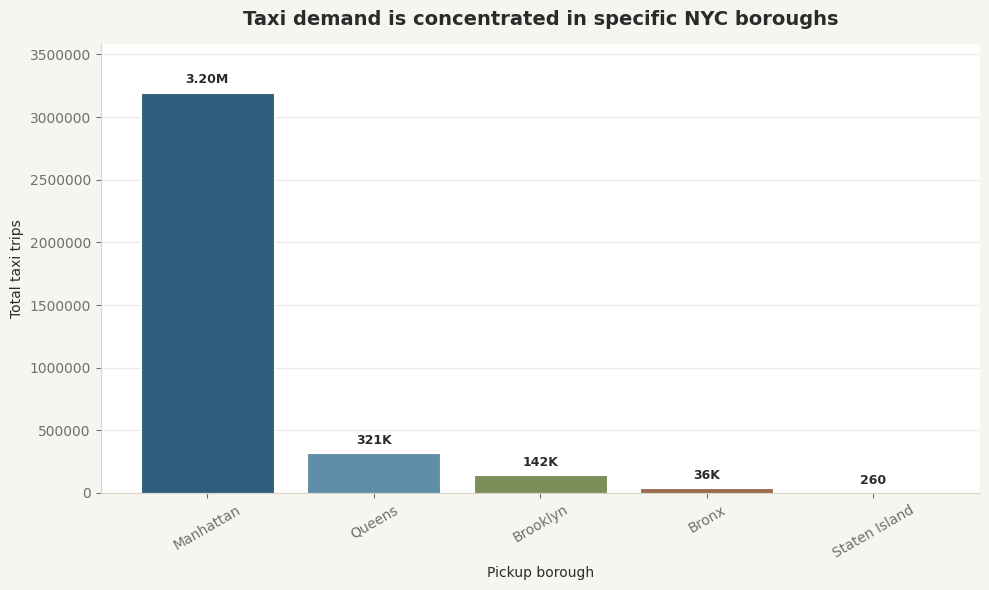

,pickup_borough,total_taxi_trips,yellow_taxi_trips,green_taxi_trips
0,Manhattan,3196309,3170897,25412
1,Queens,321397,312601,8796
2,Brooklyn,141851,135172,6679
3,Bronx,36085,34890,1195
4,Staten Island,260,252,8


In [106]:
# ============================================================
# VISUALISE TAXI DEMAND BY PICKUP BOROUGH
# ============================================================

taxi_borough_plot = run_sql("""
SELECT
    pickup_borough,
    total_taxi_trips,
    yellow_taxi_trips,
    green_taxi_trips
FROM taxi_borough_summary
ORDER BY total_taxi_trips DESC
""")

# NYC taxi analysis colour palette
NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "manhattan": "#2F5D7C",
    "queens": "#5F8FA8",
    "brooklyn": "#7A8F5A",
    "bronx": "#9A6B4F",
    "staten_island": "#8C6FA8",
    "ewr_unknown": "#B8B0A3"
}

borough_colors = {
    "Manhattan": NYC_COLORS["manhattan"],
    "Queens": NYC_COLORS["queens"],
    "Brooklyn": NYC_COLORS["brooklyn"],
    "Bronx": NYC_COLORS["bronx"],
    "Staten Island": NYC_COLORS["staten_island"],
    "EWR": NYC_COLORS["ewr_unknown"],
    "Unknown": NYC_COLORS["ewr_unknown"],
    "N/A": NYC_COLORS["ewr_unknown"]
}

def format_trips(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.0f}K"
    else:
        return f"{value:,.0f}"

fig, ax = plt.subplots(figsize=(10, 6), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["card"])

bars = ax.bar(
    taxi_borough_plot["pickup_borough"],
    taxi_borough_plot["total_taxi_trips"],
    color=[
        borough_colors.get(borough, NYC_COLORS["ewr_unknown"])
        for borough in taxi_borough_plot["pickup_borough"]
    ],
    edgecolor="white",
    linewidth=0.8
)

# Add value labels above bars
max_value = taxi_borough_plot["total_taxi_trips"].max()

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max_value * 0.015,
        format_trips(height),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=NYC_COLORS["text"]
    )

ax.set_title(
    "Taxi demand is concentrated in specific NYC boroughs",
    fontsize=14,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=14
)

ax.set_xlabel("Pickup borough", color=NYC_COLORS["text"])
ax.set_ylabel("Total taxi trips", color=NYC_COLORS["text"])

ax.tick_params(axis="x", colors=NYC_COLORS["muted_text"], rotation=30)
ax.tick_params(axis="y", colors=NYC_COLORS["muted_text"])

ax.grid(axis="y", color=NYC_COLORS["grid"], alpha=0.45)
ax.set_axisbelow(True)

ax.ticklabel_format(style="plain", axis="y")

# Add space at top so labels do not get cut off
ax.set_ylim(0, max_value * 1.12)

# Remove unnecessary borders for a cleaner consulting-style look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(NYC_COLORS["grid"])
ax.spines["bottom"].set_color(NYC_COLORS["grid"])

plt.tight_layout()
plt.show()

taxi_borough_plot

## 5.2 Taxi demand by hour

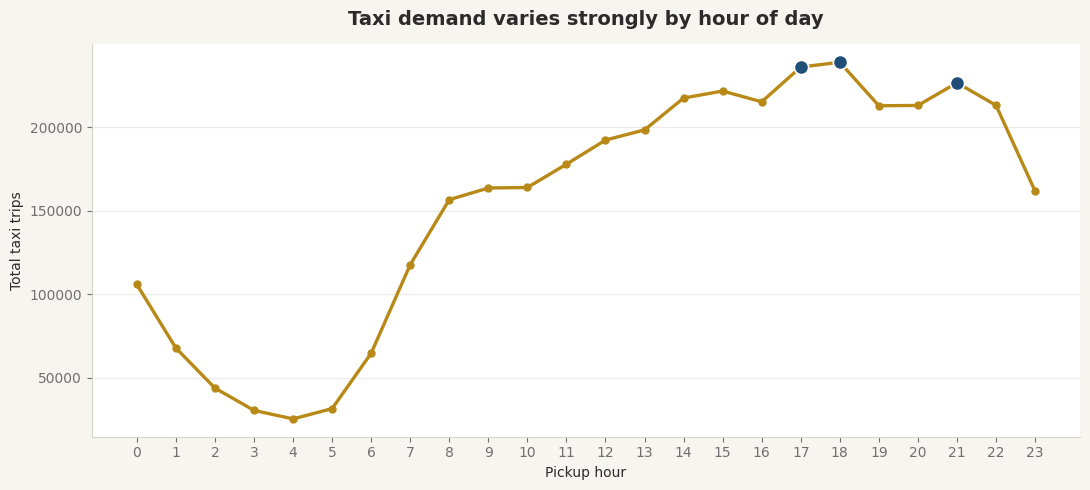

,pickup_hour,total_taxi_trips
0,0,105792
1,1,67700
2,2,43702
3,3,30329
4,4,25240
5,5,31393
6,6,64557
7,7,117628
8,8,156591
9,9,163600


In [107]:
# ============================================================
# VISUALISE TAXI DEMAND BY PICKUP HOUR
# ============================================================

taxi_hourly_plot = run_sql("""
SELECT
    pickup_hour,
    total_taxi_trips
FROM taxi_hourly_summary
ORDER BY pickup_hour
""")

# NYC taxi analysis colour palette
NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "taxi_gold": "#B88917",
    "peak": "#1F4E79"
}

fig, ax = plt.subplots(figsize=(11, 5), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["card"])

ax.plot(
    taxi_hourly_plot["pickup_hour"],
    taxi_hourly_plot["total_taxi_trips"],
    marker="o",
    markersize=5,
    linewidth=2.4,
    color=NYC_COLORS["taxi_gold"]
)

# ===== Top 3 peaks =====
top3 = taxi_hourly_plot.nlargest(3, "total_taxi_trips")

ax.scatter(
    top3["pickup_hour"],
    top3["total_taxi_trips"],
    color=NYC_COLORS["peak"],
    s=105,
    zorder=4,
    edgecolor="white",
    linewidth=1.2
)

ax.set_title(
    "Taxi demand varies strongly by hour of day",
    fontsize=14,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=14
)

ax.set_xlabel("Pickup hour", color=NYC_COLORS["text"])
ax.set_ylabel("Total taxi trips", color=NYC_COLORS["text"])

ax.set_xticks(range(0, 24))
ax.tick_params(axis="x", colors=NYC_COLORS["muted_text"])
ax.tick_params(axis="y", colors=NYC_COLORS["muted_text"])

ax.grid(axis="y", color=NYC_COLORS["grid"], alpha=0.45)
ax.set_axisbelow(True)

ax.ticklabel_format(style="plain", axis="y")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(NYC_COLORS["grid"])
ax.spines["bottom"].set_color(NYC_COLORS["grid"])

plt.tight_layout()
plt.show()

taxi_hourly_plot

## 5.3 Taxi trip distance pattern by borough

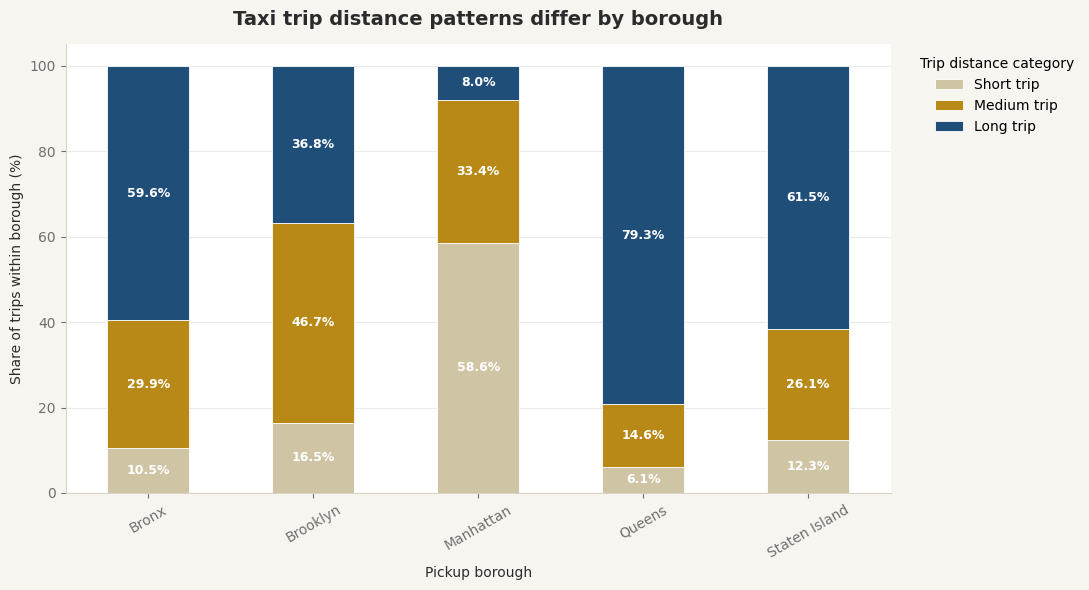

trip_distance_category,Short trip,Medium trip,Long trip
pickup_borough,,,
Bronx,10.49,29.91,59.60
Brooklyn,16.48,46.74,36.79
Manhattan,58.58,33.39,8.03
Queens,6.10,14.63,79.27
Staten Island,12.31,26.15,61.54


In [108]:
# ============================================================
# VISUALISE TAXI DISTANCE PATTERN BY BOROUGH
# ============================================================

distance_plot = run_sql("""
SELECT
    pickup_borough,
    trip_distance_category,
    share_within_borough_pct
FROM taxi_borough_distance_summary
WHERE trip_distance_category IN ('Short trip', 'Medium trip', 'Long trip')
ORDER BY pickup_borough, trip_distance_category
""")

distance_pivot = distance_plot.pivot(
    index="pickup_borough",
    columns="trip_distance_category",
    values="share_within_borough_pct"
).fillna(0)

distance_pivot = distance_pivot[["Short trip", "Medium trip", "Long trip"]]

# NYC taxi analysis colour palette
NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "short_trip": "#CFC4A3",    # muted sand
    "medium_trip": "#B88917",   # muted taxi gold
    "long_trip": "#1F4E79"      # deep navy
}

distance_colors = {
    "Short trip": NYC_COLORS["short_trip"],
    "Medium trip": NYC_COLORS["medium_trip"],
    "Long trip": NYC_COLORS["long_trip"]
}

fig, ax = plt.subplots(figsize=(11, 6), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["card"])

distance_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[distance_colors[col] for col in distance_pivot.columns],
    edgecolor="white",
    linewidth=0.6
)

# Add labels
for container in ax.containers:
    labels = []
    for value in container.datavalues:
        labels.append(f"{value:.1f}%" if value >= 5 else "")

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

ax.set_title(
    "Taxi trip distance patterns differ by borough",
    fontsize=14,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=14
)

ax.set_xlabel("Pickup borough", color=NYC_COLORS["text"])
ax.set_ylabel("Share of trips within borough (%)", color=NYC_COLORS["text"])

ax.tick_params(axis="x", colors=NYC_COLORS["muted_text"], rotation=30)
ax.tick_params(axis="y", colors=NYC_COLORS["muted_text"])

ax.grid(axis="y", color=NYC_COLORS["grid"], alpha=0.45)
ax.set_axisbelow(True)

ax.legend(
    title="Trip distance category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(NYC_COLORS["grid"])
ax.spines["bottom"].set_color(NYC_COLORS["grid"])

plt.tight_layout()
plt.show()

distance_pivot

## 5.4 Taxi vs subway context by borough and time period

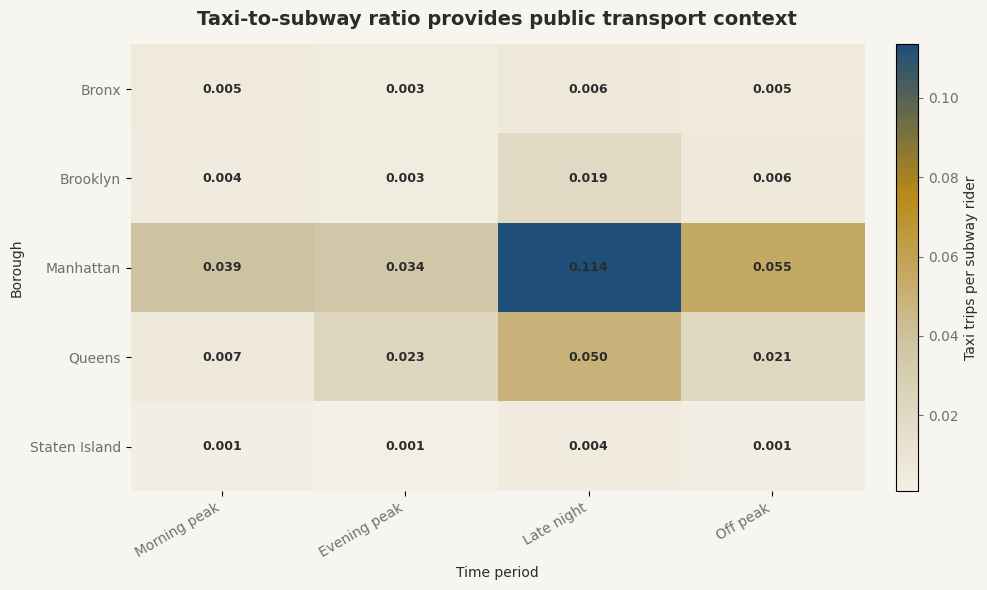

time_period,Morning peak,Evening peak,Late night,Off peak
borough,,,,
Bronx,0.0047,0.0031,0.0063,0.0049
Brooklyn,0.0041,0.0032,0.0195,0.0056
Manhattan,0.0389,0.0344,0.1135,0.0553
Queens,0.0069,0.0226,0.0496,0.0207
Staten Island,0.0013,0.0008,0.0037,0.0014


In [109]:
# ============================================================
# VISUALISE TAXI-TO-SUBWAY RATIO BY BOROUGH AND TIME PERIOD
# ============================================================

taxi_subway_plot = run_sql("""
SELECT
    borough,
    time_period,
    taxi_to_subway_ratio
FROM taxi_subway_comparison
WHERE taxi_to_subway_ratio IS NOT NULL
""")

# Set a clear order for time periods
time_order = ["Morning peak", "Evening peak", "Late night", "Off peak"]

taxi_subway_pivot = taxi_subway_plot.pivot(
    index="borough",
    columns="time_period",
    values="taxi_to_subway_ratio"
)

taxi_subway_pivot = taxi_subway_pivot[
    [col for col in time_order if col in taxi_subway_pivot.columns]
]

# NYC taxi analysis colour palette
NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "taxi_gold": "#B88917",
    "subway_blue": "#1F4E79"
}

# Muted blue-to-gold heatmap
taxi_subway_cmap = mcolors.LinearSegmentedColormap.from_list(
    "taxi_subway_cmap",
    ["#F4EFE4", "#CFC4A3", "#B88917", "#1F4E79"]
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["card"])

heatmap = ax.imshow(
    taxi_subway_pivot,
    aspect="auto",
    cmap=taxi_subway_cmap
)

ax.set_title(
    "Taxi-to-subway ratio provides public transport context",
    fontsize=14,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=14
)

ax.set_xlabel("Time period", color=NYC_COLORS["text"])
ax.set_ylabel("Borough", color=NYC_COLORS["text"])

ax.set_xticks(range(len(taxi_subway_pivot.columns)))
ax.set_xticklabels(
    taxi_subway_pivot.columns,
    rotation=30,
    ha="right",
    color=NYC_COLORS["muted_text"]
)

ax.set_yticks(range(len(taxi_subway_pivot.index)))
ax.set_yticklabels(
    taxi_subway_pivot.index,
    color=NYC_COLORS["muted_text"]
)

# Add value labels
for i in range(taxi_subway_pivot.shape[0]):
    for j in range(taxi_subway_pivot.shape[1]):
        value = taxi_subway_pivot.iloc[i, j]
        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=NYC_COLORS["text"]
            )

# Colour bar
cbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(
    "Taxi trips per subway rider",
    color=NYC_COLORS["text"]
)
cbar.ax.tick_params(colors=NYC_COLORS["muted_text"])

# Clean borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

taxi_subway_pivot

## 5.5 Intervention group summary

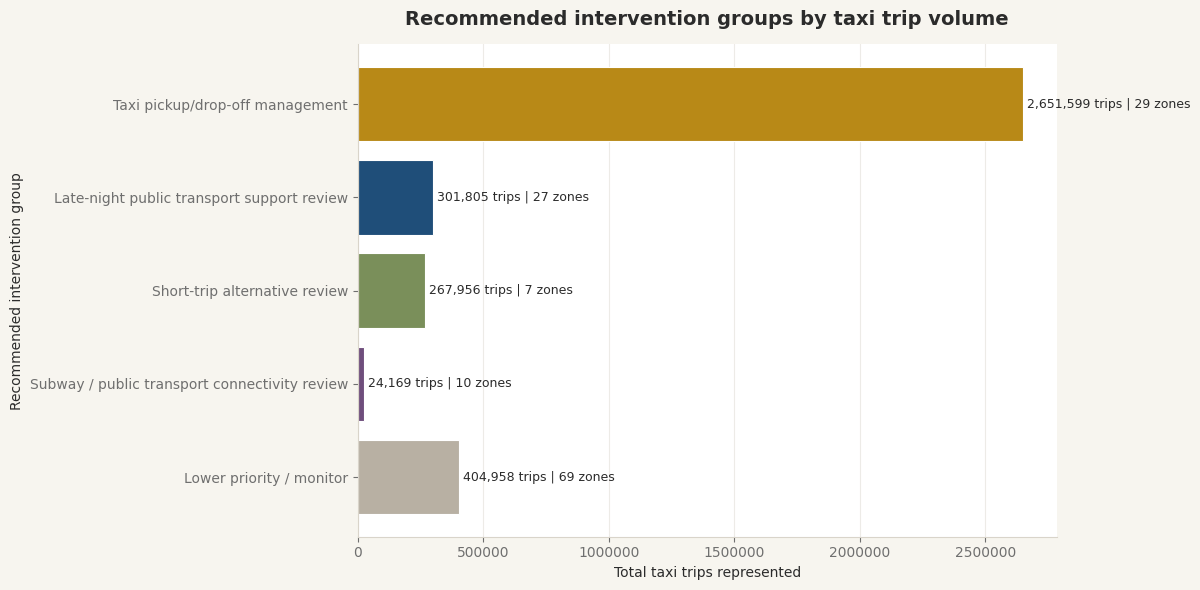

,recommended_intervention,zone_count,total_taxi_trips,avg_priority_score,avg_signal_count
0,Taxi pickup/drop-off management,29,2651599.0,3.83,2.24
1,Late-night public transport support review,27,301805.0,1.65,1.11
2,Short-trip alternative review,7,267956.0,1.50,1.00
3,Subway / public transport connectivity review,10,24169.0,1.00,1.00
4,Lower priority / monitor,69,404958.0,0.00,0.00


In [110]:
# ============================================================
# VISUALISE INTERVENTION GROUP SUMMARY
# ============================================================

intervention_plot = run_sql("""
SELECT
    recommended_intervention,
    zone_count,
    total_taxi_trips,
    avg_priority_score,
    avg_signal_count
FROM intervention_group_summary
ORDER BY
    CASE
        WHEN recommended_intervention = 'Taxi pickup/drop-off management' THEN 1
        WHEN recommended_intervention = 'Late-night public transport support review' THEN 2
        WHEN recommended_intervention = 'Short-trip alternative review' THEN 3
        WHEN recommended_intervention = 'Subway / public transport connectivity review' THEN 4
        WHEN recommended_intervention = 'Lower priority / monitor' THEN 5
        ELSE 6
    END,
    total_taxi_trips DESC
""")

# NYC taxi analysis colour palette
NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "taxi_gold": "#B88917",
    "late_night": "#1F4E79",
    "short_trip": "#7A8F5A",
    "connectivity": "#6F4E7C",
    "monitor": "#B8B0A3"
}

# Muted intervention palette
intervention_colours = {
    "Taxi pickup/drop-off management": NYC_COLORS["taxi_gold"],
    "Late-night public transport support review": NYC_COLORS["late_night"],
    "Short-trip alternative review": NYC_COLORS["short_trip"],
    "Subway / public transport connectivity review": NYC_COLORS["connectivity"],
    "Lower priority / monitor": NYC_COLORS["monitor"]
}

bar_colours = [
    intervention_colours.get(group, NYC_COLORS["monitor"])
    for group in intervention_plot["recommended_intervention"]
]

fig, ax = plt.subplots(figsize=(12, 6), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["card"])

bars = ax.barh(
    intervention_plot["recommended_intervention"],
    intervention_plot["total_taxi_trips"],
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8
)

ax.set_title(
    "Recommended intervention groups by taxi trip volume",
    fontsize=14,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=14
)

ax.set_xlabel("Total taxi trips represented", color=NYC_COLORS["text"])
ax.set_ylabel("Recommended intervention group", color=NYC_COLORS["text"])

ax.invert_yaxis()
ax.ticklabel_format(style="plain", axis="x")

ax.tick_params(axis="x", colors=NYC_COLORS["muted_text"])
ax.tick_params(axis="y", colors=NYC_COLORS["muted_text"])

ax.grid(axis="x", color=NYC_COLORS["grid"], alpha=0.45)
ax.set_axisbelow(True)

# Add labels at end of bars
for bar, trips, zones in zip(
    bars,
    intervention_plot["total_taxi_trips"],
    intervention_plot["zone_count"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {trips:,.0f} trips | {zones} zones",
        va="center",
        fontsize=9,
        color=NYC_COLORS["text"]
    )

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(NYC_COLORS["grid"])
ax.spines["bottom"].set_color(NYC_COLORS["grid"])

plt.tight_layout()
plt.show()

intervention_plot

## 5.6 Top priority taxi zones

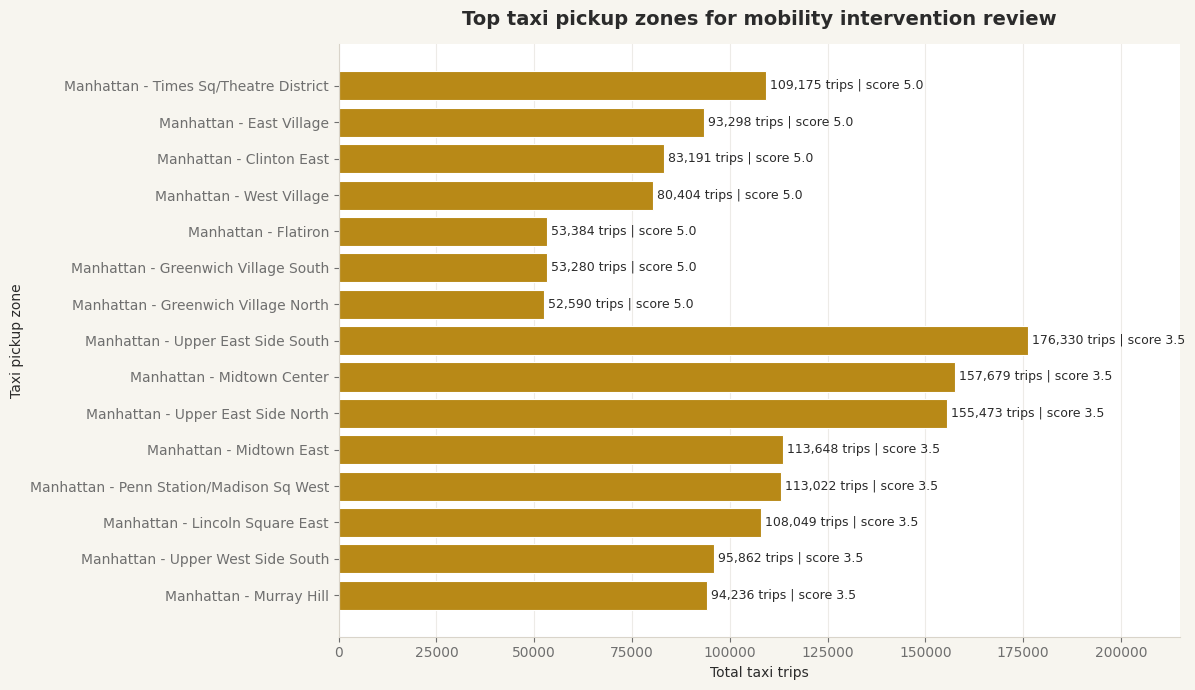

,zone_label,pickup_borough,pickup_zone,total_taxi_trips,priority_level,recommended_intervention,priority_score,signal_count,signal_summary,interpretation_note
0,Manhattan - Times Sq/Theatre District,Manhattan,Times Sq/Theatre District,109175,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,Candidate for curbside pickup/drop-off managem...
1,Manhattan - East Village,Manhattan,East Village,93298,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,Candidate for curbside pickup/drop-off managem...
2,Manhattan - Clinton East,Manhattan,Clinton East,83191,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,Candidate for curbside pickup/drop-off managem...
3,Manhattan - West Village,Manhattan,West Village,80404,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,Candidate for curbside pickup/drop-off managem...
4,Manhattan - Flatiron,Manhattan,Flatiron,53384,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,Candidate for curbside pickup/drop-off managem...
5,Manhattan - Greenwich Village South,Manhattan,Greenwich Village South,53280,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,Candidate for curbside pickup/drop-off managem...
6,Manhattan - Greenwich Village North,Manhattan,Greenwich Village North,52590,High priority,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...,Candidate for curbside pickup/drop-off managem...
7,Manhattan - Upper East Side South,Manhattan,Upper East Side South,176330,Medium priority,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...,Candidate for curbside pickup/drop-off managem...
8,Manhattan - Midtown Center,Manhattan,Midtown Center,157679,Medium priority,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...,Candidate for curbside pickup/drop-off managem...
9,Manhattan - Upper East Side North,Manhattan,Upper East Side North,155473,Medium priority,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...,Candidate for curbside pickup/drop-off managem...


In [111]:
# ============================================================
# VISUALISE TOP PRIORITY TAXI ZONES
# ============================================================

top_priority_zones = run_sql("""
SELECT
    pickup_borough || ' - ' || pickup_zone AS zone_label,
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    priority_level,
    recommended_intervention,
    priority_score,
    signal_count,
    signal_summary,
    interpretation_note
FROM taxi_zone_intervention_priority
WHERE recommended_intervention <> 'Lower priority / monitor'
ORDER BY
    priority_score DESC,
    total_taxi_trips DESC
LIMIT 15
""")

# NYC taxi analysis colour palette
NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "taxi_gold": "#B88917",
    "late_night": "#1F4E79",
    "short_trip": "#7A8F5A",
    "connectivity": "#6F4E7C",
    "monitor": "#B8B0A3"
}

# Muted intervention palette
intervention_colours = {
    "Taxi pickup/drop-off management": NYC_COLORS["taxi_gold"],
    "Late-night public transport support review": NYC_COLORS["late_night"],
    "Short-trip alternative review": NYC_COLORS["short_trip"],
    "Subway / public transport connectivity review": NYC_COLORS["connectivity"],
    "Lower priority / monitor": NYC_COLORS["monitor"]
}

bar_colours = [
    intervention_colours.get(group, NYC_COLORS["monitor"])
    for group in top_priority_zones["recommended_intervention"]
]

fig, ax = plt.subplots(figsize=(12, 7), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["card"])

bars = ax.barh(
    top_priority_zones["zone_label"],
    top_priority_zones["total_taxi_trips"],
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8
)

ax.set_title(
    "Top taxi pickup zones for mobility intervention review",
    fontsize=14,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=14
)

ax.set_xlabel("Total taxi trips", color=NYC_COLORS["text"])
ax.set_ylabel("Taxi pickup zone", color=NYC_COLORS["text"])

ax.invert_yaxis()
ax.ticklabel_format(style="plain", axis="x")

ax.tick_params(axis="x", colors=NYC_COLORS["muted_text"])
ax.tick_params(axis="y", colors=NYC_COLORS["muted_text"])

ax.grid(axis="x", color=NYC_COLORS["grid"], alpha=0.45)
ax.set_axisbelow(True)

# Add value labels
for bar, trips, score in zip(
    bars,
    top_priority_zones["total_taxi_trips"],
    top_priority_zones["priority_score"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {trips:,.0f} trips | score {score:.1f}",
        va="center",
        fontsize=9,
        color=NYC_COLORS["text"]
    )

# Give labels room on the right
ax.set_xlim(0, top_priority_zones["total_taxi_trips"].max() * 1.22)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(NYC_COLORS["grid"])
ax.spines["bottom"].set_color(NYC_COLORS["grid"])

plt.tight_layout()
plt.show()

top_priority_zones

## 5.7 Optional: visualise bus context

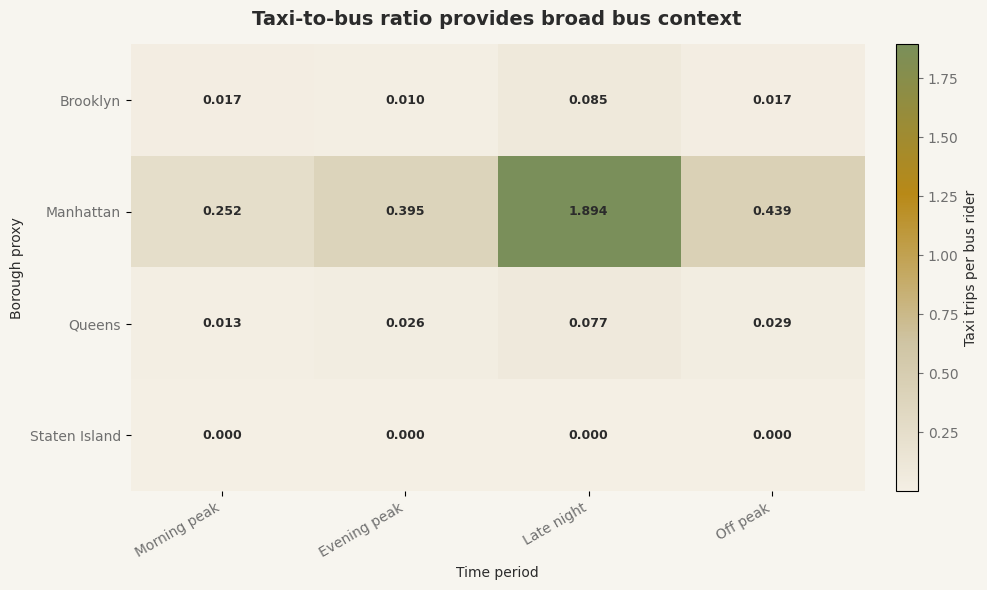

time_period,Morning peak,Evening peak,Late night,Off peak
borough,,,,
Brooklyn,0.0166,0.0098,0.0846,0.0174
Manhattan,0.2516,0.3954,1.8940,0.4391
Queens,0.0133,0.0256,0.0771,0.0295
Staten Island,0.0002,0.0001,0.0003,0.0001


In [112]:
# ============================================================
# OPTIONAL: TAXI-TO-BUS CONTEXT BY BOROUGH AND TIME PERIOD
# ============================================================

taxi_bus_plot = run_sql("""
SELECT
    borough,
    time_period,
    taxi_to_bus_ratio
FROM taxi_bus_comparison
WHERE taxi_to_bus_ratio IS NOT NULL
""")

taxi_bus_pivot = taxi_bus_plot.pivot(
    index="borough",
    columns="time_period",
    values="taxi_to_bus_ratio"
)

taxi_bus_pivot = taxi_bus_pivot[
    [col for col in time_order if col in taxi_bus_pivot.columns]
]

# NYC taxi analysis colour palette
NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "taxi_gold": "#B88917",
    "bus_green": "#7A8F5A"
}

# Muted beige-to-gold-to-green heatmap
taxi_bus_cmap = mcolors.LinearSegmentedColormap.from_list(
    "taxi_bus_cmap",
    ["#F4EFE4", "#CFC4A3", "#B88917", "#7A8F5A"]
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["card"])

heatmap = ax.imshow(
    taxi_bus_pivot,
    aspect="auto",
    cmap=taxi_bus_cmap
)

ax.set_title(
    "Taxi-to-bus ratio provides broad bus context",
    fontsize=14,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=14
)

ax.set_xlabel("Time period", color=NYC_COLORS["text"])
ax.set_ylabel("Borough proxy", color=NYC_COLORS["text"])

ax.set_xticks(range(len(taxi_bus_pivot.columns)))
ax.set_xticklabels(
    taxi_bus_pivot.columns,
    rotation=30,
    ha="right",
    color=NYC_COLORS["muted_text"]
)

ax.set_yticks(range(len(taxi_bus_pivot.index)))
ax.set_yticklabels(
    taxi_bus_pivot.index,
    color=NYC_COLORS["muted_text"]
)

# Add value labels
for i in range(taxi_bus_pivot.shape[0]):
    for j in range(taxi_bus_pivot.shape[1]):
        value = taxi_bus_pivot.iloc[i, j]
        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=NYC_COLORS["text"]
            )

# Colour bar
cbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(
    "Taxi trips per bus rider",
    color=NYC_COLORS["text"]
)
cbar.ax.tick_params(colors=NYC_COLORS["muted_text"])

# Clean borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

taxi_bus_pivot

## 5.8 Optional: Map visualisation

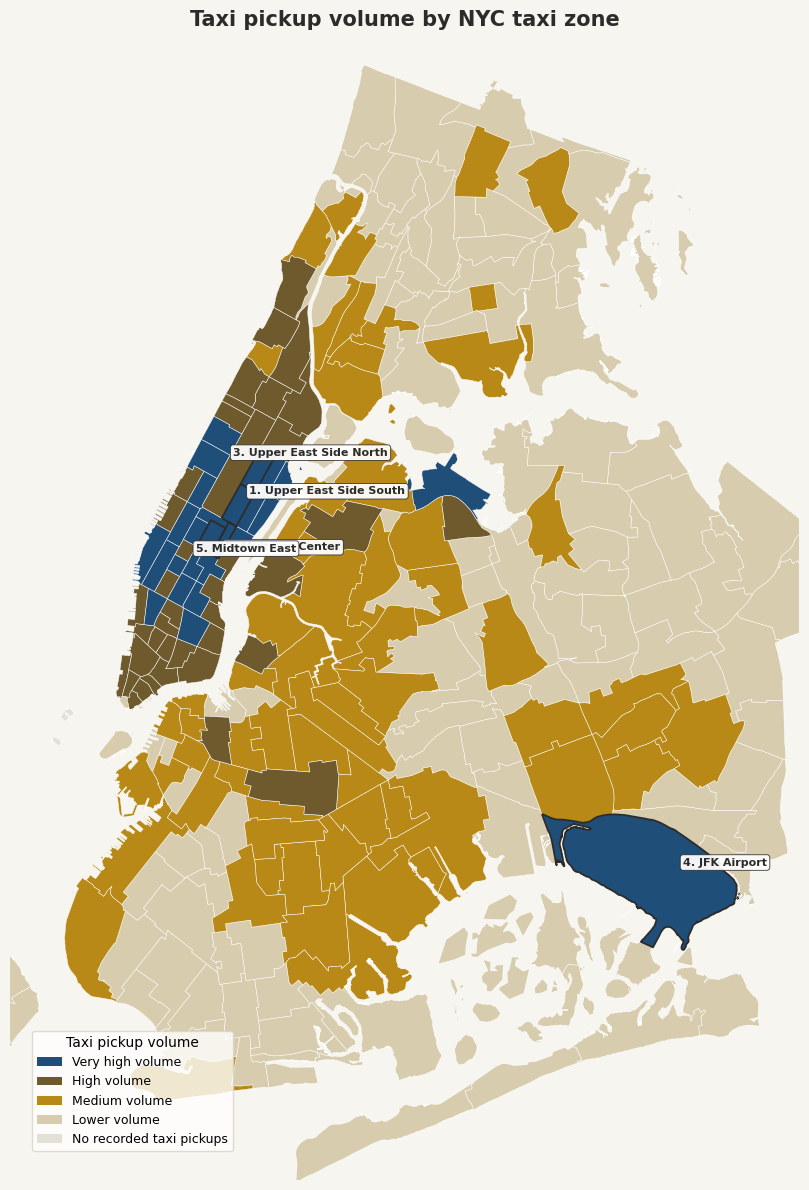

In [113]:
# ============================================================
# MAP: TAXI PICKUP VOLUME BY ZONE
# ============================================================

# ------------------------------------------------------------
# 1. LOAD TAXI PICKUP VOLUME BY ZONE
# ------------------------------------------------------------

taxi_volume_for_map = run_sql("""
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    avg_trip_distance_miles,
    avg_total_amount_usd
FROM taxi_zone_summary
""")

# Merge shapefile with taxi volume table
taxi_volume_map_df = taxi_zones_gdf.merge(
    taxi_volume_for_map,
    left_on="LocationID",
    right_on="pickup_location_id",
    how="left"
)

# Fill missing taxi trip values with 0
taxi_volume_map_df["total_taxi_trips"] = taxi_volume_map_df["total_taxi_trips"].fillna(0)

# ------------------------------------------------------------
# 2. CREATE VOLUME CATEGORIES
# ------------------------------------------------------------

active_zones = taxi_volume_map_df[taxi_volume_map_df["total_taxi_trips"] > 0].copy()

q50 = active_zones["total_taxi_trips"].quantile(0.50)
q75 = active_zones["total_taxi_trips"].quantile(0.75)
q90 = active_zones["total_taxi_trips"].quantile(0.90)

def classify_volume(trips):
    if trips == 0:
        return "No recorded taxi pickups"
    elif trips >= q90:
        return "Very high volume"
    elif trips >= q75:
        return "High volume"
    elif trips >= q50:
        return "Medium volume"
    else:
        return "Lower volume"

taxi_volume_map_df["pickup_volume_level"] = taxi_volume_map_df["total_taxi_trips"].apply(classify_volume)

# ------------------------------------------------------------
# 3. DEFINE NYC TAXI ANALYSIS COLOURS
# ------------------------------------------------------------

NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "no_data": "#E3E0D8",
    "lower_volume": "#D8CCAE",
    "medium_volume": "#B88917",
    "high_volume": "#6F5A2E",
    "very_high_volume": "#1F4E79"
}

volume_colour_map = {
    "Very high volume": NYC_COLORS["very_high_volume"],
    "High volume": NYC_COLORS["high_volume"],
    "Medium volume": NYC_COLORS["medium_volume"],
    "Lower volume": NYC_COLORS["lower_volume"],
    "No recorded taxi pickups": NYC_COLORS["no_data"]
}

plot_order = [
    "No recorded taxi pickups",
    "Lower volume",
    "Medium volume",
    "High volume",
    "Very high volume"
]

# ------------------------------------------------------------
# 4. IDENTIFY TOP 5 PICKUP ZONES
# ------------------------------------------------------------

top5_volume_zones = (
    taxi_volume_map_df[taxi_volume_map_df["total_taxi_trips"] > 0]
    .sort_values(by="total_taxi_trips", ascending=False)
    .head(5)
    .copy()
)

top5_volume_zones["map_label"] = [
    f"{i+1}. {zone}"
    for i, zone in enumerate(top5_volume_zones["pickup_zone"])
]

top5_volume_zones["label_point"] = top5_volume_zones.representative_point()

# ------------------------------------------------------------
# 5. PLOT MAP
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 12), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["background"])

# Base layer
taxi_zones_gdf.plot(
    ax=ax,
    color=NYC_COLORS["no_data"],
    edgecolor="white",
    linewidth=0.35
)

# Plot each volume category
for level in plot_order:
    subset = taxi_volume_map_df[taxi_volume_map_df["pickup_volume_level"] == level]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=volume_colour_map[level],
            edgecolor="white",
            linewidth=0.35
        )

# Highlight top 5 zones
if not top5_volume_zones.empty:
    top5_volume_zones.boundary.plot(
        ax=ax,
        color=NYC_COLORS["text"],
        linewidth=1.3
    )

# ------------------------------------------------------------
# 6. ZOOM INTO ACTIVE TAXI PICKUP AREAS
# ------------------------------------------------------------

zoom_df = taxi_volume_map_df[
    taxi_volume_map_df["pickup_volume_level"].isin([
        "Very high volume",
        "High volume",
        "Medium volume"
    ])
].copy()

if not zoom_df.empty:
    xmin, ymin, xmax, ymax = zoom_df.total_bounds

    pad_x = (xmax - xmin) * 0.08
    pad_y = (ymax - ymin) * 0.08

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

# ------------------------------------------------------------
# 7. ADD TOP 5 LABELS
# ------------------------------------------------------------

offsets = [(8, 8), (10, -10), (-18, 10), (12, 12), (-20, -8)]

for (_, row), (dx, dy) in zip(top5_volume_zones.iterrows(), offsets):
    x = row["label_point"].x
    y = row["label_point"].y

    ax.annotate(
        row["map_label"],
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color=NYC_COLORS["text"],
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor=NYC_COLORS["card"],
            edgecolor=NYC_COLORS["text"],
            linewidth=0.6,
            alpha=0.94
        )
    )

# ------------------------------------------------------------
# 8. CUSTOM LEGEND
# ------------------------------------------------------------

legend_items = [
    Patch(facecolor=volume_colour_map[level], edgecolor="none", label=level)
    for level in [
        "Very high volume",
        "High volume",
        "Medium volume",
        "Lower volume",
        "No recorded taxi pickups"
    ]
]

legend = ax.legend(
    handles=legend_items,
    title="Taxi pickup volume",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

legend.get_frame().set_facecolor(NYC_COLORS["card"])
legend.get_frame().set_edgecolor(NYC_COLORS["grid"])

# ------------------------------------------------------------
# 9. TITLE AND CLEAN LAYOUT
# ------------------------------------------------------------

ax.set_title(
    "Taxi pickup volume by NYC taxi zone",
    fontsize=15,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=15
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [114]:
# ============================================================
# TOP 10 TAXI PICKUP ZONES BY VOLUME
# ============================================================

top10_taxi_pickup_zones = run_sql("""
SELECT
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    avg_trip_distance_miles,
    avg_total_amount_usd
FROM taxi_zone_summary
ORDER BY total_taxi_trips DESC
LIMIT 10
""")

top10_taxi_pickup_zones

,pickup_borough,pickup_zone,total_taxi_trips,avg_trip_distance_miles,avg_total_amount_usd
0,Manhattan,Upper East Side South,176330,1.81,21.90
1,Manhattan,Midtown Center,157679,2.31,27.25
2,Manhattan,Upper East Side North,155473,2.03,22.50
3,Queens,JFK Airport,135796,14.79,77.78
4,Manhattan,Midtown East,113648,2.28,25.98
5,Manhattan,Penn Station/Madison Sq West,113022,2.30,26.42
6,Manhattan,Times Sq/Theatre District,109175,2.89,29.95
7,Manhattan,Lincoln Square East,108049,2.23,23.71
8,Manhattan,Upper West Side South,95862,2.28,23.58
9,Queens,LaGuardia Airport,94448,9.41,69.46


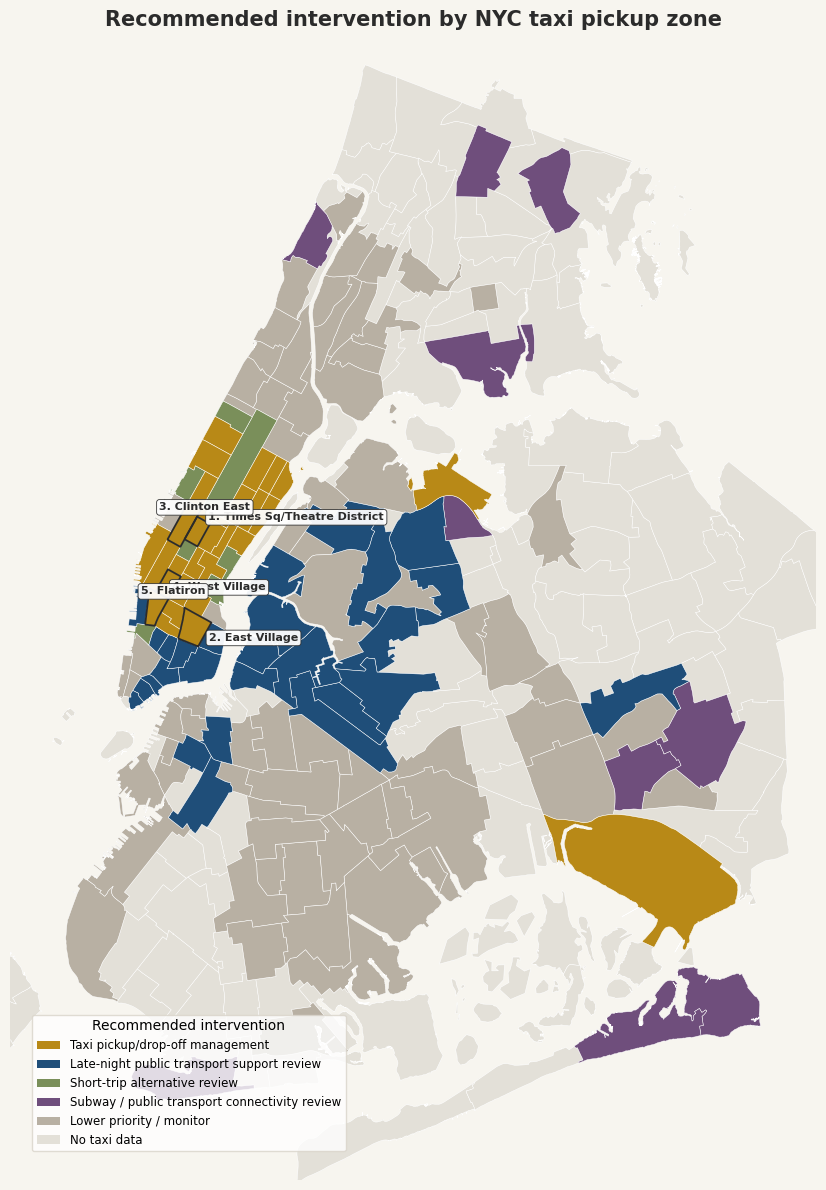

In [115]:
# ============================================================
# MAP: RECOMMENDED INTERVENTION BY TAXI PICKUP ZONE
# ------------------------------------------------------------
# 1. LOAD PRIORITY DATA FOR MAP
# ------------------------------------------------------------

priority_for_map = run_sql("""
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    priority_level,
    recommended_intervention,
    priority_score,
    signal_count,
    signal_summary,
    total_taxi_trips
FROM taxi_zone_intervention_priority
""")

map_df = taxi_zones_gdf.merge(
    priority_for_map,
    left_on="LocationID",
    right_on="pickup_location_id",
    how="left"
)

map_df["intervention_display"] = map_df["recommended_intervention"].fillna("No taxi data")

# ------------------------------------------------------------
# 2. MUTED NYC TAXI INTERVENTION COLOUR PALETTE
# ------------------------------------------------------------

NYC_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",
    "taxi_gold": "#B88917",
    "late_night": "#1F4E79",
    "short_trip": "#7A8F5A",
    "connectivity": "#6F4E7C",
    "monitor": "#B8B0A3",
    "no_data": "#E3E0D8"
}

intervention_colour_map = {
    "Taxi pickup/drop-off management": NYC_COLORS["taxi_gold"],
    "Late-night public transport support review": NYC_COLORS["late_night"],
    "Short-trip alternative review": NYC_COLORS["short_trip"],
    "Subway / public transport connectivity review": NYC_COLORS["connectivity"],
    "Lower priority / monitor": NYC_COLORS["monitor"],
    "No taxi data": NYC_COLORS["no_data"]
}

plot_order = [
    "No taxi data",
    "Lower priority / monitor",
    "Subway / public transport connectivity review",
    "Short-trip alternative review",
    "Late-night public transport support review",
    "Taxi pickup/drop-off management"
]

# ------------------------------------------------------------
# 3. TOP 5 IMPORTANT ZONES
# ------------------------------------------------------------

actionable_groups = [
    "Taxi pickup/drop-off management",
    "Late-night public transport support review",
    "Short-trip alternative review",
    "Subway / public transport connectivity review"
]

actionable_df = map_df[map_df["intervention_display"].isin(actionable_groups)].copy()

top5_zones = (
    actionable_df
    .sort_values(
        by=["priority_score", "total_taxi_trips"],
        ascending=[False, False]
    )
    .head(5)
    .copy()
)

top5_zones["map_label"] = [
    f"{i+1}. {zone}"
    for i, zone in enumerate(top5_zones["pickup_zone"])
]

top5_zones["label_point"] = top5_zones.representative_point()

# ------------------------------------------------------------
# 4. PLOT MAP
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 12), facecolor=NYC_COLORS["background"])
ax.set_facecolor(NYC_COLORS["background"])

# Base layer
taxi_zones_gdf.plot(
    ax=ax,
    color=NYC_COLORS["no_data"],
    edgecolor="white",
    linewidth=0.35
)

# Plot categories
for group in plot_order:
    subset = map_df[map_df["intervention_display"] == group]

    if not subset.empty:
        subset.plot(
            ax=ax,
            color=intervention_colour_map[group],
            edgecolor="white",
            linewidth=0.35
        )

# Highlight top 5 boundaries
if not top5_zones.empty:
    top5_zones.boundary.plot(
        ax=ax,
        color=NYC_COLORS["text"],
        linewidth=1.3
    )

# ------------------------------------------------------------
# 5. ZOOM INTO ACTIONABLE + MONITOR AREAS
# ------------------------------------------------------------

zoom_df = map_df[
    map_df["intervention_display"].isin([
        "Taxi pickup/drop-off management",
        "Late-night public transport support review",
        "Short-trip alternative review",
        "Subway / public transport connectivity review",
        "Lower priority / monitor"
    ])
].copy()

if not zoom_df.empty:
    xmin, ymin, xmax, ymax = zoom_df.total_bounds

    pad_x = (xmax - xmin) * 0.08
    pad_y = (ymax - ymin) * 0.08

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

# ------------------------------------------------------------
# 6. ADD TOP 5 LABELS
# ------------------------------------------------------------

offsets = [(8, 8), (10, -10), (-18, 10), (12, 12), (-20, -8)]

for (_, row), (dx, dy) in zip(top5_zones.iterrows(), offsets):
    x = row["label_point"].x
    y = row["label_point"].y

    ax.annotate(
        row["map_label"],
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color=NYC_COLORS["text"],
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor=NYC_COLORS["card"],
            edgecolor=NYC_COLORS["text"],
            linewidth=0.6,
            alpha=0.94
        )
    )

# ------------------------------------------------------------
# 7. CUSTOM LEGEND
# ------------------------------------------------------------

legend_order = [
    "Taxi pickup/drop-off management",
    "Late-night public transport support review",
    "Short-trip alternative review",
    "Subway / public transport connectivity review",
    "Lower priority / monitor",
    "No taxi data"
]

legend_items = [
    Patch(
        facecolor=intervention_colour_map[group],
        edgecolor="none",
        label=group
    )
    for group in legend_order
]

legend = ax.legend(
    handles=legend_items,
    title="Recommended intervention",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=True,
    fontsize=8.5,
    title_fontsize=10
)

legend.get_frame().set_facecolor(NYC_COLORS["card"])
legend.get_frame().set_edgecolor(NYC_COLORS["grid"])

# ------------------------------------------------------------
# 8. TITLE AND CLEAN LAYOUT
# ------------------------------------------------------------

ax.set_title(
    "Recommended intervention by NYC taxi pickup zone",
    fontsize=15,
    fontweight="bold",
    color=NYC_COLORS["text"],
    pad=15
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [116]:
# ============================================================
# TOP 5 PRIORITY ZONES SHOWN ON MAP
# ============================================================

top5_priority_table = (
    top5_zones[[
        "pickup_borough",
        "pickup_zone",
        "recommended_intervention",
        "priority_score",
        "signal_count",
        "signal_summary",
        "total_taxi_trips"
    ]]
    .reset_index(drop=True)
)

top5_priority_table.index = top5_priority_table.index + 1
top5_priority_table

,pickup_borough,pickup_zone,recommended_intervention,priority_score,signal_count,signal_summary,total_taxi_trips
1,Manhattan,Times Sq/Theatre District,Taxi pickup/drop-off management,5.0,3.0,High taxi pickup volume; High late-night taxi ...,109175.0
2,Manhattan,East Village,Taxi pickup/drop-off management,5.0,3.0,High taxi pickup volume; High late-night taxi ...,93298.0
3,Manhattan,Clinton East,Taxi pickup/drop-off management,5.0,3.0,High taxi pickup volume; High late-night taxi ...,83191.0
4,Manhattan,West Village,Taxi pickup/drop-off management,5.0,3.0,High taxi pickup volume; High late-night taxi ...,80404.0
5,Manhattan,Flatiron,Taxi pickup/drop-off management,5.0,3.0,High taxi pickup volume; High late-night taxi ...,53384.0


## 5.9 Option: Short taxi trips vs Citi Bike trips

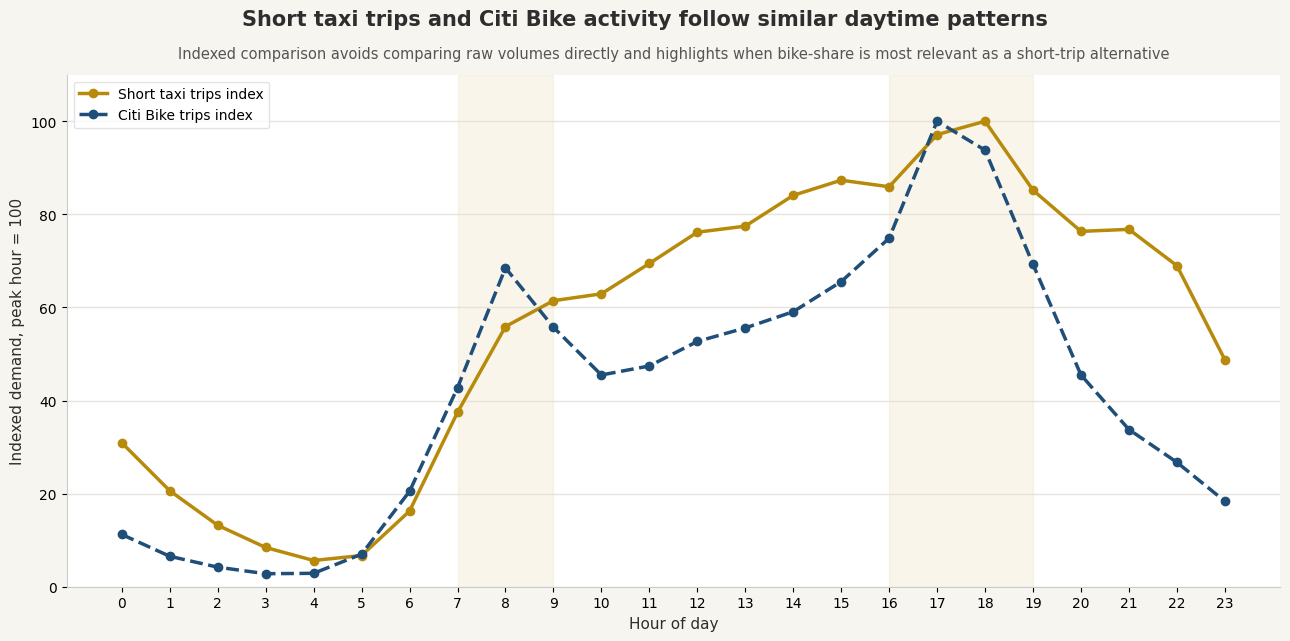

In [118]:
# ============================================================
# VISUAL: INDEXED SHORT TAXI VS CITI BIKE ACTIVITY BY HOUR
# Peak hour for each mode = 100
# ============================================================

df = taxi_bike_hourly_comparison.copy()
df = df.sort_values("hour")

df["short_taxi_index"] = df["short_taxi_trips"] / df["short_taxi_trips"].max() * 100
df["bike_index"] = df["bike_trips"] / df["bike_trips"].max() * 100

taxi_colour = "#B88A0B"
bike_colour = "#1F4E79"
background_colour = "#F7F5F0"
grid_colour = "#E2DED6"
text_colour = "#2E2E2E"

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor(background_colour)
ax.set_facecolor("white")

ax.plot(
    df["hour"],
    df["short_taxi_index"],
    marker="o",
    linewidth=2.5,
    color=taxi_colour,
    label="Short taxi trips index"
)

ax.plot(
    df["hour"],
    df["bike_index"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    color=bike_colour,
    label="Citi Bike trips index"
)

ax.axvspan(7, 9, alpha=0.08, color=taxi_colour)
ax.axvspan(16, 19, alpha=0.08, color=taxi_colour)

ax.set_xlabel("Hour of day", fontsize=11, color=text_colour)
ax.set_ylabel("Indexed demand, peak hour = 100", fontsize=11, color=text_colour)
ax.set_xticks(range(0, 24))
ax.set_ylim(0, 110)

ax.grid(axis="y", color=grid_colour, linewidth=1, alpha=0.8)

plt.suptitle(
    "Short taxi trips and Citi Bike activity follow similar daytime patterns",
    fontsize=15,
    fontweight="bold",
    color=text_colour,
    y=0.98
)

ax.set_title(
    "Indexed comparison avoids comparing raw volumes directly and highlights when bike-share is most relevant as a short-trip alternative",
    fontsize=10.5,
    color="#555555",
    pad=12
)

legend = ax.legend(loc="upper left", frameon=True, fontsize=10)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#DDDDDD")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.show()

# 6. Data security, privacy, governance, and ethics checkpoint

## 6.1 Data minimisation checkpoint

In [119]:
# ============================================================
# DATA MINIMISATION CHECKPOINT
# ============================================================

data_minimisation_log = pd.DataFrame([
    {
        "dataset": "Taxi",
        "fields_used": "pickup/dropoff datetime, pickup/dropoff location ID, borough, zone, trip distance, total amount, taxi type",
        "fields_avoided_or_limited": "vendor ID, payment type, passenger count for core demand analysis",
        "reason": "The analysis focuses on taxi demand by time, location, distance, and intervention priority. Passenger count has quality issues and is not used as the main demand metric."
    },
    {
        "dataset": "Taxi zone lookup",
        "fields_used": "LocationID, borough, zone, service zone",
        "fields_avoided_or_limited": "None beyond mapping fields",
        "reason": "Only required for joining location IDs to readable geographic areas."
    },
    {
        "dataset": "Subway",
        "fields_used": "transit timestamp, borough, station complex, ridership, transfers",
        "fields_avoided_or_limited": "Individual passenger information is not available or used",
        "reason": "Used only as aggregated public transport context by borough and time period."
    },
    {
        "dataset": "Bus",
        "fields_used": "transit timestamp, bus route, route prefix, ridership, transfers",
        "fields_avoided_or_limited": "Payment method and fare class are not used for behavioural claims",
        "reason": "Used only as broad route-level and time-period public transport context."
    },
    {
    "dataset": "Citi Bike",
    "fields_used": "ride ID, start/end time, station names, coordinates, bike type, user type",
    "fields_avoided_or_limited": "No individual ride paths are visualised; station IDs are treated as text identifiers; coordinates are used only for aggregated station/spatial checks",
    "reason": "Used as aggregated context for assessing whether Citi Bike may support short-trip taxi alternatives, without analysing individual-level movement patterns."
    }
])

data_minimisation_log

,dataset,fields_used,fields_avoided_or_limited,reason
0,Taxi,"pickup/dropoff datetime, pickup/dropoff locati...","vendor ID, payment type, passenger count for c...","The analysis focuses on taxi demand by time, l..."
1,Taxi zone lookup,"LocationID, borough, zone, service zone",None beyond mapping fields,Only required for joining location IDs to read...
2,Subway,"transit timestamp, borough, station complex, r...",Individual passenger information is not availa...,Used only as aggregated public transport conte...
3,Bus,"transit timestamp, bus route, route prefix, ri...",Payment method and fare class are not used for...,Used only as broad route-level and time-period...
4,Citi Bike,"ride ID, start/end time, station names, coordi...",No individual ride paths are visualised; stati...,Used as aggregated context for assessing wheth...


## 6.2. Aggregation/privacy checkpoint

In [120]:
# ============================================================
# PRIVACY-AWARE AGGREGATION CHECKPOINT
# ============================================================

aggregation_control_log = pd.DataFrame([
    {
        "analysis_output": "Taxi demand by borough",
        "aggregation_level": "Borough",
        "privacy_control": "Aggregates many trips into borough-level totals",
        "why_it_matters": "Avoids showing individual pickup/dropoff movements"
    },
    {
        "analysis_output": "Taxi demand by pickup hour",
        "aggregation_level": "Hourly summary",
        "privacy_control": "Uses total trips by hour rather than individual timestamps",
        "why_it_matters": "Reduces risk of identifying repeated travel behaviour"
    },
    {
        "analysis_output": "Taxi distance pattern by borough",
        "aggregation_level": "Borough + distance category",
        "privacy_control": "Uses distance categories instead of individual trip distances",
        "why_it_matters": "Supports strategic interpretation without exposing specific trips"
    },
    {
        "analysis_output": "Taxi-to-subway ratio",
        "aggregation_level": "Borough + time period",
        "privacy_control": "Compares aggregate taxi trips and aggregate subway ridership",
        "why_it_matters": "Avoids individual-level public transport inference"
    },
    {
        "analysis_output": "Taxi-to-bus ratio",
        "aggregation_level": "Borough proxy + time period",
        "privacy_control": "Uses aggregate bus ridership and taxi trips",
        "why_it_matters": "Provides context without claiming individual mode substitution"
    },
    {
        "analysis_output": "Taxi pickup volume map",
        "aggregation_level": "Taxi zone",
        "privacy_control": "Maps zone-level volume categories rather than raw pickup points",
        "why_it_matters": "Reduces spatial precision and avoids trip-level mapping"
    },
    {
        "analysis_output": "Short taxi trips vs Citi Bike activity by hour",
        "aggregation_level": "Hourly summary",
        "privacy_control": "Compares aggregated hourly counts rather than individual taxi or bike trips",
        "why_it_matters": "Supports short-trip alternative analysis without showing individual ride paths, exact trips, or repeated travel behaviour"
    },
    {
        "analysis_output": "Recommended intervention map",
        "aggregation_level": "Taxi zone intervention category",
        "privacy_control": "Shows policy-relevant categories, not individual trip records",
        "why_it_matters": "Supports planning while avoiding individual mobility disclosure"
    }
])

aggregation_control_log

,analysis_output,aggregation_level,privacy_control,why_it_matters
0,Taxi demand by borough,Borough,Aggregates many trips into borough-level totals,Avoids showing individual pickup/dropoff movem...
1,Taxi demand by pickup hour,Hourly summary,Uses total trips by hour rather than individua...,Reduces risk of identifying repeated travel be...
2,Taxi distance pattern by borough,Borough + distance category,Uses distance categories instead of individual...,Supports strategic interpretation without expo...
3,Taxi-to-subway ratio,Borough + time period,Compares aggregate taxi trips and aggregate su...,Avoids individual-level public transport infer...
4,Taxi-to-bus ratio,Borough proxy + time period,Uses aggregate bus ridership and taxi trips,Provides context without claiming individual m...
5,Taxi pickup volume map,Taxi zone,Maps zone-level volume categories rather than ...,Reduces spatial precision and avoids trip-leve...
6,Short taxi trips vs Citi Bike activity by hour,Hourly summary,Compares aggregated hourly counts rather than ...,Supports short-trip alternative analysis witho...
7,Recommended intervention map,Taxi zone intervention category,"Shows policy-relevant categories, not individu...",Supports planning while avoiding individual mo...


## 6.3. Recommendation wording checkpoint

In [121]:
# ============================================================
# RESPONSIBLE INTERPRETATION AND WORDING CHECKPOINT
# ============================================================

responsible_wording_log = pd.DataFrame([
    {
        "analysis_signal": "High taxi demand in a borough or zone",
        "avoid_claiming": "People in this area rely on taxis more than others",
        "use_instead": "This area shows high recorded taxi pickup activity and may require operational review"
    },
    {
        "analysis_signal": "High taxi-to-subway ratio",
        "avoid_claiming": "Subway service is poor or unavailable",
        "use_instead": "Taxi use is high relative to subway ridership, suggesting a public transport context worth reviewing"
    },
    {
        "analysis_signal": "High late-night taxi activity",
        "avoid_claiming": "Residents have no safe late-night transport",
        "use_instead": "Late-night taxi demand is elevated, which may justify reviewing late-night mobility options"
    },
    {
        "analysis_signal": "Short taxi trips concentrated in a zone",
        "avoid_claiming": "People should switch to bikes or buses",
        "use_instead": "Short-trip concentration suggests potential for investigating alternative short-distance mobility options"
    },
    {
        "analysis_signal": "Low taxi activity",
        "avoid_claiming": "This area has low mobility need",
        "use_instead": "Recorded taxi activity is low; this does not capture unmet demand or non-taxi travel needs"
    }
])

responsible_wording_log

,analysis_signal,avoid_claiming,use_instead
0,High taxi demand in a borough or zone,People in this area rely on taxis more than ot...,This area shows high recorded taxi pickup acti...
1,High taxi-to-subway ratio,Subway service is poor or unavailable,"Taxi use is high relative to subway ridership,..."
2,High late-night taxi activity,Residents have no safe late-night transport,"Late-night taxi demand is elevated, which may ..."
3,Short taxi trips concentrated in a zone,People should switch to bikes or buses,Short-trip concentration suggests potential fo...
4,Low taxi activity,This area has low mobility need,Recorded taxi activity is low; this does not c...


## 6.4 Assumptions & Limitations

In [122]:
# ============================================================
# ANALYSIS ASSUMPTIONS AND LIMITATIONS LOG
# ============================================================

analysis_assumptions_log = pd.DataFrame([
    {
        "assumption": "April 2026 is used as the consistent analysis period.",
        "where_used_in_analysis": "All taxi, subway, bus, and bike comparisons",
        "why_it_is_needed": "A consistent month makes cross-mode comparison more meaningful.",
        "limitation": "Findings may not represent other months, seasonal effects, weather, or major events."
    },
    {
        "assumption": "Total taxi trips are used as the main proxy for taxi demand.",
        "where_used_in_analysis": "Borough demand, hourly demand, zone volume map, intervention priority",
        "why_it_is_needed": "Trip count is the most reliable and consistent taxi demand measure in the dataset.",
        "limitation": "It does not capture unmet demand, cancelled trips, wait times, or number of passengers."
    },
    {
        "assumption": "Pickup location is used to represent where taxi demand originates.",
        "where_used_in_analysis": "Pickup borough analysis, pickup zone map, intervention recommendations",
        "why_it_is_needed": "The project question focuses on where taxi demand starts.",
        "limitation": "Dropoff locations may reveal different destination-side pressures."
    },
    {
        "assumption": "Passenger count is not used as the primary demand measure.",
        "where_used_in_analysis": "Taxi demand metrics and intervention scoring",
        "why_it_is_needed": "The audit showed substantial missing or unusual passenger count values.",
        "limitation": "Trip count may understate total people moved by taxi."
    },
    {
        "assumption": "Taxi-to-subway and taxi-to-bus ratios are contextual indicators, not proof of substitution.",
        "where_used_in_analysis": "Public transport comparison and intervention scoring",
        "why_it_is_needed": "The ratios help compare taxi activity with public transport context.",
        "limitation": "Taxi trips and public transport ridership are different units and cannot prove why people chose one mode."
    },
    {
        "assumption": "Short, medium, and long trip categories are simplified analytical groups.",
        "where_used_in_analysis": "Distance pattern analysis and short-trip alternative review",
        "why_it_is_needed": "Distance categories make trip patterns easier to connect to potential interventions.",
        "limitation": "Thresholds may not reflect passenger needs, accessibility, safety, or route availability."
    },
    {
        "assumption": "Taxi and Citi Bike hourly counts are compared as patterns, not as directly equivalent transport volumes.",
        "where_used_in_analysis": "Indexed taxi-bike hourly comparison",
        "why_it_is_needed": "Taxi trips and bike-share trips represent different modes with different capacities, users, and trip purposes.",
        "limitation": "Similar hourly patterns do not prove that taxi passengers would switch to Citi Bike."
    },
    {
        "assumption": "Priority scores are decision-support signals.",
        "where_used_in_analysis": "Top priority zones and recommended intervention map",
        "why_it_is_needed": "The score combines several indicators into a practical ranking.",
        "limitation": "Changing thresholds or weights could change the ranking."
    }
])

analysis_assumptions_log

,assumption,where_used_in_analysis,why_it_is_needed,limitation
0,April 2026 is used as the consistent analysis ...,"All taxi, subway, bus, and bike comparisons",A consistent month makes cross-mode comparison...,"Findings may not represent other months, seaso..."
1,Total taxi trips are used as the main proxy fo...,"Borough demand, hourly demand, zone volume map...",Trip count is the most reliable and consistent...,"It does not capture unmet demand, cancelled tr..."
2,Pickup location is used to represent where tax...,"Pickup borough analysis, pickup zone map, inte...",The project question focuses on where taxi dem...,Dropoff locations may reveal different destina...
3,Passenger count is not used as the primary dem...,Taxi demand metrics and intervention scoring,The audit showed substantial missing or unusua...,Trip count may understate total people moved b...
4,Taxi-to-subway and taxi-to-bus ratios are cont...,Public transport comparison and intervention s...,The ratios help compare taxi activity with pub...,Taxi trips and public transport ridership are ...
5,"Short, medium, and long trip categories are si...",Distance pattern analysis and short-trip alter...,Distance categories make trip patterns easier ...,"Thresholds may not reflect passenger needs, ac..."
6,Taxi and Citi Bike hourly counts are compared ...,Indexed taxi-bike hourly comparison,Taxi trips and bike-share trips represent diff...,Similar hourly patterns do not prove that taxi...
7,Priority scores are decision-support signals.,Top priority zones and recommended interventio...,The score combines several indicators into a p...,Changing thresholds or weights could change th...


# 7. Data story panels for the written report

This section creates the main visual panels used in the written report. The panels are organised around the report’s three-stage data story: **overview**, **issue identification**, and **recommendations**.

The purpose of this section is to connect the engineered SQL summary tables to clear visual evidence for the report. These panels support the main findings in the written report, while extended SQL outputs, detailed rankings and additional checks are placed in the appendices.

---

**Panel 1 — Overview: where and when is taxi demand highest?**

This panel summarises the overall taxi demand pattern in April 2026. It focuses on where taxi pickups are concentrated and when taxi demand is strongest.

**Visual outputs:**
- Taxi demand by pickup borough
- Top taxi pickup zones
- Taxi demand by pickup hour

**Report purpose:**
- Supports the overview finding that taxi demand is concentrated by geography and time
- Shows why high-volume areas may need taxi pickup/drop-off management
- Provides the starting point for the more detailed issue-identification analysis

---

**Panel 2 — Issue identification: what demand patterns explain intervention needs?**

This panel investigates the taxi demand patterns that may indicate different mobility issues. It separates high taxi volume from late-night reliance, short-trip concentration and long-distance travel patterns. It also adds supporting context from subway, bus and Citi Bike activity.

**Visual outputs:**
- Taxi trip-distance pattern by borough
- Late-night taxi concentration
- Taxi-to-subway ratio by borough and time period
- Taxi-to-bus comparison using the route-prefix borough proxy
- Short taxi trips versus Citi Bike activity by hour

**Report purpose:**
- Shows that different taxi patterns suggest different planning responses
- Supports the distinction between pickup/drop-off management, late-night service review, short-trip alternative review and connectivity review
- Uses subway, bus and Citi Bike as contextual evidence, not proof of direct service gaps

---

**Panel 3 — Recommendations: which zones should be prioritised?**

This panel converts the analysis into decision-support outputs. Taxi zones are grouped into intervention categories based on taxi volume, late-night share, short-trip share, long-trip share, average distance and cost.

**Visual outputs:**
- Intervention group summary
- Top priority taxi zones
- Recommended intervention map

**Report purpose:**
- Supports the recommendation that intervention type should match the demand signal
- Presents priority zones as candidates for further planning review
- Avoids treating taxi demand as final proof of infrastructure need

In [123]:
# ============================================================
# DASHBOARD HELPER FUNCTIONS AND STYLE
# ============================================================

# Shared dashboard colour palette
# ------------------------------------------------------------
DASH_COLORS = {
    "background": "#F7F5EF",
    "card": "#FFFFFF",
    "text": "#2B2B2B",
    "muted_text": "#6F6F6F",
    "grid": "#D9D4CA",

    "taxi_yellow": "#FFC300",
    "taxi_dark_yellow": "#B8860B",
    "subway_blue": "#1F77B4",
    "bus_green": "#2CA02C",
    "bike_teal": "#17A589",

    "blue": "#1F77B4",
    "red": "#D62728",
    "orange": "#FF7F0E",
    "purple": "#9467BD",
    "grey": "#A6A6A6",
    "light_grey": "#F2F2F2"
}

INTERVENTION_COLORS = {
    "Taxi pickup/drop-off management": "#1F77B4",
    "Late-night public transport support review": "#D62728",
    "Short-trip alternative review": "#FF7F0E",
    "Subway / public transport connectivity review": "#9467BD",
    "Lower priority / monitor": "#A6A6A6",
    "No taxi data": "#F2F2F2"
}

BOROUGH_COLORS = {
    "Manhattan": "#2F5D7C",
    "Queens": "#5F8FA8",
    "Brooklyn": "#7A8F5A",
    "Bronx": "#9A6B4F",
    "Staten Island": "#8C6FA8",
    "EWR": "#B8B0A3",
    "Unknown": "#B8B0A3",
    "N/A": "#B8B0A3"
}

def format_number(value):
    """Format large numbers for labels and KPI cards."""
    if pd.isna(value):
        return "N/A"
    value = float(value)
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.0f}K"
    else:
        return f"{value:,.0f}"

def wrap_labels(labels, width=26):
    """Wrap long labels for horizontal bar charts."""
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]

def style_axis(ax, grid_axis="y"):
    """Apply consistent consulting-style chart formatting."""
    ax.set_facecolor(DASH_COLORS["card"])
    ax.grid(axis=grid_axis, color=DASH_COLORS["grid"], alpha=0.45)
    ax.set_axisbelow(True)
    ax.tick_params(colors=DASH_COLORS["muted_text"])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(DASH_COLORS["grid"])
    ax.spines["bottom"].set_color(DASH_COLORS["grid"])

def draw_kpi_card(ax, value, label, accent_color=None):
    """Draw one KPI card."""
    if accent_color is None:
        accent_color = DASH_COLORS["taxi_dark_yellow"]

    ax.set_facecolor(DASH_COLORS["card"])

    ax.text(
        0.08, 0.62,
        value,
        fontsize=20,
        fontweight="bold",
        color=DASH_COLORS["text"],
        transform=ax.transAxes
    )

    ax.text(
        0.08, 0.28,
        label,
        fontsize=9.5,
        color=DASH_COLORS["muted_text"],
        transform=ax.transAxes
    )

    # Use plot instead of axvline because axvline does not accept transform
    ax.plot(
        [0.03, 0.03],
        [0.18, 0.82],
        color=accent_color,
        linewidth=4,
        transform=ax.transAxes,
        clip_on=False
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_color(DASH_COLORS["grid"])

## Dashboard 1 — NYC mobility overview

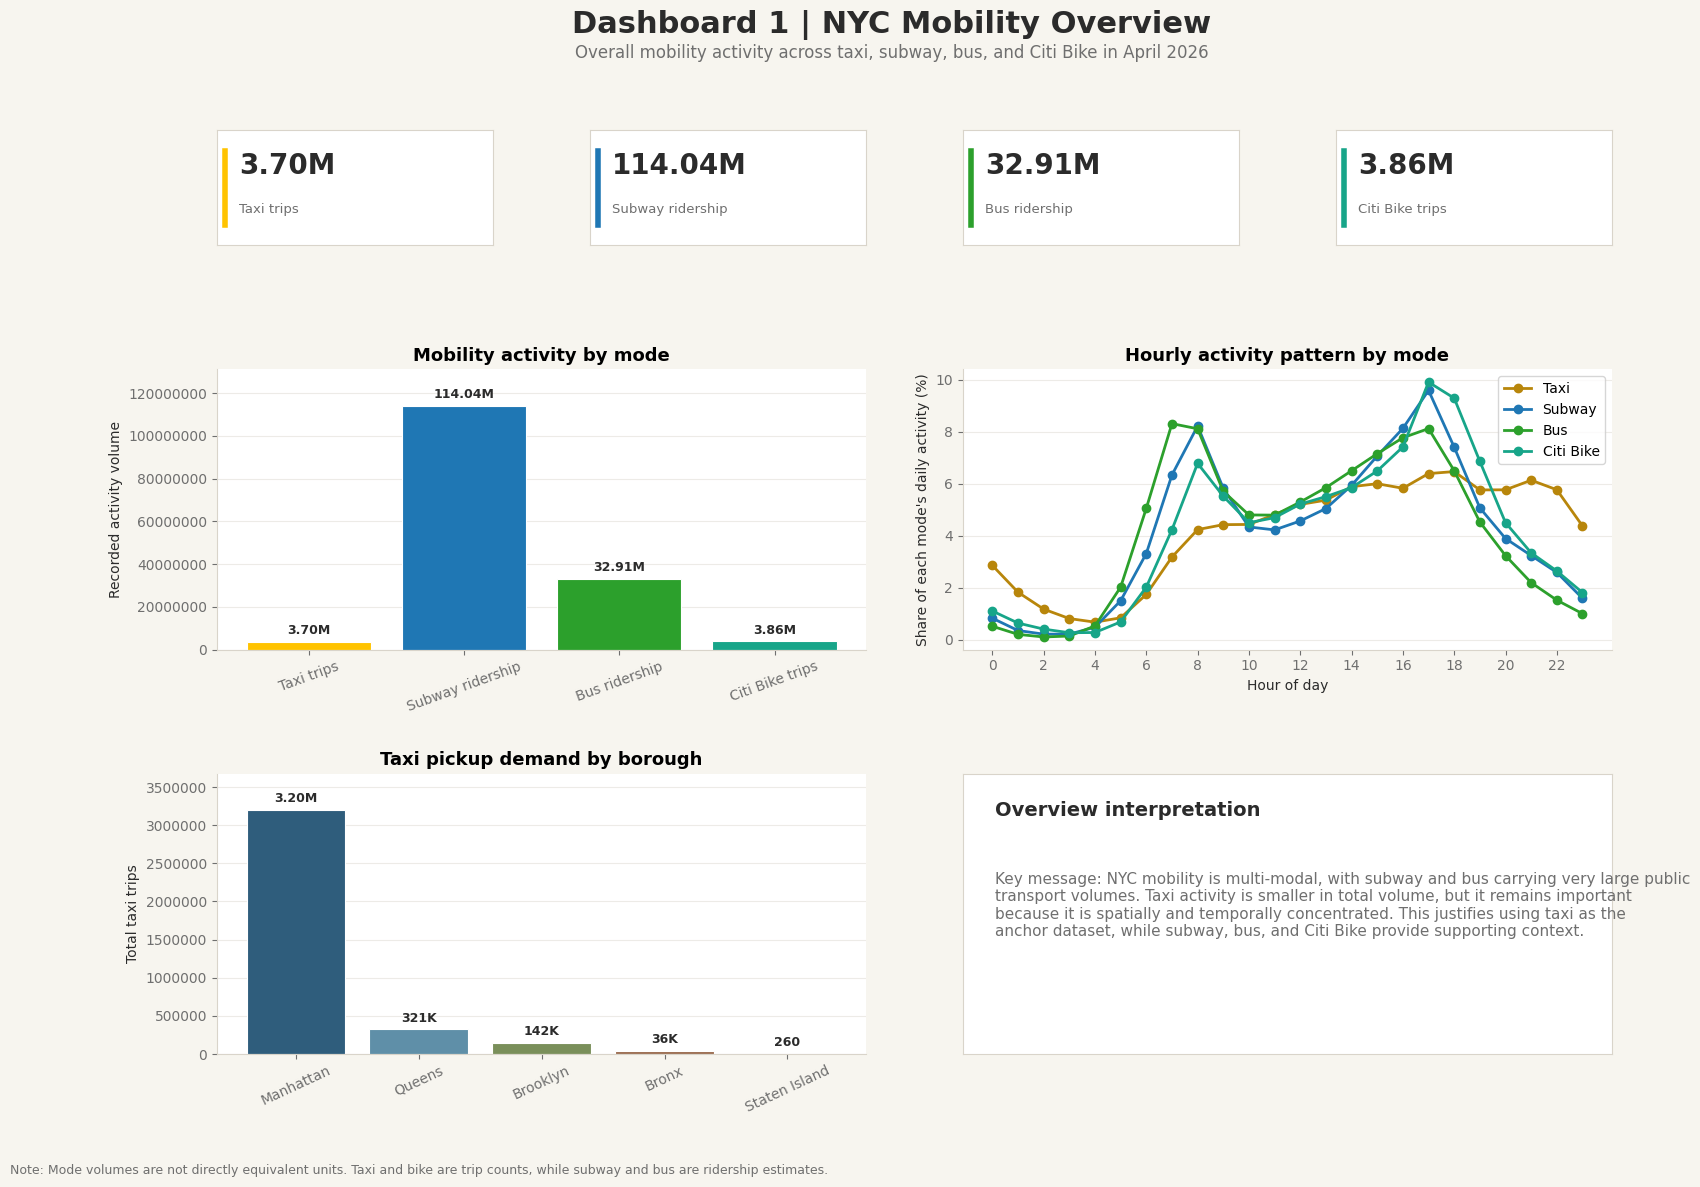

In [124]:
# ============================================================
# DASHBOARD 1: NYC MOBILITY OVERVIEW
# ============================================================

# ------------------------------------------------------------
# 1. Data for overview dashboard
# ------------------------------------------------------------

overview_kpis = run_sql("""
WITH taxi AS (
    SELECT COUNT(*) AS taxi_trips
    FROM taxi_features
    WHERE is_nyc_pickup_borough = 1
),

subway AS (
    SELECT SUM(ridership) AS subway_ridership
    FROM subway_clean
),

bus AS (
    SELECT SUM(ridership) AS bus_ridership
    FROM bus_clean
),

bike AS (
    SELECT COUNT(*) AS bike_trips
    FROM bike_clean
),

zones AS (
    SELECT COUNT(DISTINCT pickup_location_id) AS active_taxi_zones
    FROM taxi_features
    WHERE is_nyc_pickup_borough = 1
)

SELECT
    taxi.taxi_trips,
    subway.subway_ridership,
    bus.bus_ridership,
    bike.bike_trips,
    zones.active_taxi_zones
FROM taxi, subway, bus, bike, zones
""")

mode_volume = run_sql("""
SELECT 'Taxi trips' AS mode, COUNT(*) AS volume
FROM taxi_features
WHERE is_nyc_pickup_borough = 1

UNION ALL

SELECT 'Subway ridership' AS mode, SUM(ridership) AS volume
FROM subway_clean

UNION ALL

SELECT 'Bus ridership' AS mode, SUM(ridership) AS volume
FROM bus_clean

UNION ALL

SELECT 'Citi Bike trips' AS mode, COUNT(*) AS volume
FROM bike_clean
""")

hourly_mode_share = run_sql("""
WITH hourly_raw AS (
    SELECT
        'Taxi' AS mode,
        pickup_hour AS hour,
        COUNT(*) AS volume
    FROM taxi_features
    WHERE is_nyc_pickup_borough = 1
    GROUP BY pickup_hour

    UNION ALL

    SELECT
        'Subway' AS mode,
        transit_hour AS hour,
        SUM(ridership) AS volume
    FROM subway_clean
    GROUP BY transit_hour

    UNION ALL

    SELECT
        'Bus' AS mode,
        transit_hour AS hour,
        SUM(ridership) AS volume
    FROM bus_clean
    GROUP BY transit_hour

    UNION ALL

    SELECT
        'Citi Bike' AS mode,
        start_hour AS hour,
        COUNT(*) AS volume
    FROM bike_clean
    GROUP BY start_hour
),

indexed AS (
    SELECT
        mode,
        hour,
        volume,
        100.0 * volume / SUM(volume) OVER (PARTITION BY mode) AS hourly_share_pct
    FROM hourly_raw
)

SELECT *
FROM indexed
ORDER BY mode, hour
""")

taxi_borough_overview = run_sql("""
SELECT
    pickup_borough,
    total_taxi_trips
FROM taxi_borough_summary
ORDER BY total_taxi_trips DESC
""")

# ------------------------------------------------------------
# 2. Create dashboard layout
# ------------------------------------------------------------

fig = plt.figure(figsize=(18, 12), facecolor=DASH_COLORS["background"])

gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    height_ratios=[0.7, 1.7, 1.7],
    hspace=0.55,
    wspace=0.35
)

fig.suptitle(
    "Dashboard 1 | NYC Mobility Overview",
    fontsize=22,
    fontweight="bold",
    color=DASH_COLORS["text"],
    y=0.98
)

fig.text(
    0.5,
    0.94,
    "Overall mobility activity across taxi, subway, bus, and Citi Bike in April 2026",
    ha="center",
    fontsize=12,
    color=DASH_COLORS["muted_text"]
)

# ------------------------------------------------------------
# 3. KPI cards
# ------------------------------------------------------------

k = overview_kpis.iloc[0]

kpi_cards = [
    ("Taxi trips", format_number(k["taxi_trips"]), DASH_COLORS["taxi_yellow"]),
    ("Subway ridership", format_number(k["subway_ridership"]), DASH_COLORS["subway_blue"]),
    ("Bus ridership", format_number(k["bus_ridership"]), DASH_COLORS["bus_green"]),
    ("Citi Bike trips", format_number(k["bike_trips"]), DASH_COLORS["bike_teal"])
]

for i, (label, value, color) in enumerate(kpi_cards):
    ax = fig.add_subplot(gs[0, i])
    draw_kpi_card(ax, value, label, color)

# ------------------------------------------------------------
# 4. Mode volume comparison
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[1, 0:2])
style_axis(ax1)

mode_colors = {
    "Taxi trips": DASH_COLORS["taxi_yellow"],
    "Subway ridership": DASH_COLORS["subway_blue"],
    "Bus ridership": DASH_COLORS["bus_green"],
    "Citi Bike trips": DASH_COLORS["bike_teal"]
}

bars = ax1.bar(
    mode_volume["mode"],
    mode_volume["volume"],
    color=[mode_colors[m] for m in mode_volume["mode"]],
    edgecolor="white",
    linewidth=0.8
)

ax1.set_title("Mobility activity by mode", fontsize=13, fontweight="bold")
ax1.set_ylabel("Recorded activity volume", color=DASH_COLORS["text"])
ax1.tick_params(axis="x", rotation=20)
ax1.ticklabel_format(style="plain", axis="y")

max_volume = mode_volume["volume"].max()
ax1.set_ylim(0, max_volume * 1.15)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + max_volume * 0.02,
        format_number(height),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=DASH_COLORS["text"]
    )

# ------------------------------------------------------------
# 5. Hourly mobility pattern by mode
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[1, 2:4])
style_axis(ax2)

hourly_colors = {
    "Taxi": DASH_COLORS["taxi_dark_yellow"],
    "Subway": DASH_COLORS["subway_blue"],
    "Bus": DASH_COLORS["bus_green"],
    "Citi Bike": DASH_COLORS["bike_teal"]
}

for mode in ["Taxi", "Subway", "Bus", "Citi Bike"]:
    subset = hourly_mode_share[hourly_mode_share["mode"] == mode]
    ax2.plot(
        subset["hour"],
        subset["hourly_share_pct"],
        marker="o",
        linewidth=2,
        label=mode,
        color=hourly_colors[mode]
    )

ax2.set_title("Hourly activity pattern by mode", fontsize=13, fontweight="bold")
ax2.set_xlabel("Hour of day", color=DASH_COLORS["text"])
ax2.set_ylabel("Share of each mode's daily activity (%)", color=DASH_COLORS["text"])
ax2.set_xticks(range(0, 24, 2))
ax2.legend(frameon=True)

# ------------------------------------------------------------
# 6. Taxi demand by borough overview
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[2, 0:2])
style_axis(ax3)

borough_bar_colors = [
    BOROUGH_COLORS.get(b, DASH_COLORS["grey"])
    for b in taxi_borough_overview["pickup_borough"]
]

bars = ax3.bar(
    taxi_borough_overview["pickup_borough"],
    taxi_borough_overview["total_taxi_trips"],
    color=borough_bar_colors,
    edgecolor="white",
    linewidth=0.8
)

ax3.set_title("Taxi pickup demand by borough", fontsize=13, fontweight="bold")
ax3.set_ylabel("Total taxi trips", color=DASH_COLORS["text"])
ax3.tick_params(axis="x", rotation=25)
ax3.ticklabel_format(style="plain", axis="y")

max_borough = taxi_borough_overview["total_taxi_trips"].max()
ax3.set_ylim(0, max_borough * 1.15)

for bar in bars:
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        height + max_borough * 0.02,
        format_number(height),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=DASH_COLORS["text"]
    )

# ------------------------------------------------------------
# 7. Interpretation panel
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[2, 2:4])
ax4.set_facecolor(DASH_COLORS["card"])
ax4.set_xticks([])
ax4.set_yticks([])

for spine in ax4.spines.values():
    spine.set_color(DASH_COLORS["grid"])

overview_text = (
    "Key message:\n"
    "NYC mobility is multi-modal, with subway and bus carrying very large public transport volumes. "
    "Taxi activity is smaller in total volume, but it remains important because it is spatially and temporally concentrated. "
    "This justifies using taxi as the anchor dataset, while subway, bus, and Citi Bike provide supporting context."
)

ax4.text(
    0.05,
    0.85,
    "Overview interpretation",
    fontsize=14,
    fontweight="bold",
    color=DASH_COLORS["text"],
    transform=ax4.transAxes
)

ax4.text(
    0.05,
    0.65,
    "\n".join(textwrap.wrap(overview_text, width=90)),
    fontsize=11,
    color=DASH_COLORS["muted_text"],
    va="top",
    transform=ax4.transAxes
)

fig.text(
    0.01,
    0.01,
    "Note: Mode volumes are not directly equivalent units. Taxi and bike are trip counts, while subway and bus are ridership estimates.",
    fontsize=9,
    color=DASH_COLORS["muted_text"]
)

plt.show()

## Dashboard 2 — Taxi dependence and demand patterns

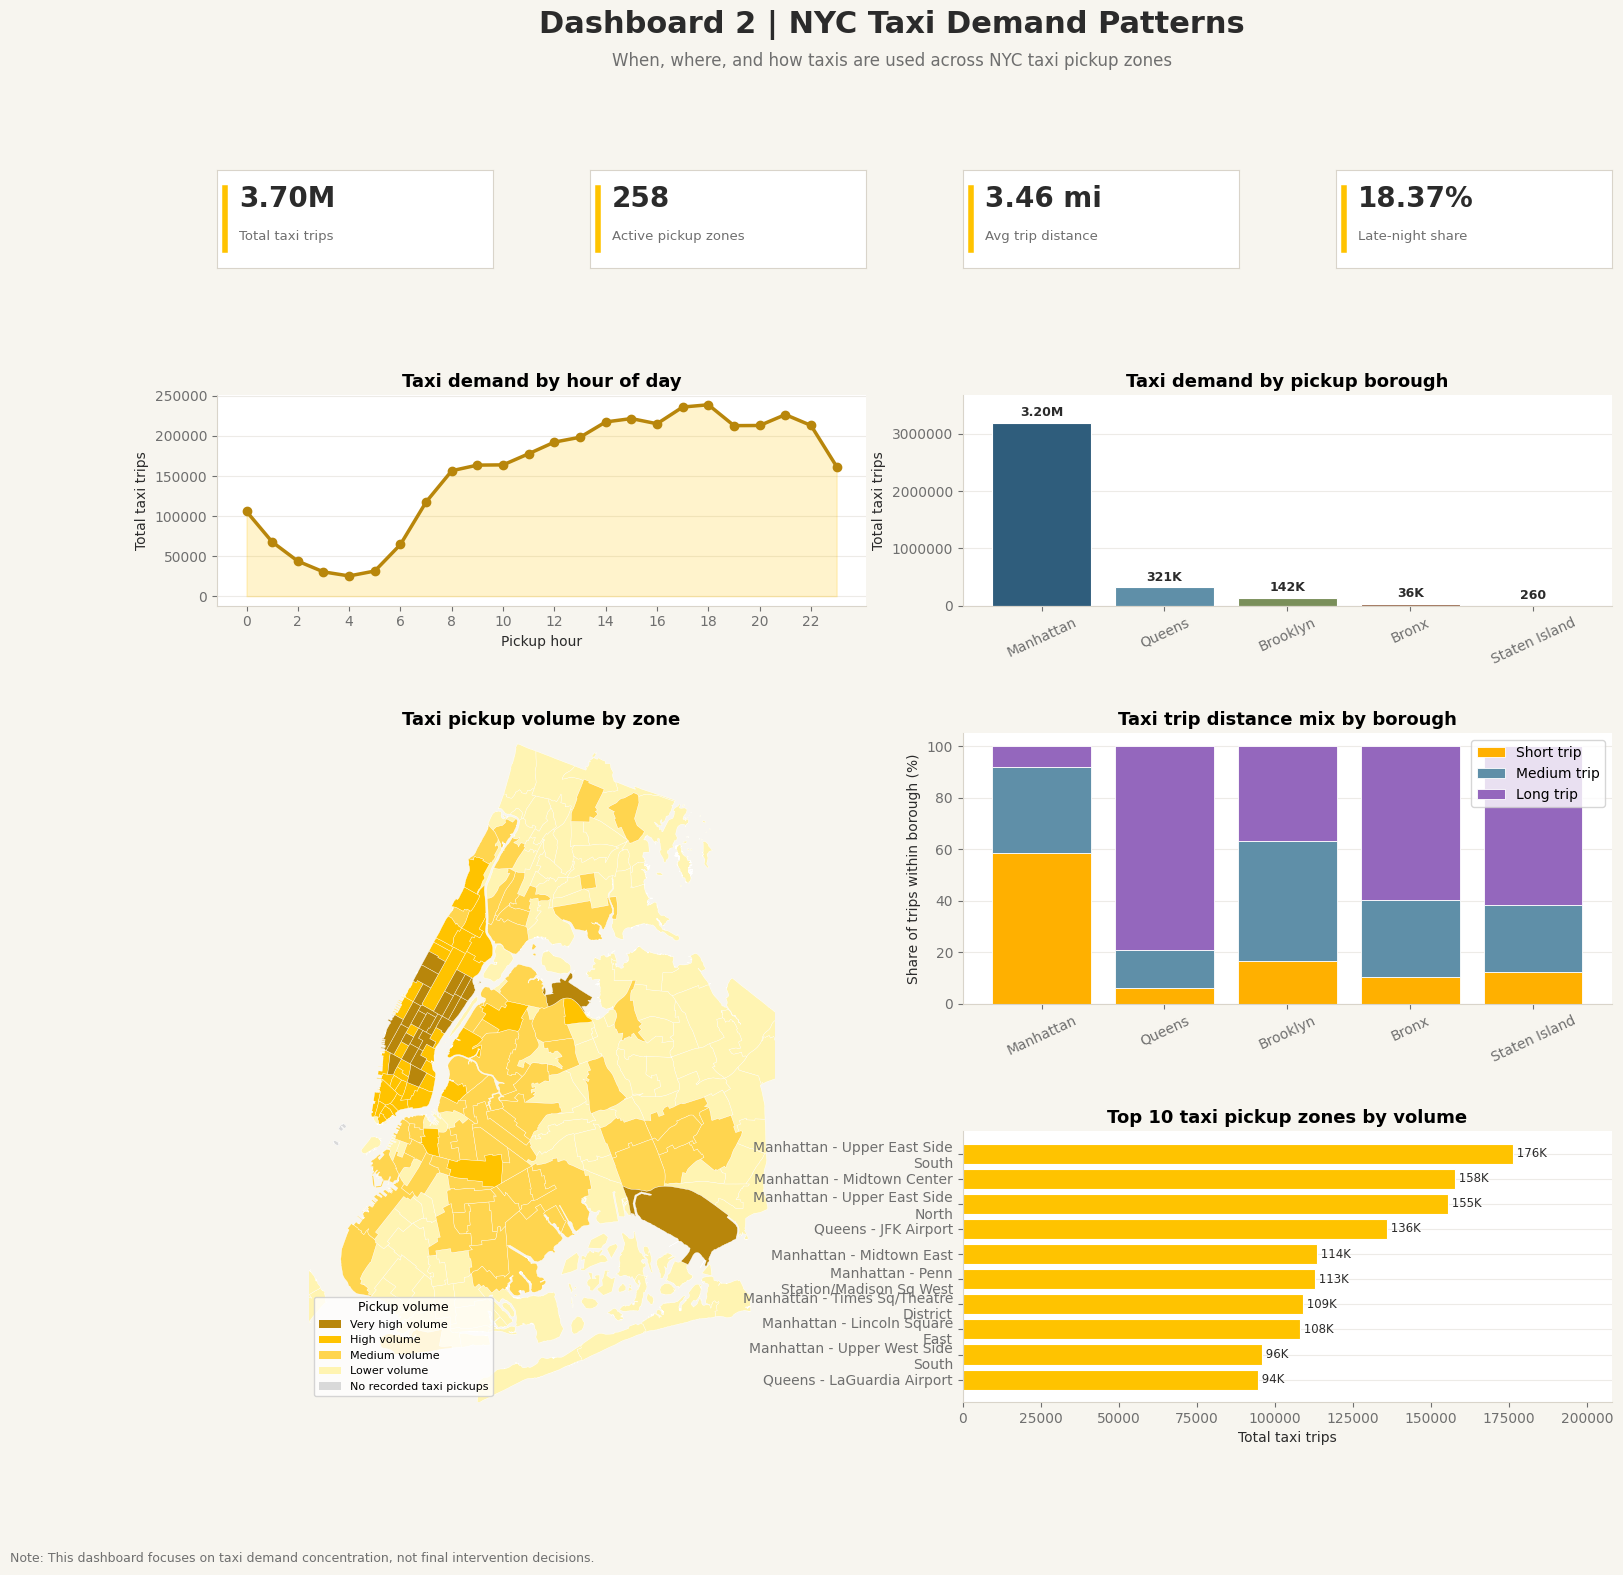

In [125]:
# ============================================================
# DASHBOARD 2: NYC TAXI DEMAND AND DEPENDENCE PATTERNS
# ============================================================

# ------------------------------------------------------------
# 1. Dashboard data
# ------------------------------------------------------------

taxi_kpis = run_sql("""
SELECT
    COUNT(*) AS total_taxi_trips,
    COUNT(DISTINCT pickup_location_id) AS active_pickup_zones,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance_miles,
    ROUND(AVG(total_amount), 2) AS avg_total_amount_usd,
    ROUND(100.0 * COUNT(*) FILTER (WHERE is_late_night = 1) / COUNT(*), 2) AS late_night_share_pct
FROM taxi_features
WHERE is_nyc_pickup_borough = 1
""")

taxi_hourly = run_sql("""
SELECT
    pickup_hour,
    total_taxi_trips
FROM taxi_hourly_summary
ORDER BY pickup_hour
""")

taxi_borough = run_sql("""
SELECT
    pickup_borough,
    total_taxi_trips
FROM taxi_borough_summary
ORDER BY total_taxi_trips DESC
""")

distance_mix = run_sql("""
SELECT
    pickup_borough,
    trip_distance_category,
    share_within_borough_pct
FROM taxi_borough_distance_summary
WHERE trip_distance_category IN ('Short trip', 'Medium trip', 'Long trip')
""")

distance_pivot = distance_mix.pivot(
    index="pickup_borough",
    columns="trip_distance_category",
    values="share_within_borough_pct"
).fillna(0)

distance_pivot = distance_pivot.reindex(
    taxi_borough["pickup_borough"]
).fillna(0)

distance_pivot = distance_pivot[["Short trip", "Medium trip", "Long trip"]]

top10_zones = run_sql("""
SELECT
    pickup_borough || ' - ' || pickup_zone AS zone_label,
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    avg_trip_distance_miles,
    avg_total_amount_usd
FROM taxi_zone_summary
ORDER BY total_taxi_trips DESC
LIMIT 10
""")

# ------------------------------------------------------------
# 2. Taxi pickup volume map data
# ------------------------------------------------------------

taxi_volume_for_map = run_sql("""
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    total_taxi_trips
FROM taxi_zone_summary
""")

taxi_volume_map_df = taxi_zones_gdf.merge(
    taxi_volume_for_map,
    left_on="LocationID",
    right_on="pickup_location_id",
    how="left"
)

taxi_volume_map_df["total_taxi_trips"] = taxi_volume_map_df["total_taxi_trips"].fillna(0)

active_zones = taxi_volume_map_df[taxi_volume_map_df["total_taxi_trips"] > 0].copy()

q50 = active_zones["total_taxi_trips"].quantile(0.50)
q75 = active_zones["total_taxi_trips"].quantile(0.75)
q90 = active_zones["total_taxi_trips"].quantile(0.90)

def classify_volume(trips):
    if trips == 0:
        return "No recorded taxi pickups"
    elif trips >= q90:
        return "Very high volume"
    elif trips >= q75:
        return "High volume"
    elif trips >= q50:
        return "Medium volume"
    else:
        return "Lower volume"

taxi_volume_map_df["pickup_volume_level"] = taxi_volume_map_df["total_taxi_trips"].apply(classify_volume)

volume_colour_map = {
    "Very high volume": "#B8860B",
    "High volume": "#FFC300",
    "Medium volume": "#FFD54F",
    "Lower volume": "#FFF4B2",
    "No recorded taxi pickups": "#D9D9D9"
}

volume_plot_order = [
    "No recorded taxi pickups",
    "Lower volume",
    "Medium volume",
    "High volume",
    "Very high volume"
]

# ------------------------------------------------------------
# 3. Create dashboard layout
# ------------------------------------------------------------

fig = plt.figure(figsize=(18, 16), facecolor=DASH_COLORS["background"])

gs = gridspec.GridSpec(
    4, 4,
    figure=fig,
    height_ratios=[0.65, 1.4, 1.8, 1.8],
    hspace=0.6,
    wspace=0.35
)

fig.suptitle(
    "Dashboard 2 | NYC Taxi Demand Patterns",
    fontsize=22,
    fontweight="bold",
    color=DASH_COLORS["text"],
    y=0.98
)

fig.text(
    0.5,
    0.945,
    "When, where, and how taxis are used across NYC taxi pickup zones",
    ha="center",
    fontsize=12,
    color=DASH_COLORS["muted_text"]
)

# ------------------------------------------------------------
# 4. KPI cards
# ------------------------------------------------------------

k = taxi_kpis.iloc[0]

kpi_cards = [
    ("Total taxi trips", format_number(k["total_taxi_trips"])),
    ("Active pickup zones", format_number(k["active_pickup_zones"])),
    ("Avg trip distance", f"{k['avg_trip_distance_miles']:.2f} mi"),
    ("Late-night share", f"{k['late_night_share_pct']:.2f}%")
]

for i, (label, value) in enumerate(kpi_cards):
    ax = fig.add_subplot(gs[0, i])
    draw_kpi_card(ax, value, label, DASH_COLORS["taxi_yellow"])

# ------------------------------------------------------------
# 5. Hourly taxi demand
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[1, 0:2])
style_axis(ax1)

ax1.plot(
    taxi_hourly["pickup_hour"],
    taxi_hourly["total_taxi_trips"],
    marker="o",
    linewidth=2.5,
    color=DASH_COLORS["taxi_dark_yellow"]
)

ax1.fill_between(
    taxi_hourly["pickup_hour"],
    taxi_hourly["total_taxi_trips"],
    color=DASH_COLORS["taxi_yellow"],
    alpha=0.2
)

ax1.set_title("Taxi demand by hour of day", fontsize=13, fontweight="bold")
ax1.set_xlabel("Pickup hour", color=DASH_COLORS["text"])
ax1.set_ylabel("Total taxi trips", color=DASH_COLORS["text"])
ax1.set_xticks(range(0, 24, 2))
ax1.ticklabel_format(style="plain", axis="y")

# ------------------------------------------------------------
# 6. Taxi demand by borough
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[1, 2:4])
style_axis(ax2)

borough_colors = [
    BOROUGH_COLORS.get(b, DASH_COLORS["grey"])
    for b in taxi_borough["pickup_borough"]
]

bars = ax2.bar(
    taxi_borough["pickup_borough"],
    taxi_borough["total_taxi_trips"],
    color=borough_colors,
    edgecolor="white",
    linewidth=0.8
)

ax2.set_title("Taxi demand by pickup borough", fontsize=13, fontweight="bold")
ax2.set_ylabel("Total taxi trips", color=DASH_COLORS["text"])
ax2.tick_params(axis="x", rotation=25)
ax2.ticklabel_format(style="plain", axis="y")

max_borough = taxi_borough["total_taxi_trips"].max()
ax2.set_ylim(0, max_borough * 1.15)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + max_borough * 0.02,
        format_number(height),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=DASH_COLORS["text"]
    )

# ------------------------------------------------------------
# 7. Taxi pickup volume map
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[2:4, 0:2])
ax3.set_facecolor(DASH_COLORS["card"])

taxi_zones_gdf.plot(
    ax=ax3,
    color="#F7F7F7",
    edgecolor="white",
    linewidth=0.25
)

for level in volume_plot_order:
    subset = taxi_volume_map_df[taxi_volume_map_df["pickup_volume_level"] == level]

    if not subset.empty:
        subset.plot(
            ax=ax3,
            color=volume_colour_map[level],
            edgecolor="white",
            linewidth=0.25
        )

zoom_df = taxi_volume_map_df[
    taxi_volume_map_df["pickup_volume_level"].isin(["Very high volume", "High volume", "Medium volume"])
].copy()

if not zoom_df.empty:
    xmin, ymin, xmax, ymax = zoom_df.total_bounds
    pad_x = (xmax - xmin) * 0.08
    pad_y = (ymax - ymin) * 0.08
    ax3.set_xlim(xmin - pad_x, xmax + pad_x)
    ax3.set_ylim(ymin - pad_y, ymax + pad_y)

ax3.set_title("Taxi pickup volume by zone", fontsize=13, fontweight="bold")
ax3.set_axis_off()

legend_items = [
    Patch(facecolor=volume_colour_map[level], edgecolor="none", label=level)
    for level in ["Very high volume", "High volume", "Medium volume", "Lower volume", "No recorded taxi pickups"]
]

ax3.legend(
    handles=legend_items,
    title="Pickup volume",
    loc="lower left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

# ------------------------------------------------------------
# 8. Trip distance mix by borough
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[2, 2:4])
style_axis(ax4)

distance_colors = {
    "Short trip": "#FFB000",
    "Medium trip": "#5F8FA8",
    "Long trip": "#9467BD"
}

bottom = np.zeros(len(distance_pivot))

for category in ["Short trip", "Medium trip", "Long trip"]:
    ax4.bar(
        distance_pivot.index,
        distance_pivot[category],
        bottom=bottom,
        label=category,
        color=distance_colors[category],
        edgecolor="white",
        linewidth=0.6
    )
    bottom += distance_pivot[category].values

ax4.set_title("Taxi trip distance mix by borough", fontsize=13, fontweight="bold")
ax4.set_ylabel("Share of trips within borough (%)", color=DASH_COLORS["text"])
ax4.tick_params(axis="x", rotation=25)
ax4.legend(frameon=True)

# ------------------------------------------------------------
# 9. Top 10 taxi pickup zones
# ------------------------------------------------------------

ax5 = fig.add_subplot(gs[3, 2:4])
style_axis(ax5)

top_labels = wrap_labels(top10_zones["zone_label"], width=30)

bars = ax5.barh(
    top_labels,
    top10_zones["total_taxi_trips"],
    color=DASH_COLORS["taxi_yellow"],
    edgecolor="white",
    linewidth=0.8
)

ax5.set_title("Top 10 taxi pickup zones by volume", fontsize=13, fontweight="bold")
ax5.set_xlabel("Total taxi trips", color=DASH_COLORS["text"])
ax5.invert_yaxis()
ax5.ticklabel_format(style="plain", axis="x")

max_zone = top10_zones["total_taxi_trips"].max()
ax5.set_xlim(0, max_zone * 1.18)

for bar, trips in zip(bars, top10_zones["total_taxi_trips"]):
    ax5.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {format_number(trips)}",
        va="center",
        fontsize=8.5,
        color=DASH_COLORS["text"]
    )

fig.text(
    0.01,
    0.01,
    "Note: This dashboard focuses on taxi demand concentration, not final intervention decisions.",
    fontsize=9,
    color=DASH_COLORS["muted_text"]
)

plt.show()

## Dashboard 3 — Priority groups and recommendations

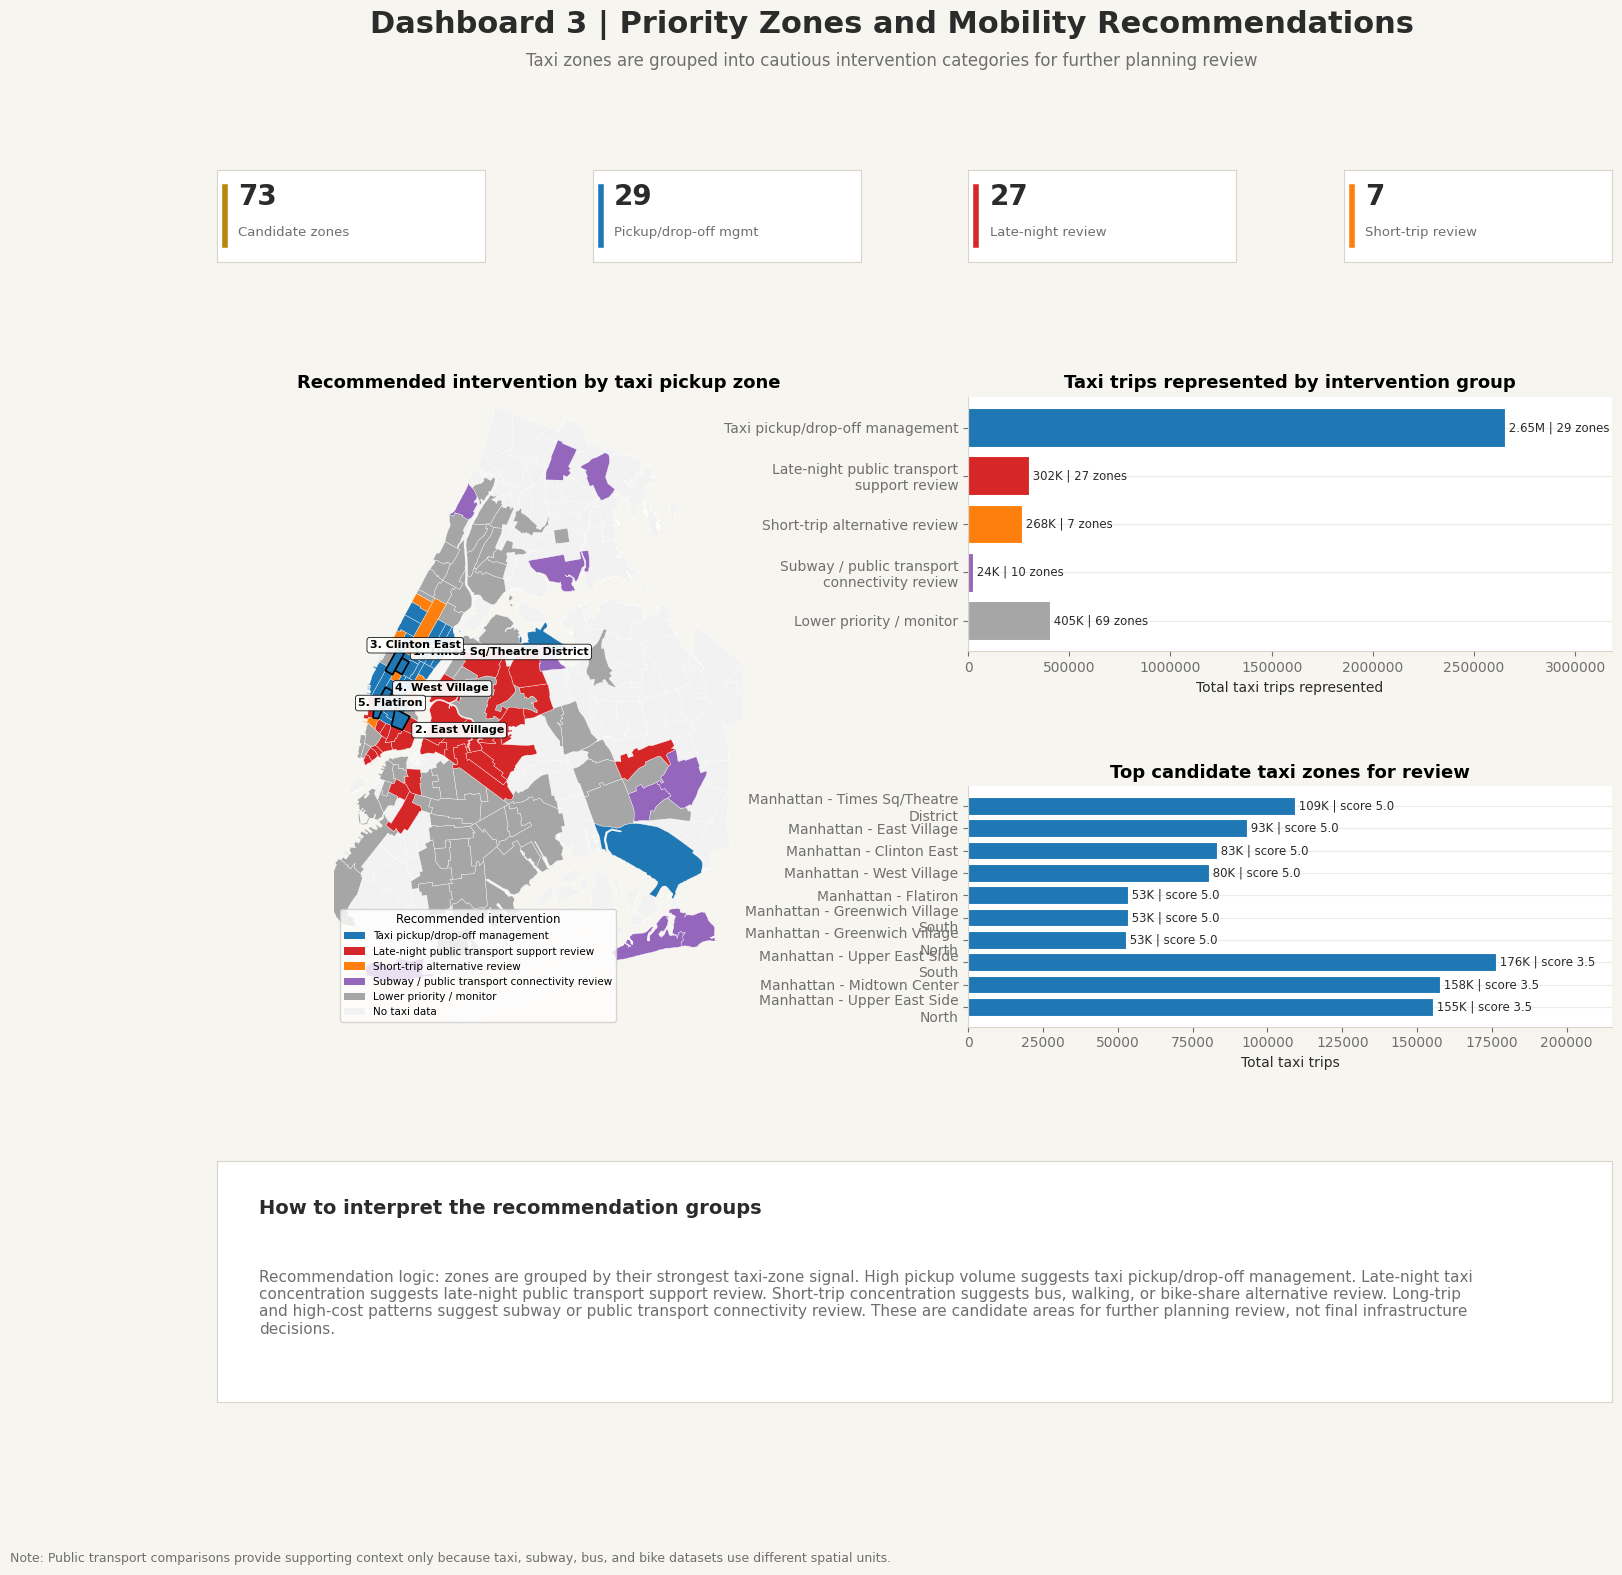

,zone_label,pickup_borough,pickup_zone,total_taxi_trips,recommended_intervention,priority_score,signal_count,signal_summary
0,Manhattan - Times Sq/Theatre District,Manhattan,Times Sq/Theatre District,109175,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...
1,Manhattan - East Village,Manhattan,East Village,93298,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...
2,Manhattan - Clinton East,Manhattan,Clinton East,83191,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...
3,Manhattan - West Village,Manhattan,West Village,80404,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...
4,Manhattan - Flatiron,Manhattan,Flatiron,53384,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...
5,Manhattan - Greenwich Village South,Manhattan,Greenwich Village South,53280,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...
6,Manhattan - Greenwich Village North,Manhattan,Greenwich Village North,52590,Taxi pickup/drop-off management,5.0,3,High taxi pickup volume; High late-night taxi ...
7,Manhattan - Upper East Side South,Manhattan,Upper East Side South,176330,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...
8,Manhattan - Midtown Center,Manhattan,Midtown Center,157679,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...
9,Manhattan - Upper East Side North,Manhattan,Upper East Side North,155473,Taxi pickup/drop-off management,3.5,2,High taxi pickup volume; High short-trip conce...


In [126]:
# ============================================================
# DASHBOARD 3: PRIORITY GROUPS AND RECOMMENDATIONS
# ============================================================

# ------------------------------------------------------------
# 1. Dashboard data
# ------------------------------------------------------------

recommendation_kpis = run_sql("""
SELECT
    COUNT(*) FILTER (WHERE recommended_intervention <> 'Lower priority / monitor') AS candidate_zones,
    COUNT(*) FILTER (WHERE recommended_intervention = 'Taxi pickup/drop-off management') AS pickup_management_zones,
    COUNT(*) FILTER (WHERE recommended_intervention = 'Late-night public transport support review') AS late_night_zones,
    COUNT(*) FILTER (WHERE recommended_intervention = 'Short-trip alternative review') AS short_trip_zones,
    COUNT(*) FILTER (WHERE recommended_intervention = 'Subway / public transport connectivity review') AS connectivity_zones
FROM taxi_zone_intervention_priority
""")

intervention_summary = run_sql("""
SELECT
    recommended_intervention,
    zone_count,
    total_taxi_trips,
    avg_priority_score,
    avg_signal_count
FROM intervention_group_summary
ORDER BY
    CASE
        WHEN recommended_intervention = 'Taxi pickup/drop-off management' THEN 1
        WHEN recommended_intervention = 'Late-night public transport support review' THEN 2
        WHEN recommended_intervention = 'Short-trip alternative review' THEN 3
        WHEN recommended_intervention = 'Subway / public transport connectivity review' THEN 4
        WHEN recommended_intervention = 'Lower priority / monitor' THEN 5
        ELSE 6
    END,
    total_taxi_trips DESC
""")

top_priority_zones = run_sql("""
SELECT
    pickup_borough || ' - ' || pickup_zone AS zone_label,
    pickup_borough,
    pickup_zone,
    total_taxi_trips,
    recommended_intervention,
    priority_score,
    signal_count,
    signal_summary
FROM taxi_zone_intervention_priority
WHERE recommended_intervention <> 'Lower priority / monitor'
ORDER BY
    priority_score DESC,
    total_taxi_trips DESC
LIMIT 10
""")

priority_for_map = run_sql("""
SELECT
    pickup_location_id,
    pickup_borough,
    pickup_zone,
    recommended_intervention,
    priority_level,
    priority_score,
    signal_count,
    signal_summary,
    total_taxi_trips
FROM taxi_zone_intervention_priority
""")

recommendation_map_df = taxi_zones_gdf.merge(
    priority_for_map,
    left_on="LocationID",
    right_on="pickup_location_id",
    how="left"
)

recommendation_map_df["intervention_display"] = recommendation_map_df["recommended_intervention"].fillna("No taxi data")

plot_order = [
    "No taxi data",
    "Lower priority / monitor",
    "Subway / public transport connectivity review",
    "Short-trip alternative review",
    "Late-night public transport support review",
    "Taxi pickup/drop-off management"
]

actionable_groups = [
    "Taxi pickup/drop-off management",
    "Late-night public transport support review",
    "Short-trip alternative review",
    "Subway / public transport connectivity review"
]

actionable_df = recommendation_map_df[
    recommendation_map_df["intervention_display"].isin(actionable_groups)
].copy()

top5_zones = (
    actionable_df
    .sort_values(by=["priority_score", "total_taxi_trips"], ascending=[False, False])
    .head(5)
    .copy()
)

top5_zones["map_label"] = [
    f"{i+1}. {zone}"
    for i, zone in enumerate(top5_zones["pickup_zone"])
]

top5_zones["label_point"] = top5_zones.representative_point()

# ------------------------------------------------------------
# 2. Create dashboard layout
# ------------------------------------------------------------

fig = plt.figure(figsize=(18, 16), facecolor=DASH_COLORS["background"])

gs = gridspec.GridSpec(
    4, 4,
    figure=fig,
    height_ratios=[0.65, 1.8, 1.7, 1.7],
    hspace=0.65,
    wspace=0.4
)

fig.suptitle(
    "Dashboard 3 | Priority Zones and Mobility Recommendations",
    fontsize=22,
    fontweight="bold",
    color=DASH_COLORS["text"],
    y=0.98
)

fig.text(
    0.5,
    0.945,
    "Taxi zones are grouped into cautious intervention categories for further planning review",
    ha="center",
    fontsize=12,
    color=DASH_COLORS["muted_text"]
)

# ------------------------------------------------------------
# 3. KPI cards
# ------------------------------------------------------------

k = recommendation_kpis.iloc[0]

kpi_cards = [
    ("Candidate zones", format_number(k["candidate_zones"]), DASH_COLORS["taxi_dark_yellow"]),
    ("Pickup/drop-off mgmt", format_number(k["pickup_management_zones"]), INTERVENTION_COLORS["Taxi pickup/drop-off management"]),
    ("Late-night review", format_number(k["late_night_zones"]), INTERVENTION_COLORS["Late-night public transport support review"]),
    ("Short-trip review", format_number(k["short_trip_zones"]), INTERVENTION_COLORS["Short-trip alternative review"])
]

for i, (label, value, color) in enumerate(kpi_cards):
    ax = fig.add_subplot(gs[0, i])
    draw_kpi_card(ax, value, label, color)

# ------------------------------------------------------------
# 4. Recommended intervention map
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[1:3, 0:2])
ax1.set_facecolor(DASH_COLORS["card"])

taxi_zones_gdf.plot(
    ax=ax1,
    color="#F7F7F7",
    edgecolor="white",
    linewidth=0.25
)

for group in plot_order:
    subset = recommendation_map_df[recommendation_map_df["intervention_display"] == group]

    if not subset.empty:
        subset.plot(
            ax=ax1,
            color=INTERVENTION_COLORS.get(group, DASH_COLORS["light_grey"]),
            edgecolor="white",
            linewidth=0.25
        )

if not top5_zones.empty:
    top5_zones.boundary.plot(
        ax=ax1,
        color="black",
        linewidth=1.2
    )

if not actionable_df.empty:
    xmin, ymin, xmax, ymax = actionable_df.total_bounds
    pad_x = (xmax - xmin) * 0.08
    pad_y = (ymax - ymin) * 0.08
    ax1.set_xlim(xmin - pad_x, xmax + pad_x)
    ax1.set_ylim(ymin - pad_y, ymax + pad_y)

offsets = [(8, 8), (10, -10), (-18, 10), (12, 12), (-20, -8)]

for (_, row), (dx, dy) in zip(top5_zones.iterrows(), offsets):
    x = row["label_point"].x
    y = row["label_point"].y

    ax1.annotate(
        row["map_label"],
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            alpha=0.92
        )
    )

ax1.set_title("Recommended intervention by taxi pickup zone", fontsize=13, fontweight="bold")
ax1.set_axis_off()

legend_order = [
    "Taxi pickup/drop-off management",
    "Late-night public transport support review",
    "Short-trip alternative review",
    "Subway / public transport connectivity review",
    "Lower priority / monitor",
    "No taxi data"
]

legend_items = [
    Patch(
        facecolor=INTERVENTION_COLORS[group],
        edgecolor="none",
        label=group
    )
    for group in legend_order
]

ax1.legend(
    handles=legend_items,
    title="Recommended intervention",
    loc="lower left",
    fontsize=7.5,
    title_fontsize=8.5,
    frameon=True
)

# ------------------------------------------------------------
# 5. Intervention group summary
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[1, 2:4])
style_axis(ax2)

intervention_labels = wrap_labels(intervention_summary["recommended_intervention"], width=34)

bar_colours = [
    INTERVENTION_COLORS.get(group, DASH_COLORS["grey"])
    for group in intervention_summary["recommended_intervention"]
]

bars = ax2.barh(
    intervention_labels,
    intervention_summary["total_taxi_trips"],
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8
)

ax2.set_title("Taxi trips represented by intervention group", fontsize=13, fontweight="bold")
ax2.set_xlabel("Total taxi trips represented", color=DASH_COLORS["text"])
ax2.invert_yaxis()
ax2.ticklabel_format(style="plain", axis="x")

max_intervention = intervention_summary["total_taxi_trips"].max()
ax2.set_xlim(0, max_intervention * 1.2)

for bar, trips, zones in zip(
    bars,
    intervention_summary["total_taxi_trips"],
    intervention_summary["zone_count"]
):
    ax2.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {format_number(trips)} | {zones} zones",
        va="center",
        fontsize=8.5,
        color=DASH_COLORS["text"]
    )

# ------------------------------------------------------------
# 6. Top priority zones chart
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[2, 2:4])
style_axis(ax3)

top_labels = wrap_labels(top_priority_zones["zone_label"], width=32)

bar_colours = [
    INTERVENTION_COLORS.get(group, DASH_COLORS["grey"])
    for group in top_priority_zones["recommended_intervention"]
]

bars = ax3.barh(
    top_labels,
    top_priority_zones["total_taxi_trips"],
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8
)

ax3.set_title("Top candidate taxi zones for review", fontsize=13, fontweight="bold")
ax3.set_xlabel("Total taxi trips", color=DASH_COLORS["text"])
ax3.invert_yaxis()
ax3.ticklabel_format(style="plain", axis="x")

max_zone = top_priority_zones["total_taxi_trips"].max()
ax3.set_xlim(0, max_zone * 1.22)

for bar, trips, score in zip(
    bars,
    top_priority_zones["total_taxi_trips"],
    top_priority_zones["priority_score"]
):
    ax3.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {format_number(trips)} | score {score:.1f}",
        va="center",
        fontsize=8.5,
        color=DASH_COLORS["text"]
    )

# ------------------------------------------------------------
# 7. Recommendation interpretation panel
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[3, :])
ax4.set_facecolor(DASH_COLORS["card"])
ax4.set_xticks([])
ax4.set_yticks([])

for spine in ax4.spines.values():
    spine.set_color(DASH_COLORS["grid"])

recommendation_text = (
    "Recommendation logic: zones are grouped by their strongest taxi-zone signal. "
    "High pickup volume suggests taxi pickup/drop-off management. "
    "Late-night taxi concentration suggests late-night public transport support review. "
    "Short-trip concentration suggests bus, walking, or bike-share alternative review. "
    "Long-trip and high-cost patterns suggest subway or public transport connectivity review. "
    "These are candidate areas for further planning review, not final infrastructure decisions."
)

ax4.text(
    0.03,
    0.78,
    "How to interpret the recommendation groups",
    fontsize=14,
    fontweight="bold",
    color=DASH_COLORS["text"],
    transform=ax4.transAxes
)

ax4.text(
    0.03,
    0.55,
    "\n".join(textwrap.wrap(recommendation_text, width=160)),
    fontsize=11,
    color=DASH_COLORS["muted_text"],
    va="top",
    transform=ax4.transAxes
)

fig.text(
    0.01,
    0.01,
    "Note: Public transport comparisons provide supporting context only because taxi, subway, bus, and bike datasets use different spatial units.",
    fontsize=9,
    color=DASH_COLORS["muted_text"]
)

plt.show()

# Optional: display the top zones table below the dashboard
top_priority_zones